<a href="https://colab.research.google.com/github/Quarieda/pytorch-deep-learning/blob/main/Zero_to_Hero_in_PyTorch_CLEAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Zero to Hero in PyTorch — Cleaned & Debugged Edition

This is a debugged version of the original notebook. The cell directly
below installs the dependencies needed by every section (gym is needed
for the DQN section; pip-installs are no-ops if already present).


In [1]:
# --- environment setup (safe to re-run) ---
import sys, subprocess
def _pip(args):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *args])
try:
    import gym  # noqa: F401
except ImportError:
    _pip(['gym==0.26.2'])
try:
    import seaborn  # noqa: F401
except ImportError:
    _pip(['seaborn'])
import torch, torchvision
print('torch:', torch.__version__, '| torchvision:', torchvision.__version__,
      '| cuda:', torch.cuda.is_available())


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=

torch: 2.11.0+cpu | torchvision: 0.26.0+cpu | cuda: False


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


![Next Generation Weapon](https://s3-ap-south-1.amazonaws.com/av-blog-media/wp-content/uploads/2018/02/pytorch-logo-flat-300x210.png)


---
10 Minute of Pytorch
---
---
* [Pytorch Introduction](#Pytorch-Introduction)
    * [PyTorch provides two high-level features](#PyTorch-provides-two-high-level-features)
* [Environment Configuration](#Environment-Configuration)
    * [Install pytorch on Windows Snapshop Tutorial](https://www.superdatascience.com/pytorch/)
* [**Section : 1. Pytorch Basic Foundation**](#Section-1-:-Pytorch-Basic-Foundation)
    * [Tensor](#Tensor)
        * [Construct a 5x3 matrix uninitialized](#Construct-a-5x3-matrix-uninitialized)
        * [Convert to numpy](#Convert-to-numpy)
        * [Size of tensor](#Size-of-tensor)
        * [From Numpy to tensor](#From-Numpy-to-tensor)
    * [Tensor Operation](#Tensor-Operation)
        * [Random similar to numpy](#Random-similar-to-numpy)
        * [Construct a matrix filled zeros and of dtype long](#Construct-a-matrix-filled-zeros-and-of-dtype-long)
        * [Construct a tensor directly from data](#Construct-a-tensor-directly-from-data)
        * [Create tensor based on existing tensor](#Create-tensor-based-on-existing-tensor)
        * [Basic Tensor Operation](#Basic-Tensor-Operation)
    * [Variable](#Variable)
    * [Activation Function](#Activation-Function)
        * [Generate Fake Data](#Generate-Fake-Data)
        * [Popular Activation Function](#Popular-Activation-Function)
        * [Activation Function plot from data](#Activation-Function-plot-from-data)
        
* [**Section : 2. Neural Network**](#Section-:-2.-Neural-Network)
     * [Linear Regression](#Linear-Regression)
     * [Relationship Fitting Regression Model](#Relationship-Fitting-Regression-Model)
     * [Distinguish type classification](#Distinguish-type-classification)
     * [Easy way to Buid Neural Network](#Easy-way-to-Buid-Neural-Network)
     * [Save and Reload Model](#Save-and-Reload-Model)
     * [Train on Batch](#Train-on-batch)
     * [Optimizers](#Optimizers)

* [**Section : 3. Advance Neural Network**](#Section-:-3.-Advance-Neural-Network)
    * [CNN](#CNN)
    * [RNN-Classification](#RNN-Classification)
    * [RNN-Regression](#RNN-Regression)
    * [AutoEncoder](#AutoEncoder)
    * [DQN Reinforcement Learning](#DQN-Reinforcement-Learning)
    * [A3C Reinforcement Learning](https://medium.com/emergent-future/simple-reinforcement-learning-with-tensorflow-part-8-asynchronous-actor-critic-agents-a3c-c88f72a5e9f2) [(Code)](https://github.com/nailo2c/a3c/blob/master/tutorial.ipynb)
    * [Generative Adversarial Network](#Generative-Adversarial-Network)
    * [Conditional GAN](#Conditional-GAN)
    
    
    


---
Pytorch Introduction
---
---
PyTorch is an open source machine learning library for Python, based on [Torch](https://en.wikipedia.org/wiki/Torch_(machine_learning),used for applications such as natural language processing.It is primarily developed by Facebook's artificial-intelligence research group, and Uber's "Pyro" software for probabilistic programming is built on it.

#### PyTorch provides two high-level features:

1. *Tensor computation (like NumPy) with strong GPU acceleration*
1. *Deep Neural Networks built on a tape-based autodiff system*

---
Environment Configuration
---
---
![](https://s3-ap-south-1.amazonaws.com/av-blog-media/wp-content/uploads/2018/02/3-768x368.png)

* [Install pytorch on Windows Snapshop Tutorial](https://www.superdatascience.com/pytorch/)


In [2]:
# Core scientific stack
import numpy as np
import pandas as pd
import torch
import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use("fivethirtyeight")
%matplotlib inline

import os
import warnings
warnings.filterwarnings("ignore")
print("torch:", torch.__version__, "| cuda:", torch.cuda.is_available())

torch: 2.11.0+cpu | cuda: False


Section-1 : Pytorch Basic Foundation
---

### Tensor
---
* Tensors are matrix-like data structures which are essential components in deep learning libraries and efficient computation. **Graphical Processing Units (GPUs)** are especially effective at calculating operations between **tensors**, and this has spurred the surge in deep learning capability in recent times. In PyTorch, tensors can be declared simply in a number of ways:
![](https://cdn-images-1.medium.com/max/2000/1*_D5ZvufDS38WkhK9rK32hQ.jpeg)

#### **Construct a 5x3 matrix uninitialized**

In [3]:
x = torch.empty(5, 3)
print(x)

tensor([[-5.4861e+34,  4.3314e-41,  1.9135e-05],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00]])


#### **Convert to numpy**

In [4]:
x.numpy()

array([[-5.4860828e+34,  4.3314136e-41,  1.9135361e-05],
       [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
       [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
       [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
       [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00]], dtype=float32)

#### **Size of tensor**

In [5]:
x.size()

torch.Size([5, 3])

#### **From Numpy to tensor**

In [6]:
a = np.array([[3,4],[4,3]])
b = torch.from_numpy(a)
print(b)

tensor([[3, 4],
        [4, 3]])


#### Tensor Operations

#### **Random similar to numpy**

In [7]:
x = torch.rand(5, 3)
print(x)

tensor([[1.4383e-04, 7.5398e-01, 6.2434e-02],
        [8.1511e-01, 8.5413e-01, 7.7579e-02],
        [1.7090e-01, 5.3958e-01, 8.6620e-01],
        [6.2147e-01, 7.5443e-01, 2.9668e-03],
        [8.2148e-01, 1.9669e-01, 4.3801e-01]])


#### **Construct a matrix filled zeros and of dtype long**

In [8]:
x = torch.zeros(5, 3, dtype=torch.long)
print(x)

tensor([[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]])


In [9]:
x = torch.ones(3, 3, dtype=torch.long)
print(x)

tensor([[1, 1, 1],
        [1, 1, 1],
        [1, 1, 1]])


#### **Construct a tensor directly from data**

In [10]:
x = torch.tensor([2.5, 7])
print(x)

tensor([2.5000, 7.0000])


#### **Create tensor based on existing tensor** - This method has reuse property of input Tensor

In [11]:
x = x.new_ones(5, 3, dtype=torch.double)      # new_* methods take in sizes
print(x)
print(x.size())

tensor([[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]], dtype=torch.float64)
torch.Size([5, 3])


In [12]:
x = torch.randn_like(x, dtype=torch.float)    # override dtype!
print(x)
print(x.size())

tensor([[ 0.1550,  0.2684,  1.1397],
        [-0.2330,  0.6970,  0.1972],
        [-0.1224, -0.5939, -0.3719],
        [-0.4490,  1.1355, -0.5004],
        [-1.1373,  0.3523, -0.2387]])
torch.Size([5, 3])


#### Basic Tensor Operation
---
![](https://devblogs.nvidia.com/wp-content/uploads/2018/05/tesnor_core_diagram.png)

* **Addition(`torch.add()`)**
* **Substraction(`torch.sub()`)**
* **Division(`torch.div()`)**
* ** Multiplication( `torch.mul()`)**

In [13]:
x = torch.rand(5, 3)
y = torch.rand(5, 3)
print(x + y) # This is old method
print(torch.add(x, y)) # pytorch method

tensor([[0.2508, 0.8716, 0.6750],
        [0.8950, 0.4427, 1.1211],
        [1.1928, 1.5021, 0.6662],
        [0.8319, 0.7021, 1.1426],
        [1.2507, 0.2038, 1.0522]])
tensor([[0.2508, 0.8716, 0.6750],
        [0.8950, 0.4427, 1.1211],
        [1.1928, 1.5021, 0.6662],
        [0.8319, 0.7021, 1.1426],
        [1.2507, 0.2038, 1.0522]])


In [14]:
x = torch.rand(5, 3)
y = torch.rand(5, 3)
print(x - y) # This is old method
print(torch.sub(x, y)) # pytorch method

tensor([[ 0.5498,  0.0914,  0.3103],
        [-0.4408,  0.1082,  0.1412],
        [ 0.3416,  0.1694, -0.1252],
        [-0.1951,  0.1840,  0.2358],
        [ 0.3963, -0.9565, -0.2852]])
tensor([[ 0.5498,  0.0914,  0.3103],
        [-0.4408,  0.1082,  0.1412],
        [ 0.3416,  0.1694, -0.1252],
        [-0.1951,  0.1840,  0.2358],
        [ 0.3963, -0.9565, -0.2852]])


In [15]:
x = torch.rand(5, 3)
y = torch.rand(5, 3)
print(x / y) # This is old method
print(torch.div(x, y)) # pytorch method

tensor([[ 0.9653,  2.4837,  0.0553],
        [ 0.3314,  0.8636,  1.6331],
        [ 1.0225,  1.2873,  1.6873],
        [ 6.6897,  2.4521,  0.6127],
        [11.5100,  4.3975,  2.3766]])
tensor([[ 0.9653,  2.4837,  0.0553],
        [ 0.3314,  0.8636,  1.6331],
        [ 1.0225,  1.2873,  1.6873],
        [ 6.6897,  2.4521,  0.6127],
        [11.5100,  4.3975,  2.3766]])


In [16]:
x = torch.rand(5, 3)
y = torch.rand(5, 3)
print(x * y) # This is old method
print(torch.mul(x, y)) # pytorch method

tensor([[4.5160e-03, 9.5465e-02, 6.9934e-01],
        [1.9874e-01, 6.3329e-02, 1.6854e-01],
        [2.9216e-01, 5.0342e-01, 5.4274e-02],
        [5.4271e-01, 3.0919e-01, 3.6304e-02],
        [1.1229e-01, 6.5321e-04, 2.4230e-01]])
tensor([[4.5160e-03, 9.5465e-02, 6.9934e-01],
        [1.9874e-01, 6.3329e-02, 1.6854e-01],
        [2.9216e-01, 5.0342e-01, 5.4274e-02],
        [5.4271e-01, 3.0919e-01, 3.6304e-02],
        [1.1229e-01, 6.5321e-04, 2.4230e-01]])


* **Add x to y**

In [17]:
# adds x to y
y.add_(x)
print(y)

tensor([[0.1445, 0.7211, 1.6798],
        [0.9461, 0.5561, 0.8215],
        [1.0972, 1.4202, 0.6225],
        [1.4759, 1.2835, 0.4092],
        [0.7178, 0.0518, 0.9847]])


* **Standard Numpy like Indexing**

In [18]:
print(x[:, 1])

tensor([0.5464, 0.3963, 0.6814, 0.9621, 0.0218])


* **Resizing**

In [19]:
x = torch.randn(4, 4)
y = x.view(16)
z = x.view(-1, 8)  # the size -1 is inferred from other dimensions
print(x.size(), y.size(), z.size())

torch.Size([4, 4]) torch.Size([16]) torch.Size([2, 8])


---
* **Note** : Any operation that mutates a tensor in-place is post-fixed with an _. For example:_ `x.copy_(y), x.t_()`, will change `x`.  
for more about tensor go on this link : https://pytorch.org/docs/stable/tensors.html
---

### Variable
* The difference between pytorch and numpy is that it provides automatic derivation, which can automatically give you the gradient of the parameters you want. This operation is provided by another basic element, Variable.
![](https://raw.githubusercontent.com/pytorch/pytorch/master/docs/source/_static/img/dynamic_graph.gif)
* A Variable wraps a Tensor. It supports nearly all the API’s defined by a Tensor. Variable also provides a backward method to perform backpropagation. For example, to backpropagate a loss function to train model parameter x, we use a variable loss to store the value computed by a loss function. Then, we call loss.backward which computes the gradients ∂loss∂x for all trainable parameters. PyTorch will store the gradient results back in the corresponding variable x.
* Variable in torch is to build a computational graph, but this graph is dynamic compared with a static graph in Tensorflow or Theano.So torch does not have placeholder, torch can just pass variable to the computational graph.

In [20]:
import torch
from torch.autograd import Variable

* Build a **tensor**
* Build a **variable, usually for compute gradients**

In [21]:
tensor = torch.FloatTensor([[1,2],[3,4]])
variable = Variable(tensor, requires_grad=True)
print(tensor)       # [torch.FloatTensor of size 2x2]
print(variable)     # [torch.FloatTensor of size 2x2]

tensor([[1., 2.],
        [3., 4.]])
tensor([[1., 2.],
        [3., 4.]], requires_grad=True)


* Till now the **tensor and variable** seem the same.However, the **variable is a part of the graph**, it's a part of the **auto-gradient.**

In [22]:
t_out = torch.mean(tensor*tensor)       # x^2
v_out = torch.mean(variable*variable)   # x^2
print(t_out)
print(v_out)    # 7.5

tensor(7.5000)
tensor(7.5000, grad_fn=<MeanBackward0>)


*  Backpropagation from v_out
*  `v_out  =  1 / 4  *  sum(variable * variable)`
* the gradients w.r.t the variable, `d(v_out)/d(variable) = 1/4*2*variable = variable/2`

In [23]:
v_out.backward()
print(variable.grad)

tensor([[0.5000, 1.0000],
        [1.5000, 2.0000]])


*  This is data in **variable format**

In [24]:
print(variable)

tensor([[1., 2.],
        [3., 4.]], requires_grad=True)


* This is data in **tensor format**

In [25]:
print(variable.data)    #

tensor([[1., 2.],
        [3., 4.]])


* This is in **numpy format**

In [26]:
print(variable.data.numpy())    # numpy format

[[1. 2.]
 [3. 4.]]


### Activation Function
---
* Activation functions is used for a Artificial Neural Network to learn and make sense of something really complicated and Non-linear complex functional mappings between the **inputs and response variable.** They introduce non-linear properties to our Network.
* Their main purpose is to convert a ***input signal of a node in a A-NN to an output signal.** That **output signal** now is used as a **input in the next layer** in the stack.
![](https://cdn-images-1.medium.com/max/1200/1*ZafDv3VUm60Eh10OeJu1vw.png)

In [27]:
import torch
import torch.nn.functional as F
from torch.autograd import Variable
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings(action='ignore')

#### Generate Fake Data

In [28]:
x = torch.linspace(-5, 5, 200)  # x data (tensor), shape=(200, 1)
x = Variable(x)
x_np = x.data.numpy()   # numpy array for plotting

#### Popular Activation Function

In [29]:
y_relu = torch.relu(x).data.numpy()
y_sigmoid = torch.sigmoid(x).data.numpy()
y_tanh = torch.tanh(x).data.numpy()
y_softplus = F.softplus(x).data.numpy()

# y_softmax = F.softmax(x, dim=0)
# softmax is a special kind of activation function, it is about probability
# and will make the sum as 1.

You can see that all activation function we have applied here.softmax is special kind of activation function which is used for **multiclass classification problem.**

#### Activation Function plot from data

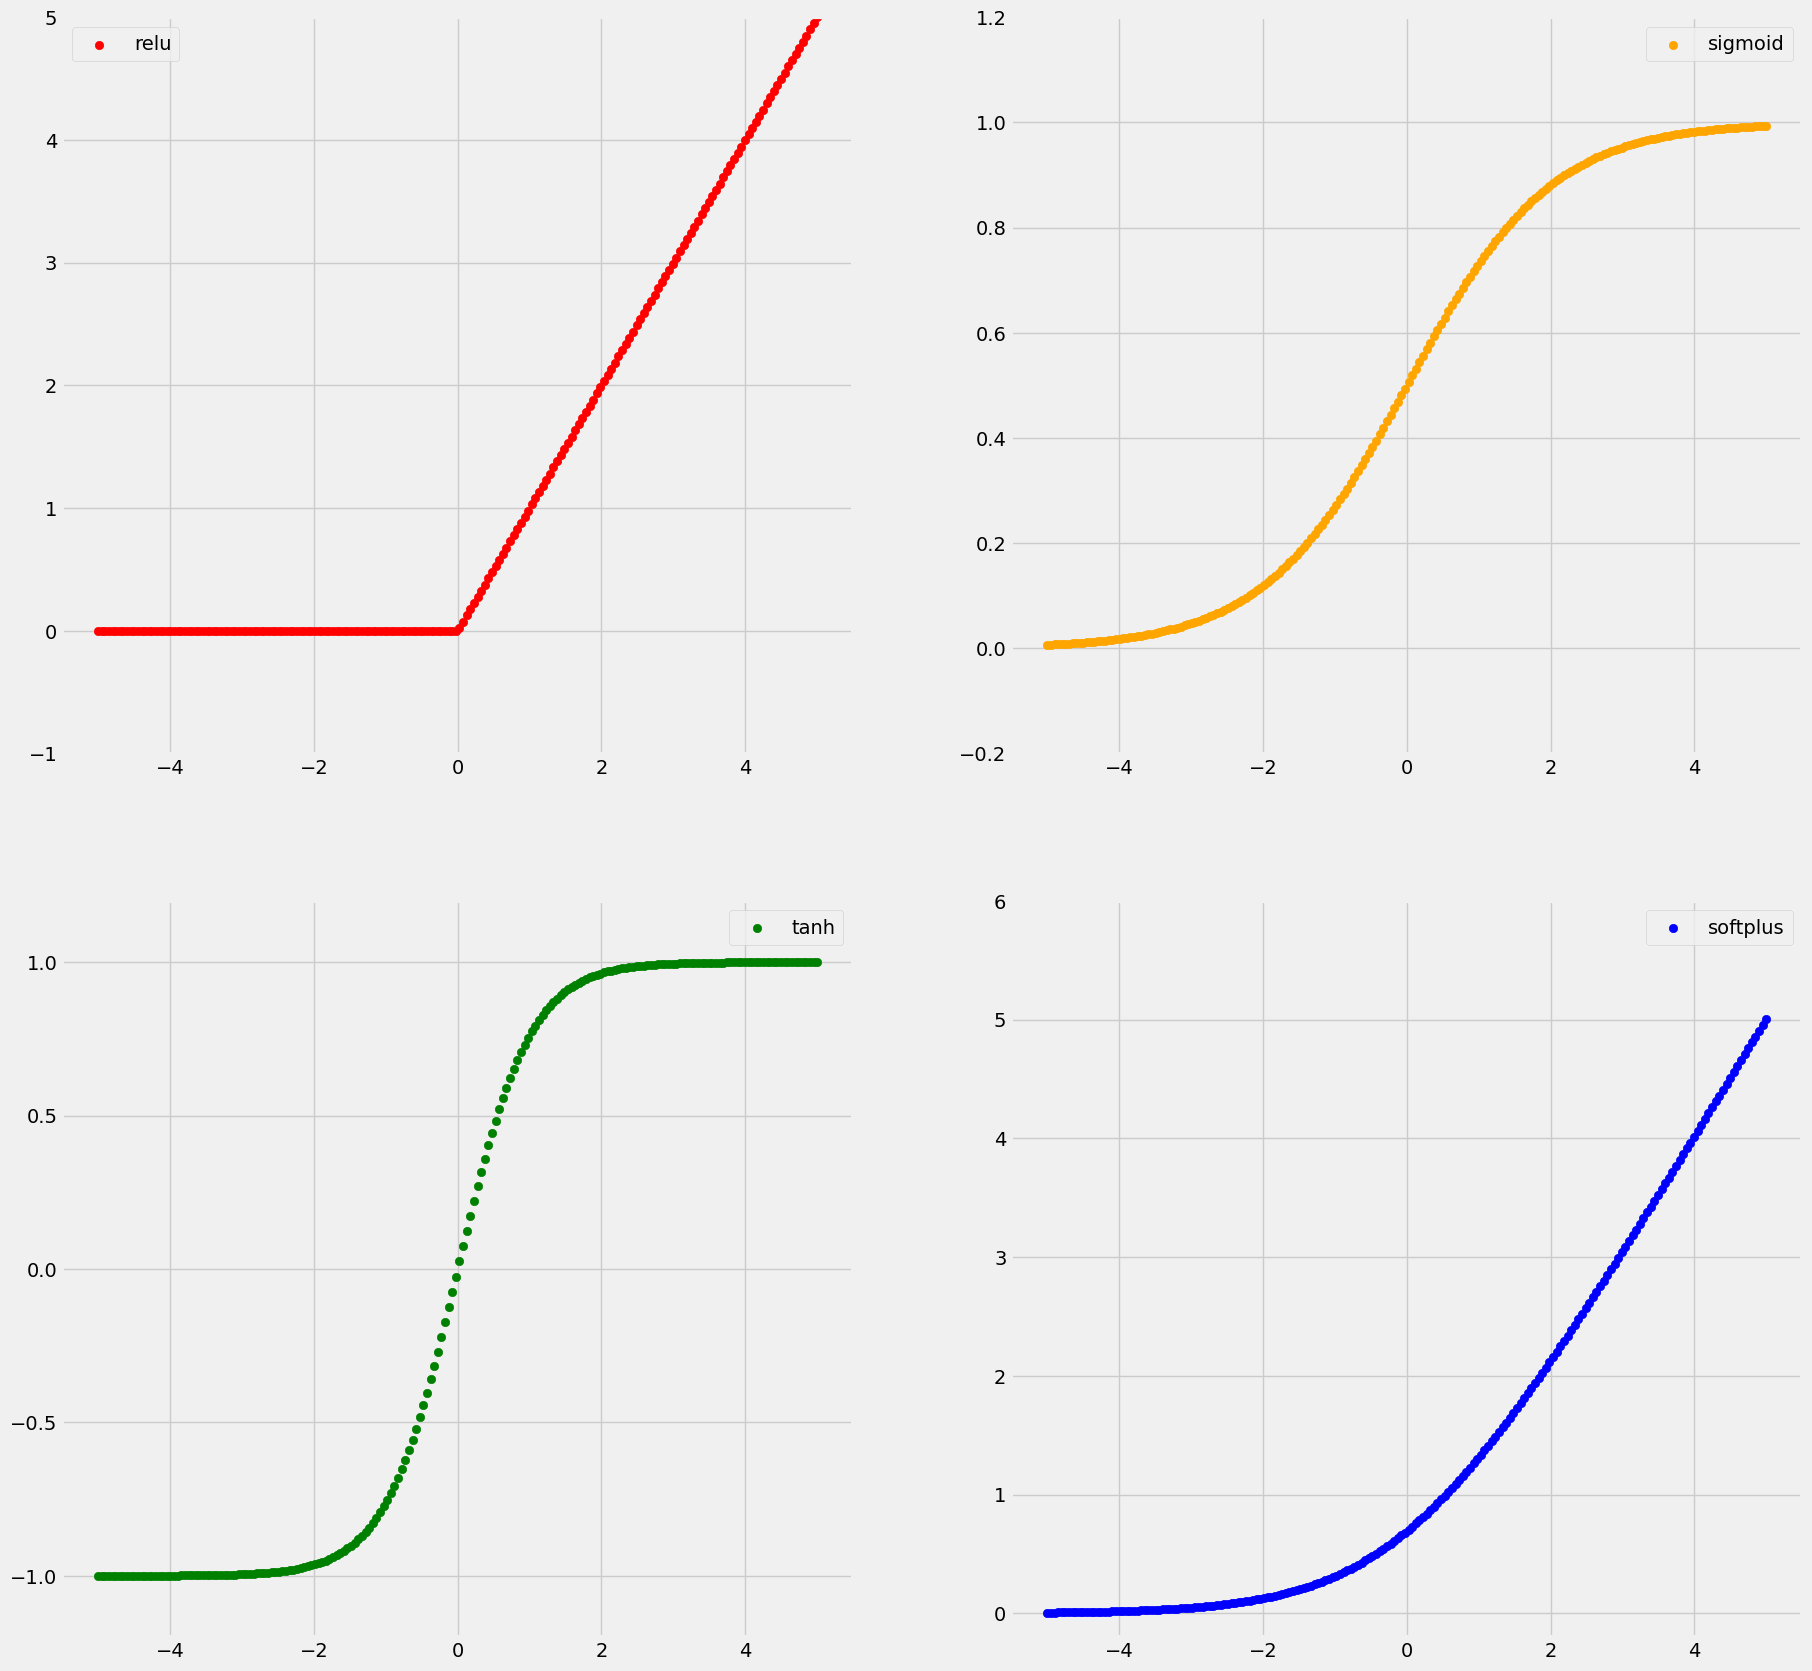

In [30]:
%matplotlib inline

plt.figure(1, figsize=(20, 20))
plt.subplot(221)
plt.scatter(x_np, y_relu, c='red', label='relu')
plt.ylim((-1, 5))
plt.legend(loc='best')

plt.subplot(222)
plt.scatter(x_np, y_sigmoid, c='orange', label='sigmoid')
plt.ylim((-0.2, 1.2))
plt.legend(loc='best')

plt.subplot(223)
plt.scatter(x_np, y_tanh, c='green', label='tanh')
plt.ylim((-1.2, 1.2))
plt.legend(loc='best')

plt.subplot(224)
plt.scatter(x_np, y_softplus, c='blue', label='softplus')
plt.ylim((-0.2, 6))
plt.legend(loc='best')

plt.show()

Section : 2. Neural Network
---

---
### Linear Regression

---

* It is worth underlining that this is an example focused on re-applying the techniques introduced. Indeed, PyTorch offers much more advanced methodologies to accomplish the same task, introduced in the following tutorials.
* In this example we will consider a simple one-dimensional synthetic problem (with some added noise):
Example :
![](https://i.pinimg.com/564x/cd/6e/c7/cd6ec7106cfd22cdfd5c542a84a8b869.jpg)

In [31]:
X = np.random.rand(30, 1)*2.0
w = np.random.rand(2, 1)
y = X*w[0] + w[1] + np.random.randn(30, 1) * 0.05

![](https://iaml.it/blog/fun-with-pytorch-part-1/images/regressione_lineare_1.png)

In order to detect the line's coefficient, we define a linear model:
#### Define Weight and Bias

In [32]:
W = Variable(torch.rand(1, 1), requires_grad=True)
b = Variable(torch.rand(1), requires_grad=True)

def linear(x):
    return torch.matmul(x, W) + b

* Using `torch.matmul` is redundant in this case, but we want the function to be as general as possible to be re-used for more complex models.

In [33]:
Xt = torch.from_numpy(X).float()
yt = torch.from_numpy(y).float()

for epoch in range(2500):
    # Compute predictions
    y_pred = linear(Xt)

    # Mean-squared error
    loss = torch.mean((y_pred - yt) ** 2)

    # Back-propagation
    loss.backward()

    # Manual SGD update (under no_grad to avoid tracking)
    with torch.no_grad():
        W -= 0.005 * W.grad
        b -= 0.005 * b.grad
        W.grad.zero_()
        b.grad.zero_()

print("Trained W:", W.item(), "| b:", b.item(), "| final loss:", loss.item())

Trained W: 0.2482290416955948 | b: 0.8190244436264038 | final loss: 0.002896449761465192


* After Training we can see the graph like this
![](https://iaml.it/blog/fun-with-pytorch-part-1/images/regressione_lineare_2.png)

### Relationship Fitting Regression Model
---

> In statistical modeling, regression analysis is a set of statistical processes for estimating the relationships among variables. It includes many techniques for modeling and analyzing several variables, when the focus is on the relationship between a dependent variable and one or more independent variables.

...[Regression Analysis](https://en.wikipedia.org/wiki/Regression_analysis)

![](https://mahritaharahap.files.wordpress.com/2014/06/relationship.png)

In [34]:
import torch
from torch.autograd import Variable
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [35]:
torch.manual_seed(1)    # reproducible

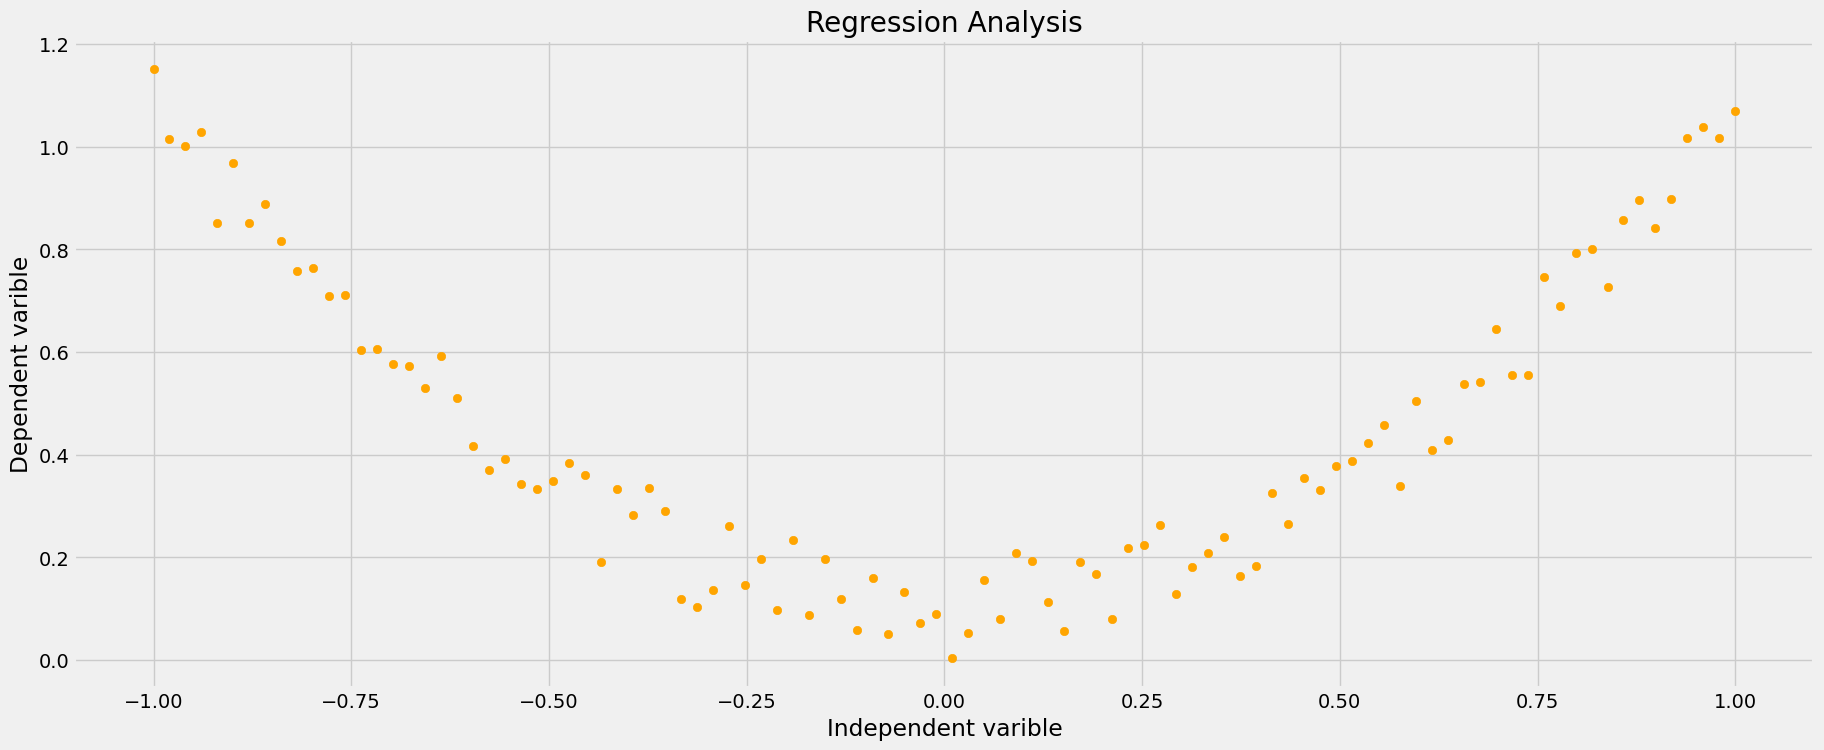

In [36]:
x = torch.unsqueeze(torch.linspace(-1, 1, 100), dim=1)  # x data (tensor), shape=(100, 1)
y = x.pow(2) + 0.2*torch.rand(x.size())                 # noisy y data (tensor), shape=(100, 1)

# torch can only train on Variable, so convert them to Variable
x, y = Variable(x), Variable(y)
plt.figure(figsize=(20,8))
plt.scatter(x.data.numpy(), y.data.numpy(), color = "orange")
plt.title('Regression Analysis')
plt.xlabel('Independent varible')
plt.ylabel('Dependent varible')
plt.show()

### Model Fitting

In [37]:
class Net(torch.nn.Module):
    def __init__(self, n_feature, n_hidden, n_output):
        super(Net, self).__init__()
        self.hidden = torch.nn.Linear(n_feature, n_hidden)   # hidden layer
        self.predict = torch.nn.Linear(n_hidden, n_output)   # output layer

    def forward(self, x):
        x = F.relu(self.hidden(x))      # activation function for hidden layer
        x = self.predict(x)             # linear output
        return x

In [38]:
net = Net(n_feature=1, n_hidden=10, n_output=1)     # define the network
print(net)  # net architecture

Net(
  (hidden): Linear(in_features=1, out_features=10, bias=True)
  (predict): Linear(in_features=10, out_features=1, bias=True)
)


* **Optimizer** - It is the most popular Optimization algorithms used in optimizing a Neural Network. Now gradient descent is majorly used to do Weights updates in a Neural Network Model , i.e update and tune the Model's parameters in a direction so that we can minimize the Loss function.

In [39]:
optimizer = torch.optim.SGD(net.parameters(), lr=0.2)
loss_func = torch.nn.MSELoss()  # this is for regression mean squared loss

In [40]:
plt.ion()   # something about plotting

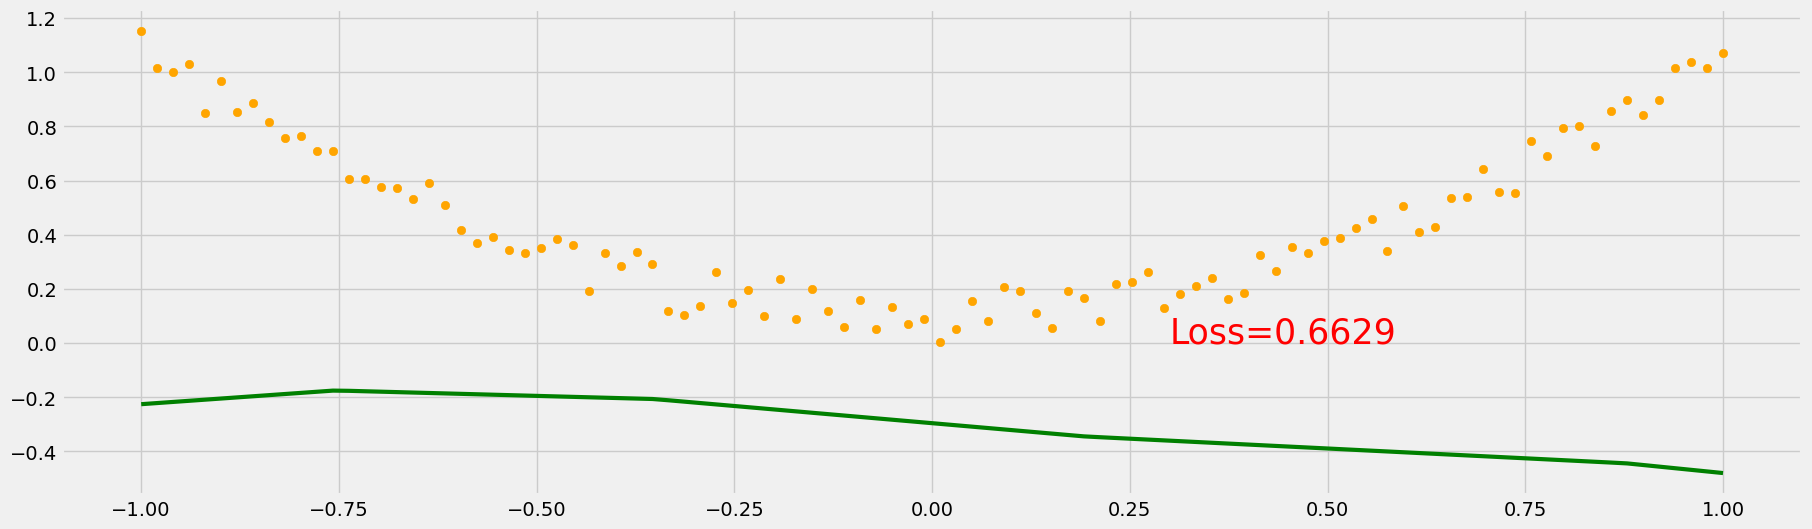

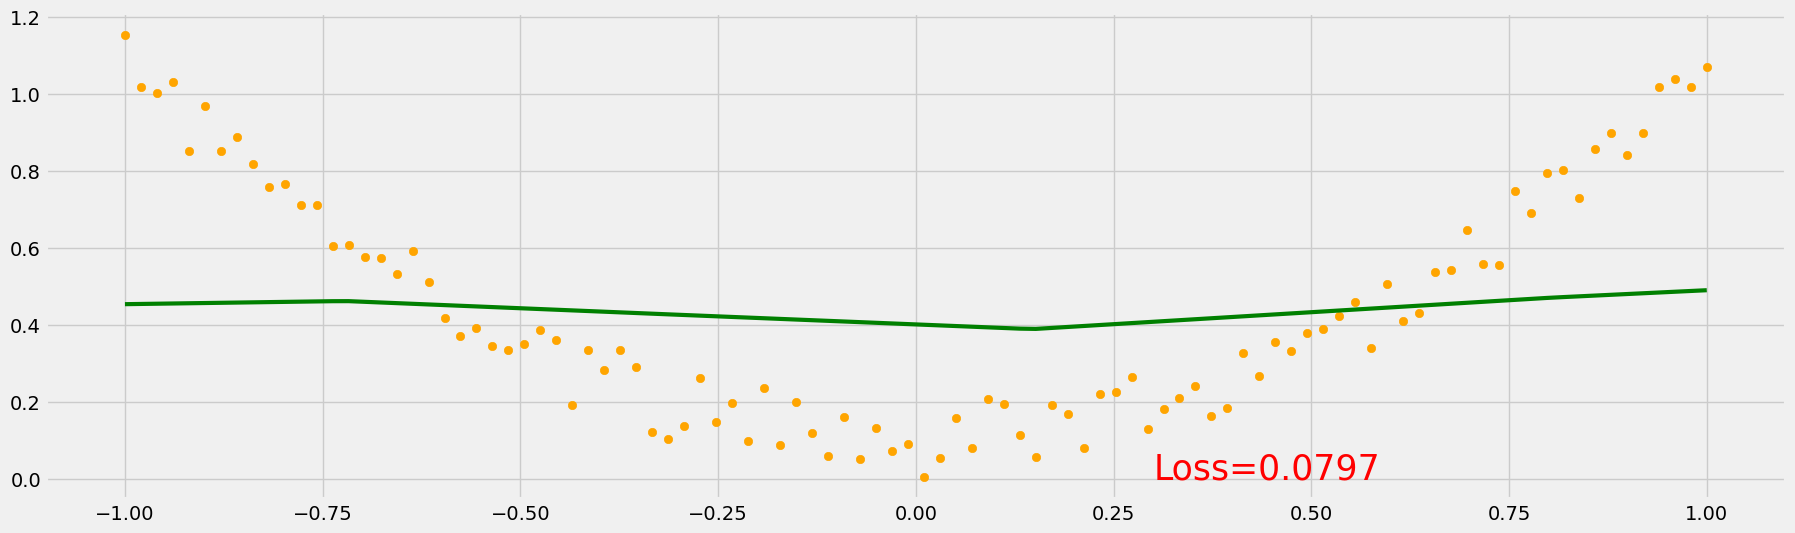

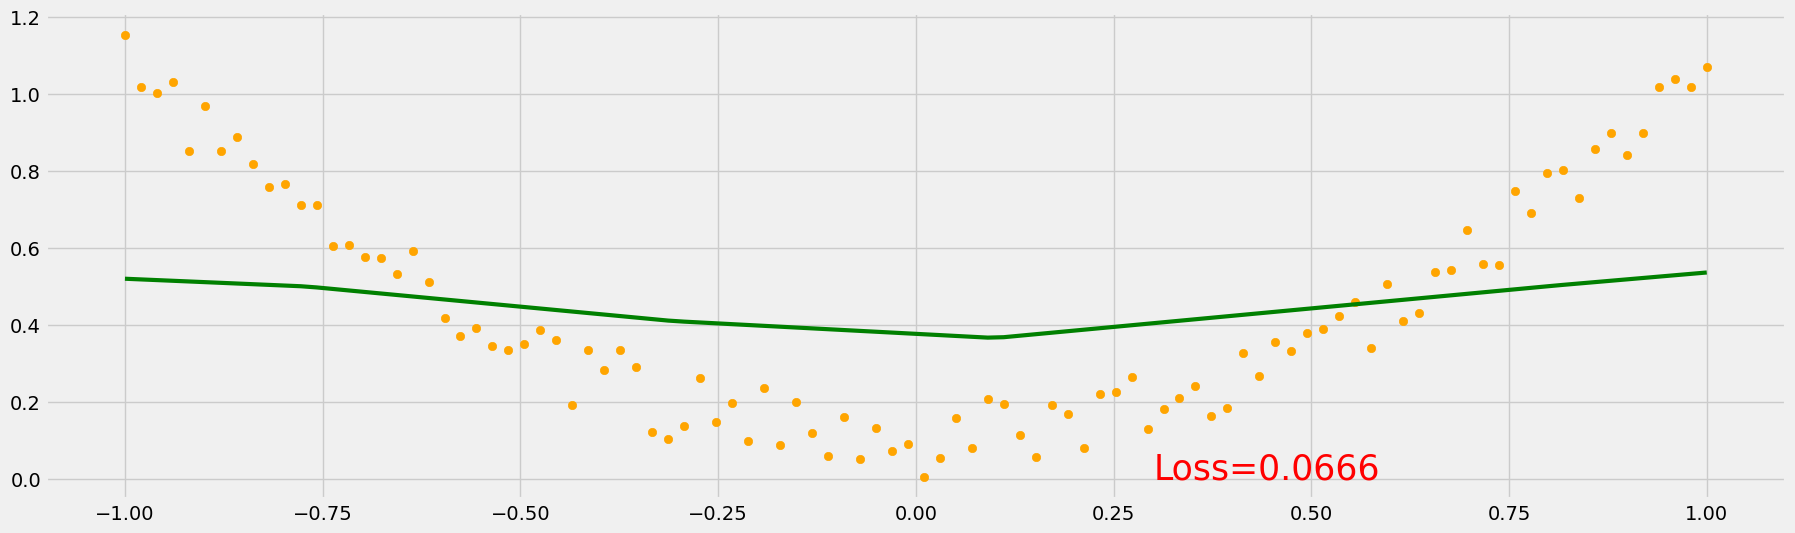

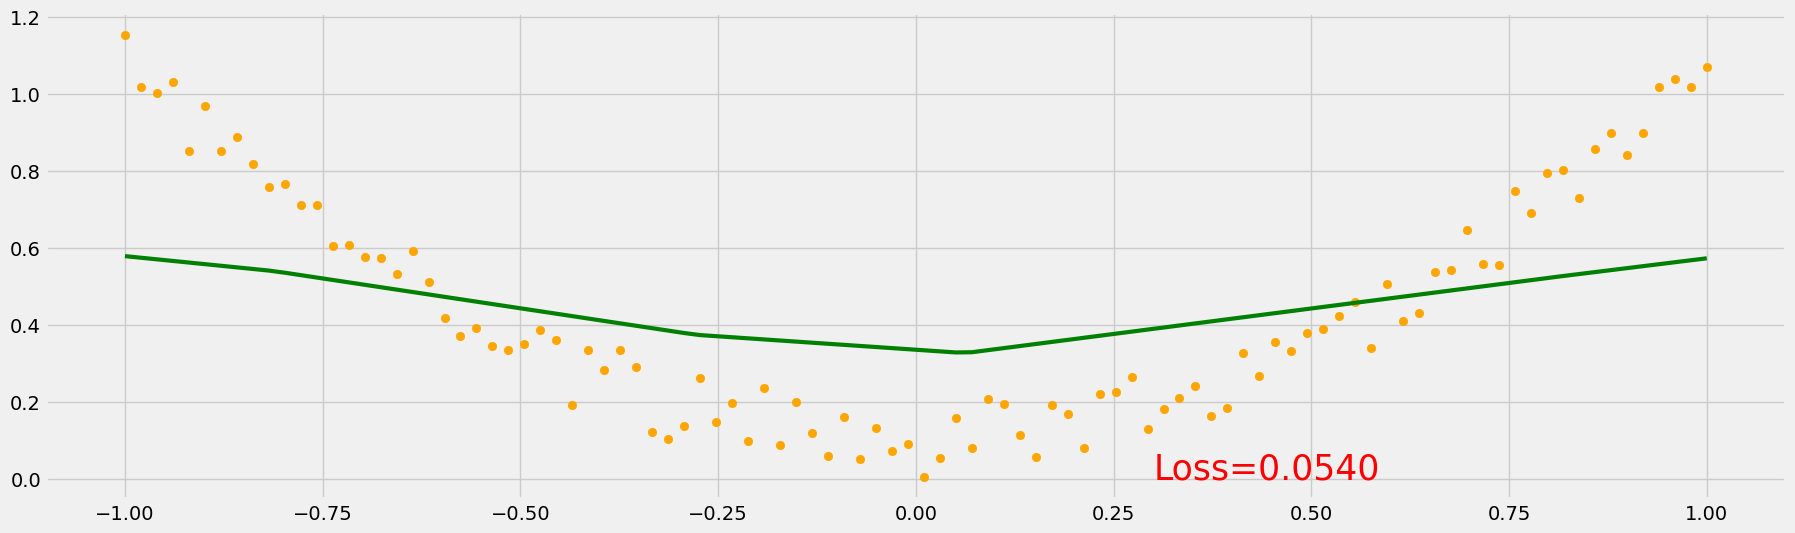

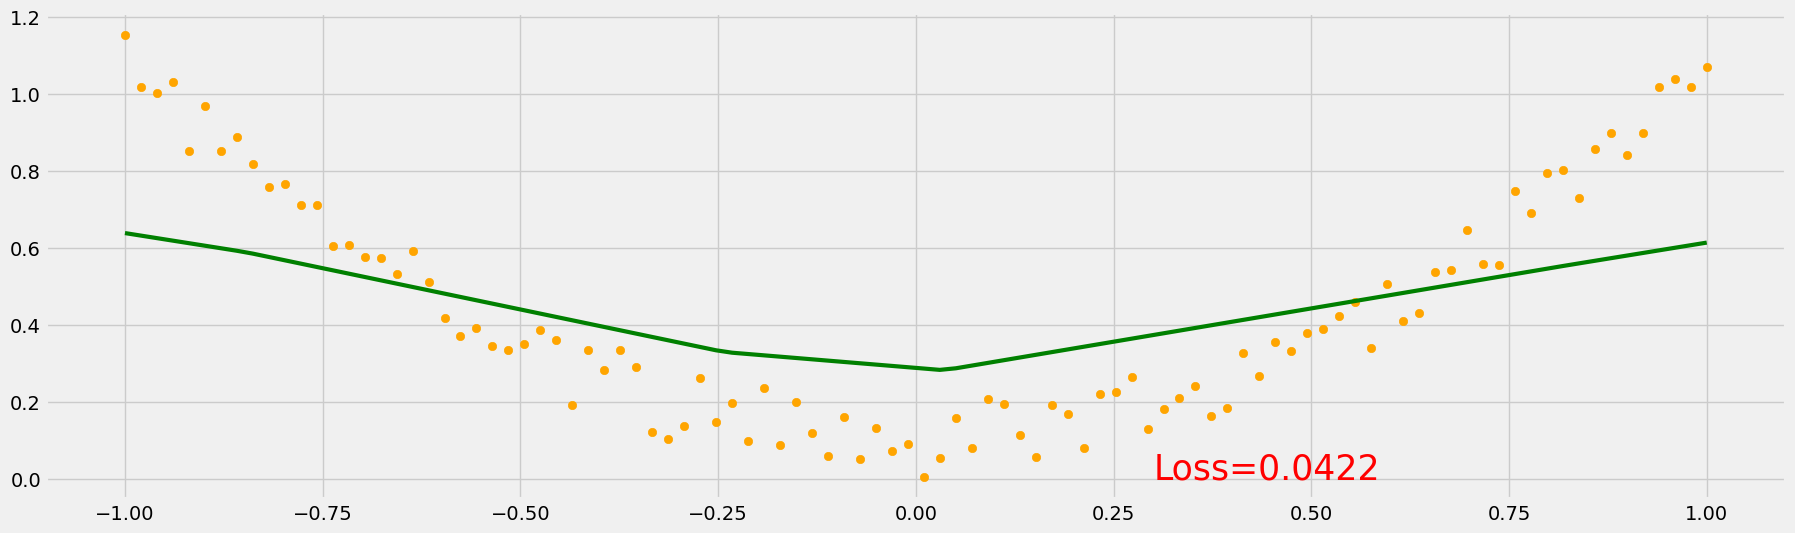

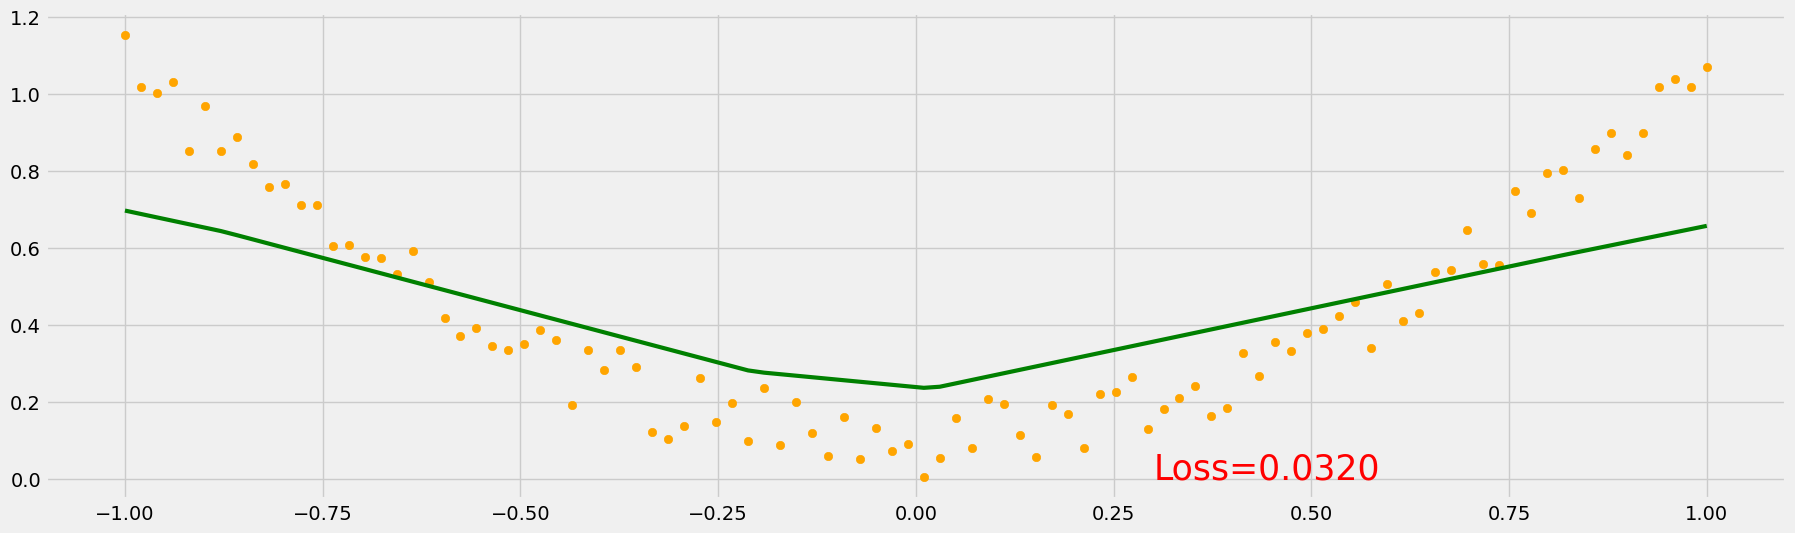

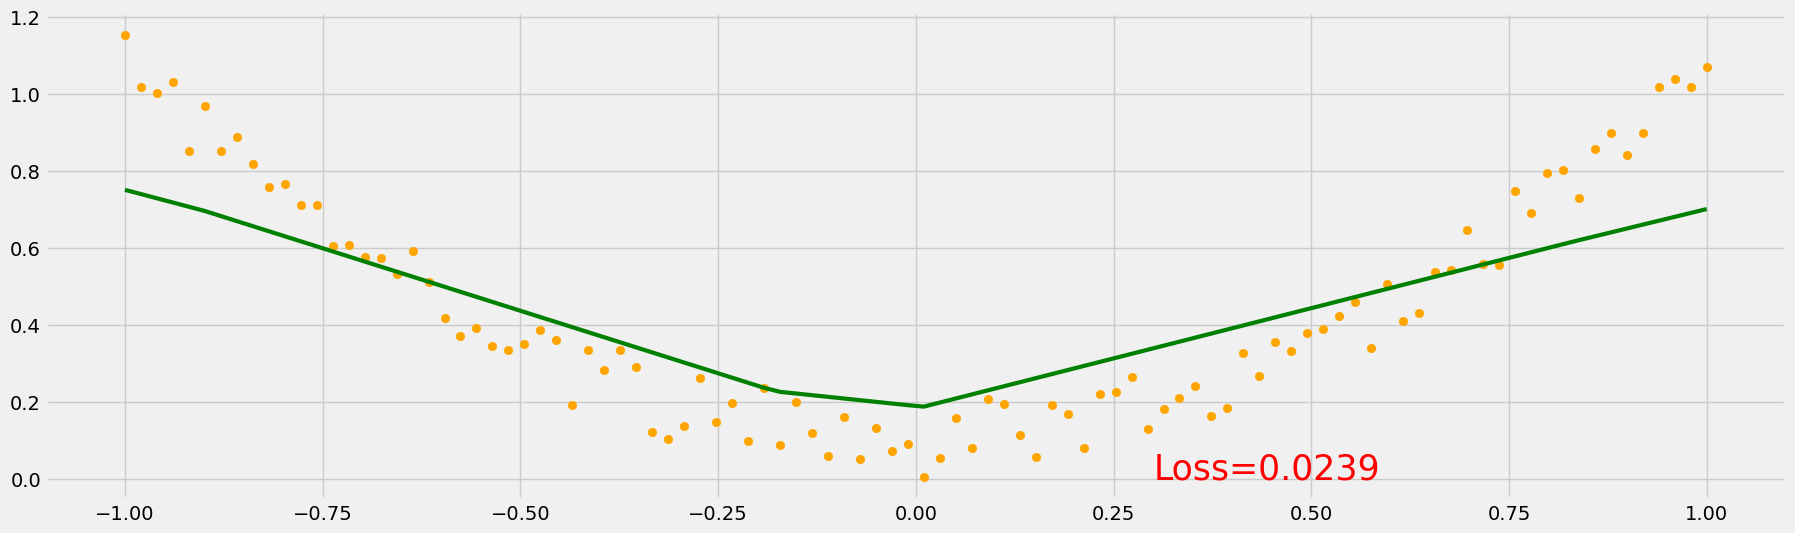

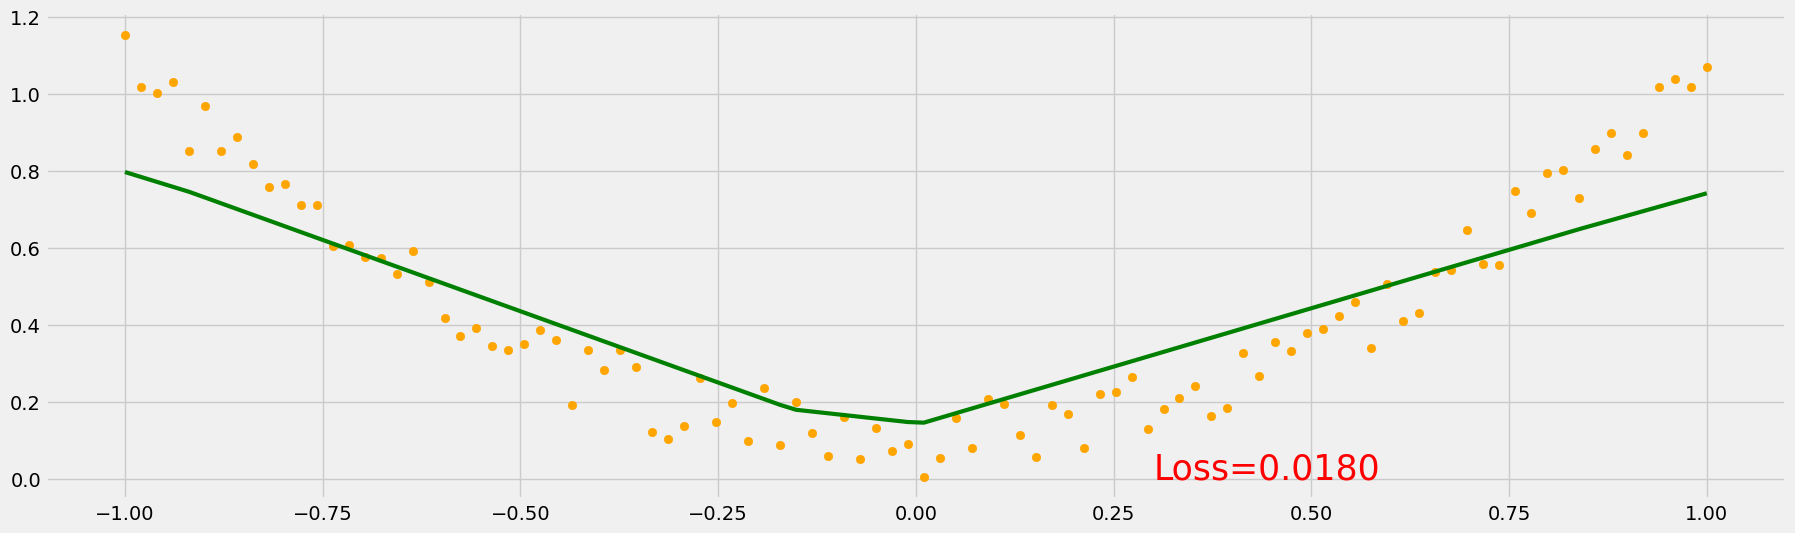

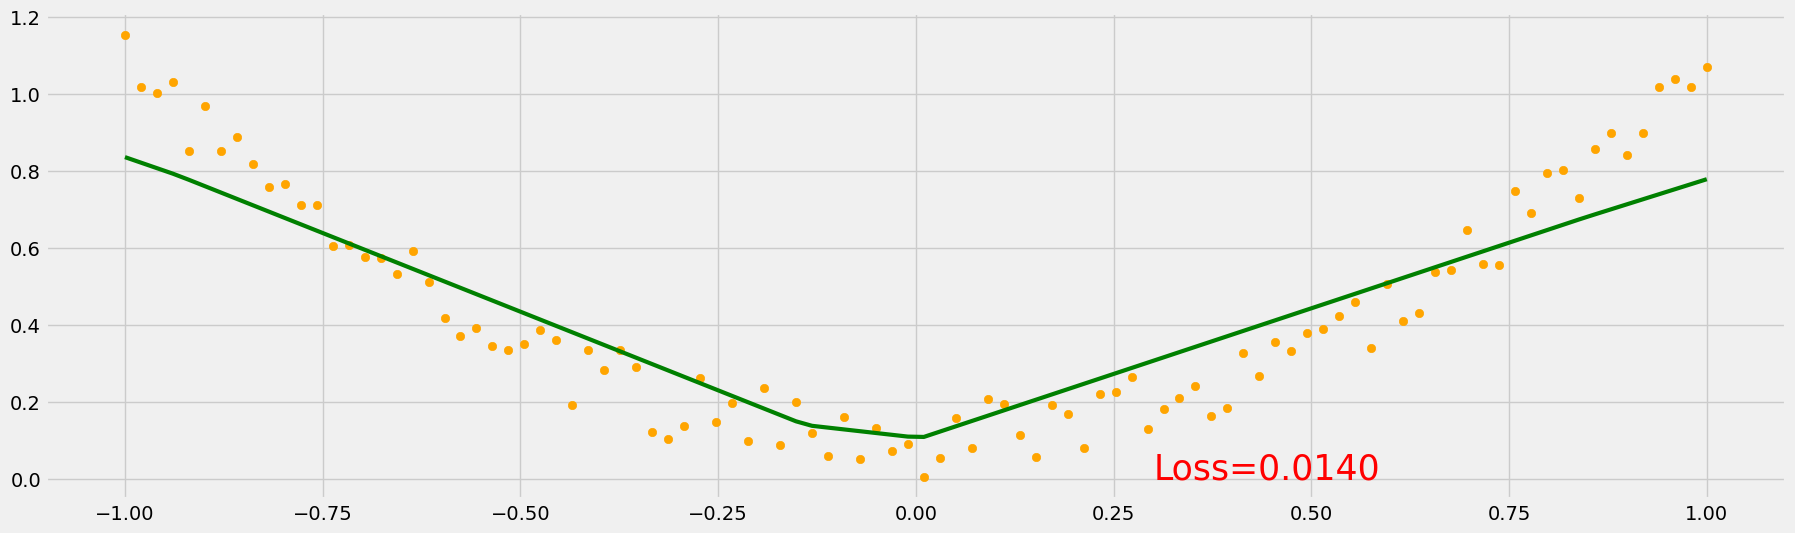

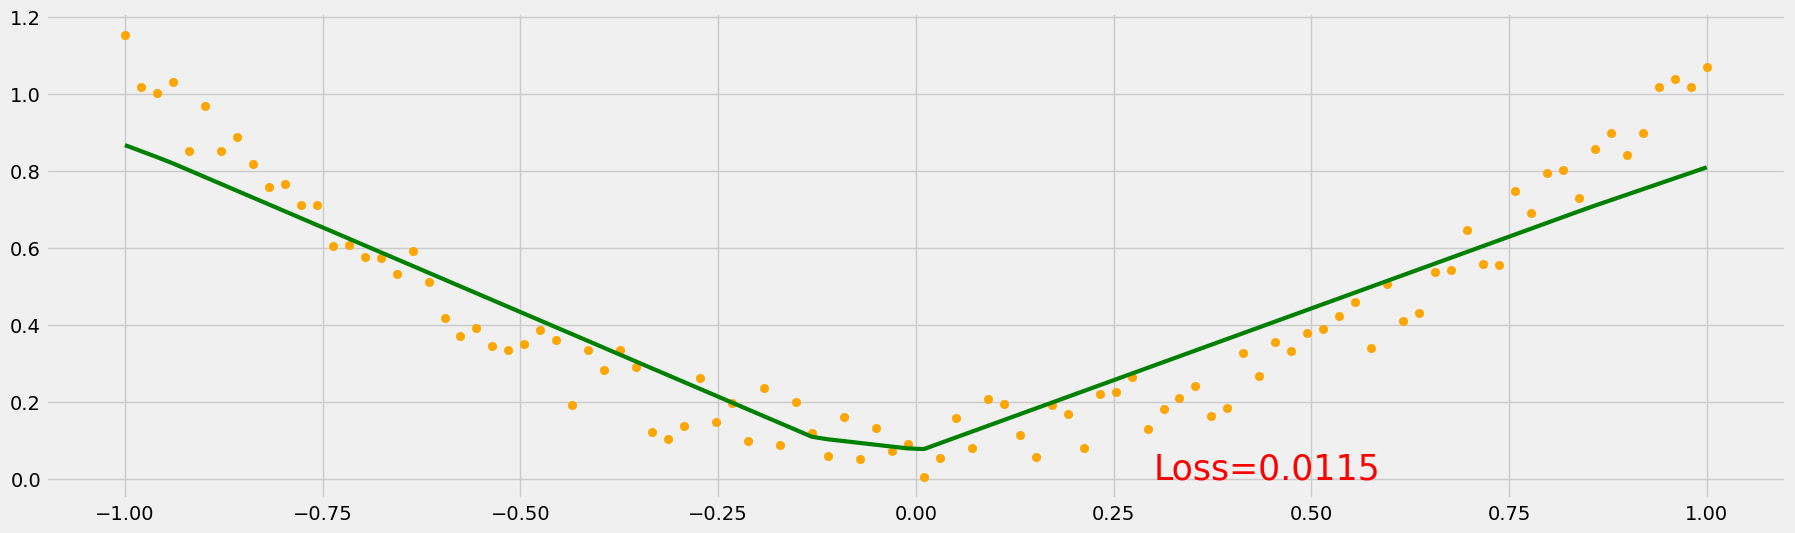

In [41]:
for t in range(100):
    prediction = net(x)

    loss = loss_func(prediction, y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if t % 10 == 0:
        plt.figure(figsize=(20, 6))
        plt.cla()
        plt.scatter(x.data.numpy(), y.data.numpy(), color="orange")
        plt.plot(x.data.numpy(), prediction.data.numpy(), 'g-', lw=3)
        plt.text(0.3, 0, 'Loss=%.4f' % loss.item(),
                 fontdict={'size': 25, 'color': 'red'})
        plt.show()

### Distinguish type classification
---
* Classification is a data mining function that assigns items in a collection to target categories or classes. The goal of classification is to accurately predict the target class for each case in the data. For example, a classification model could be used to identify loan applicants as low, medium, or high credit risks.

![](https://morvanzhou.github.io/static/results/torch/1-1-3.gif)

In [42]:
import torch
from torch.autograd import Variable
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

torch.manual_seed(1)    # reproducible

### Generate Fake Data

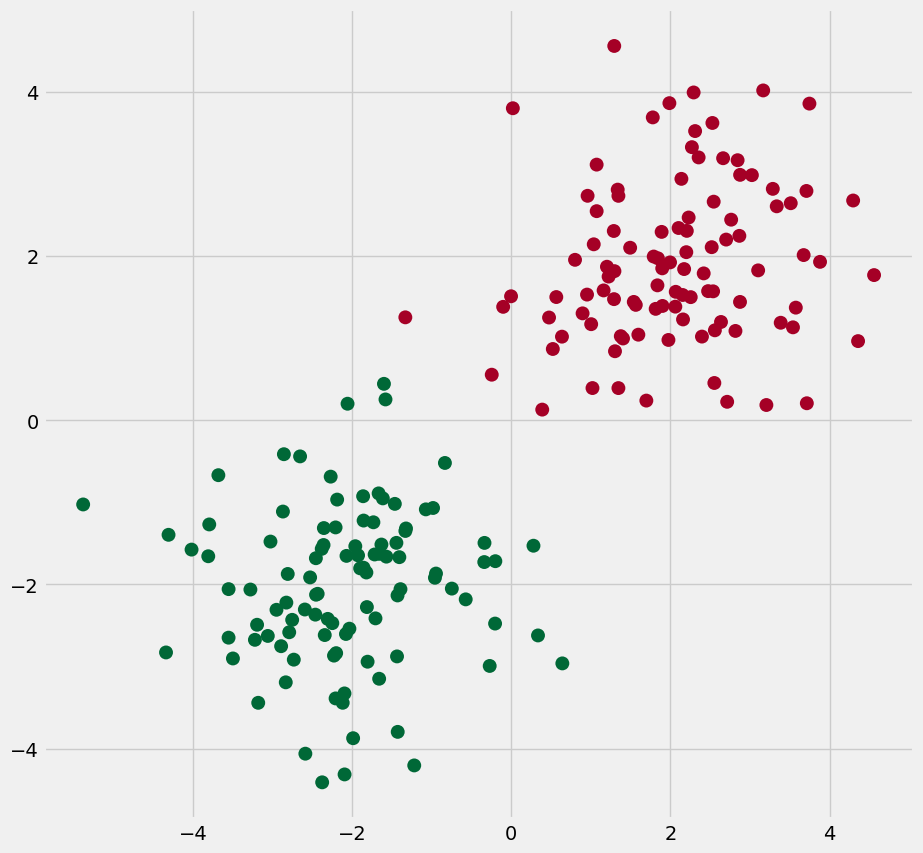

In [43]:
n_data = torch.ones(100, 2)
x0 = torch.normal(2*n_data, 1)      # class0 x data (tensor), shape=(100, 2)
y0 = torch.zeros(100)               # class0 y data (tensor), shape=(100, 1)
x1 = torch.normal(-2*n_data, 1)     # class1 x data (tensor), shape=(100, 2)
y1 = torch.ones(100)                # class1 y data (tensor), shape=(100, 1)
x = torch.cat((x0, x1), 0).type(torch.FloatTensor)  # shape (200, 2) FloatTensor = 32-bit floating
y = torch.cat((y0, y1), ).type(torch.LongTensor)    # shape (200,) LongTensor = 64-bit integer

# torch can only train on Variable, so convert them to Variable
x, y = Variable(x), Variable(y)
plt.figure(figsize=(10,10))
plt.scatter(x.data.numpy()[:, 0], x.data.numpy()[:, 1], c=y.data.numpy(), s=100, lw=0, cmap='RdYlGn')
plt.show()

### Model design

In [44]:
class Net(torch.nn.Module):
    def __init__(self, n_feature, n_hidden, n_output):
        super(Net, self).__init__()
        self.hidden = torch.nn.Linear(n_feature, n_hidden)   # hidden layer
        self.out = torch.nn.Linear(n_hidden, n_output)   # output layer

    def forward(self, x):
        x = F.relu(self.hidden(x))      # activation function for hidden layer
        x = self.out(x)
        return x

### Define Network

In [45]:
net = Net(n_feature=2, n_hidden=10, n_output=2)     # define the network
print(net)  # net architecture

# Loss and Optimizer
# Softmax is internally computed.
# Set parameters to be updated.
optimizer = torch.optim.SGD(net.parameters(), lr=0.02)
loss_func = torch.nn.CrossEntropyLoss()  # the target label is NOT an one-hotted

Net(
  (hidden): Linear(in_features=2, out_features=10, bias=True)
  (out): Linear(in_features=10, out_features=2, bias=True)
)


### Plot the Model

In [46]:
plt.ion()   # something about plotting

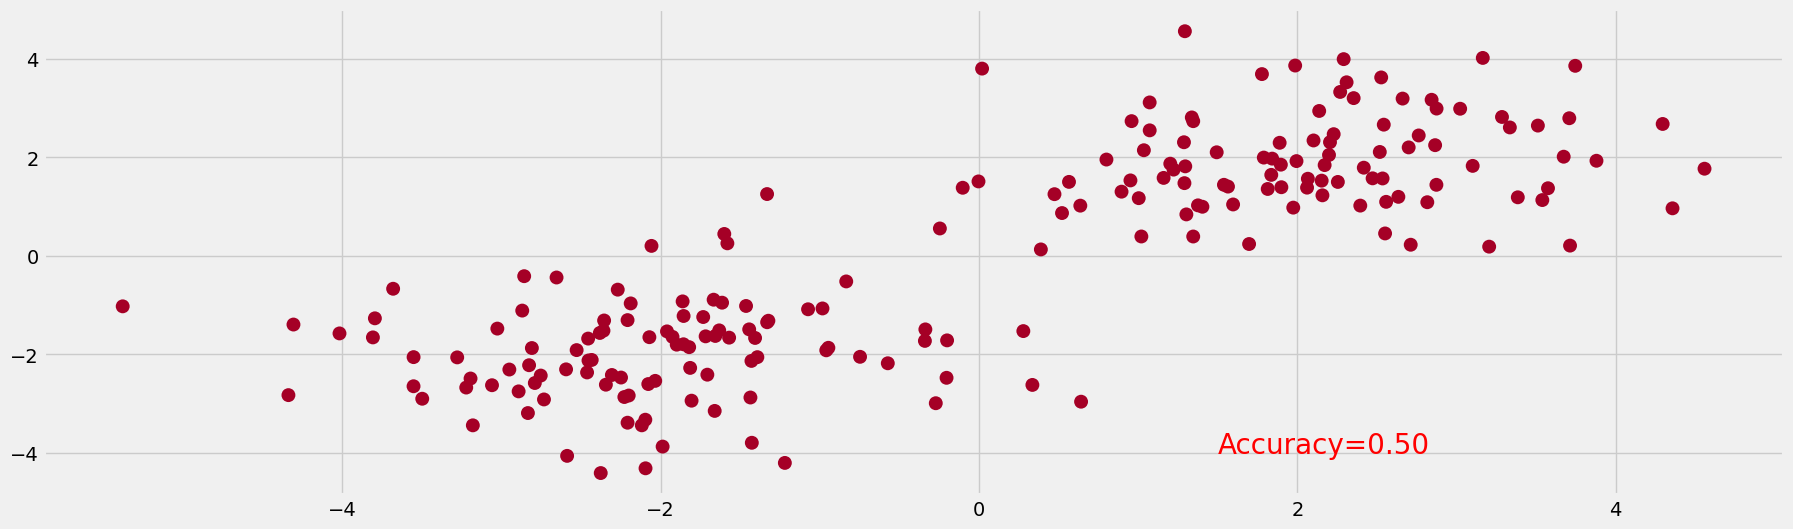

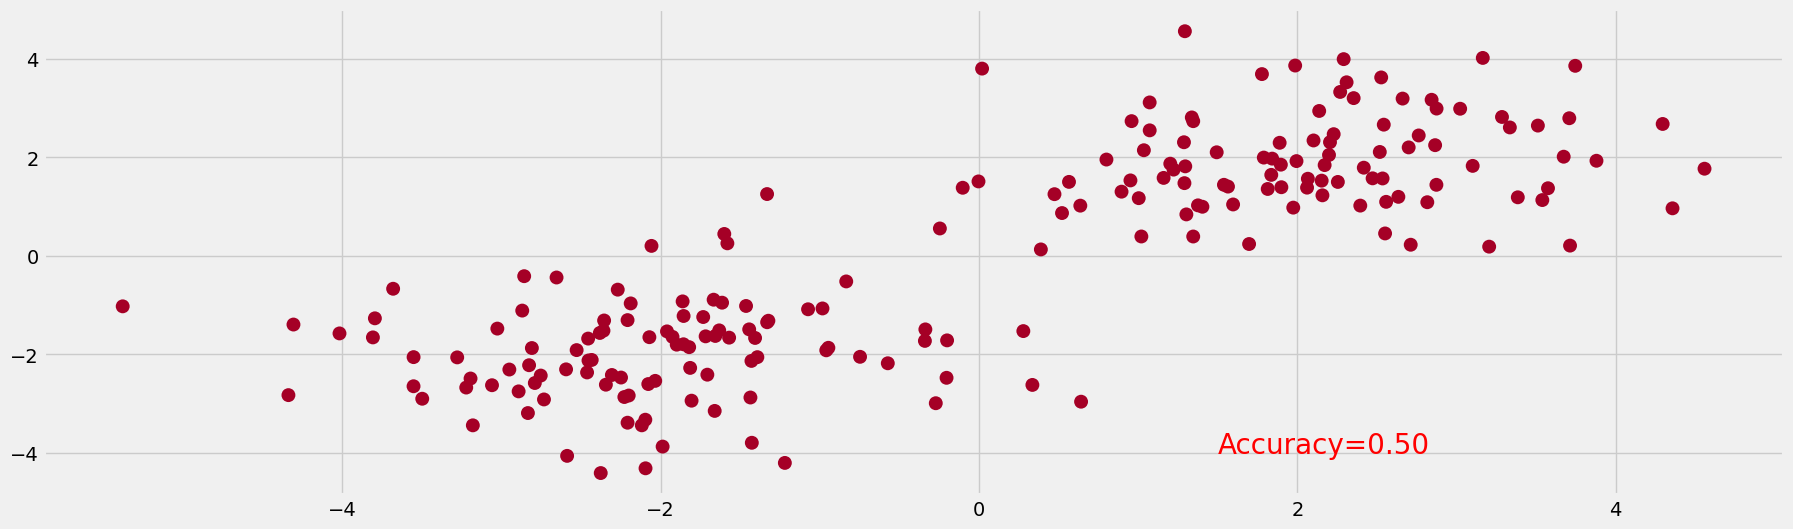

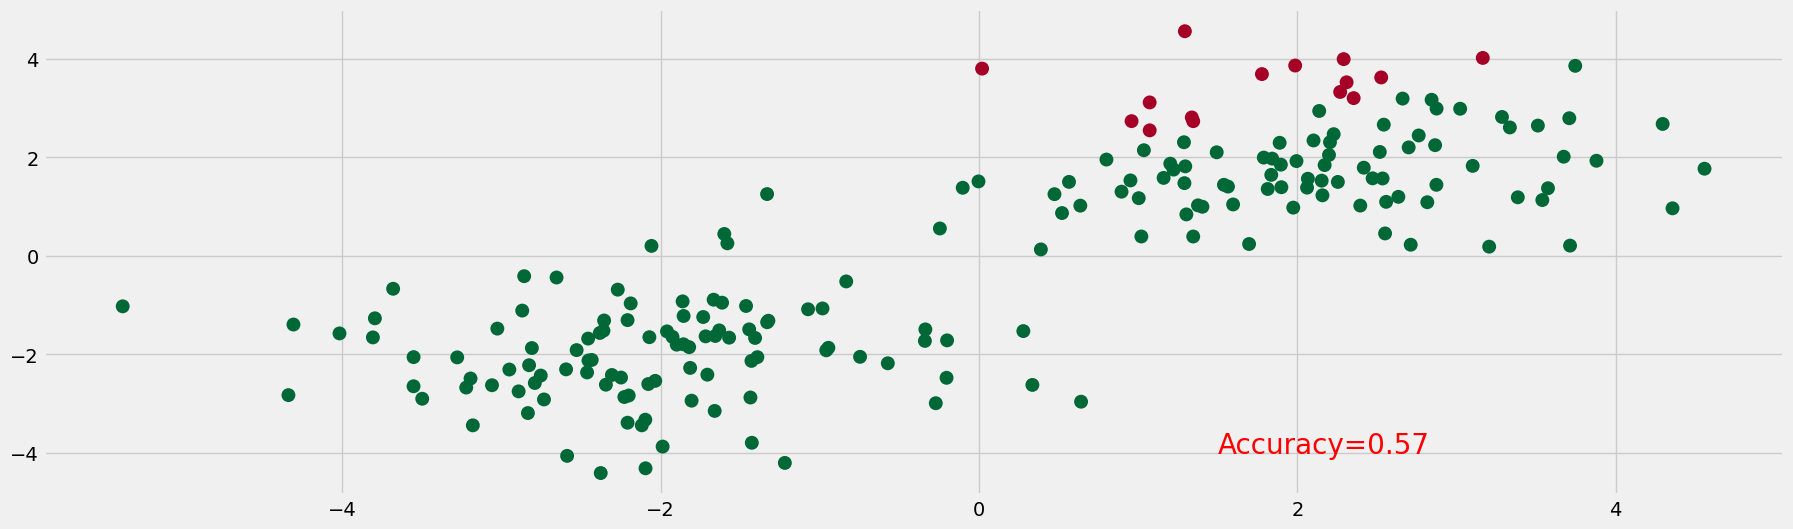

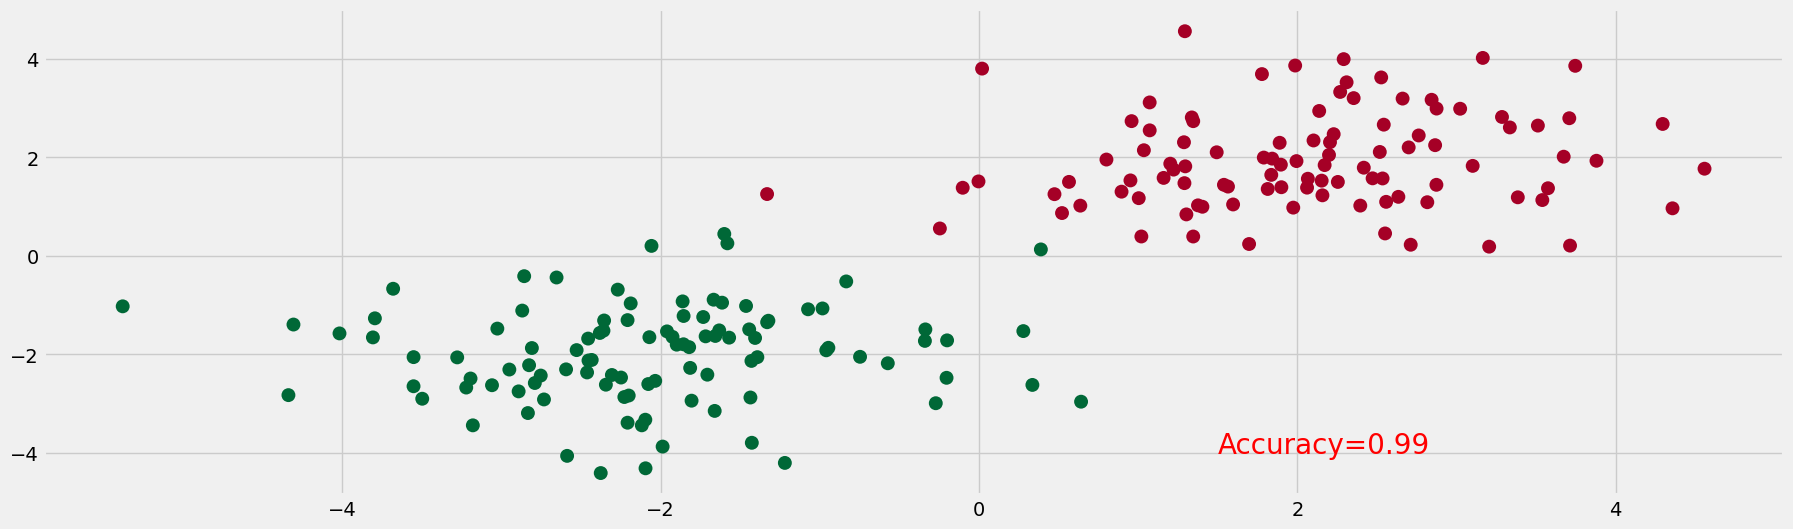

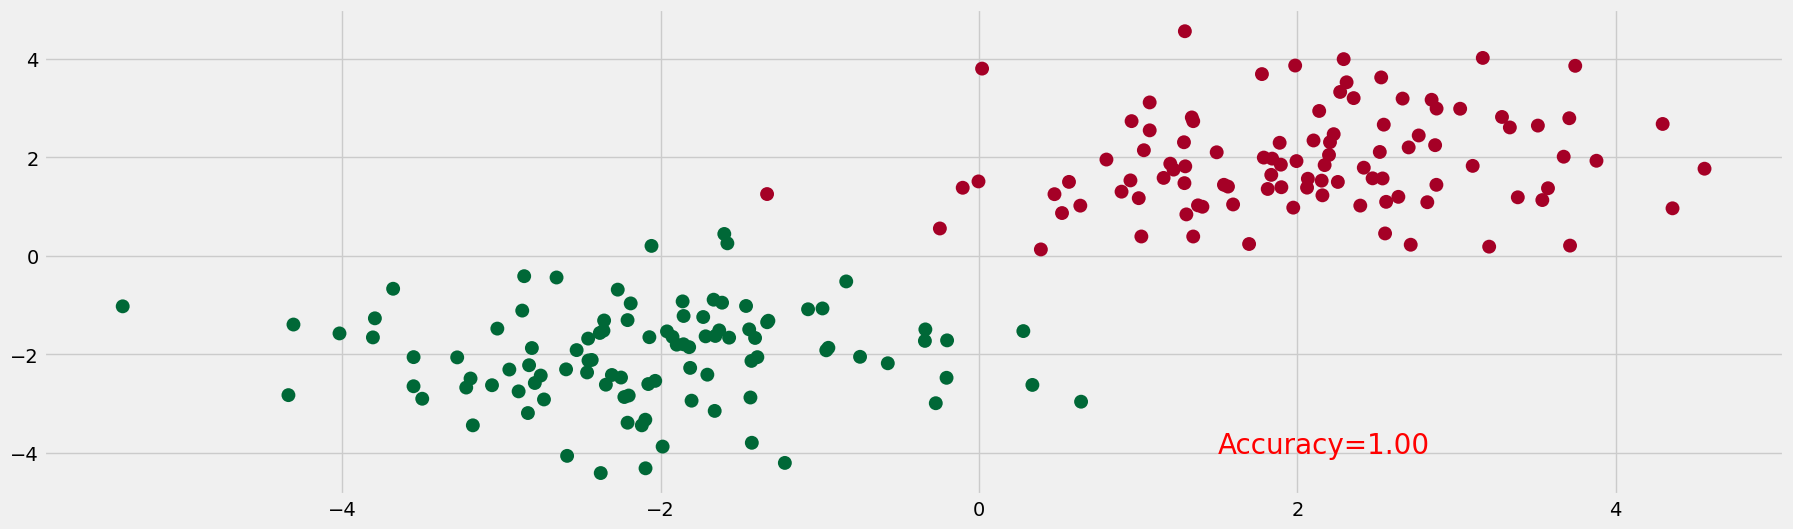

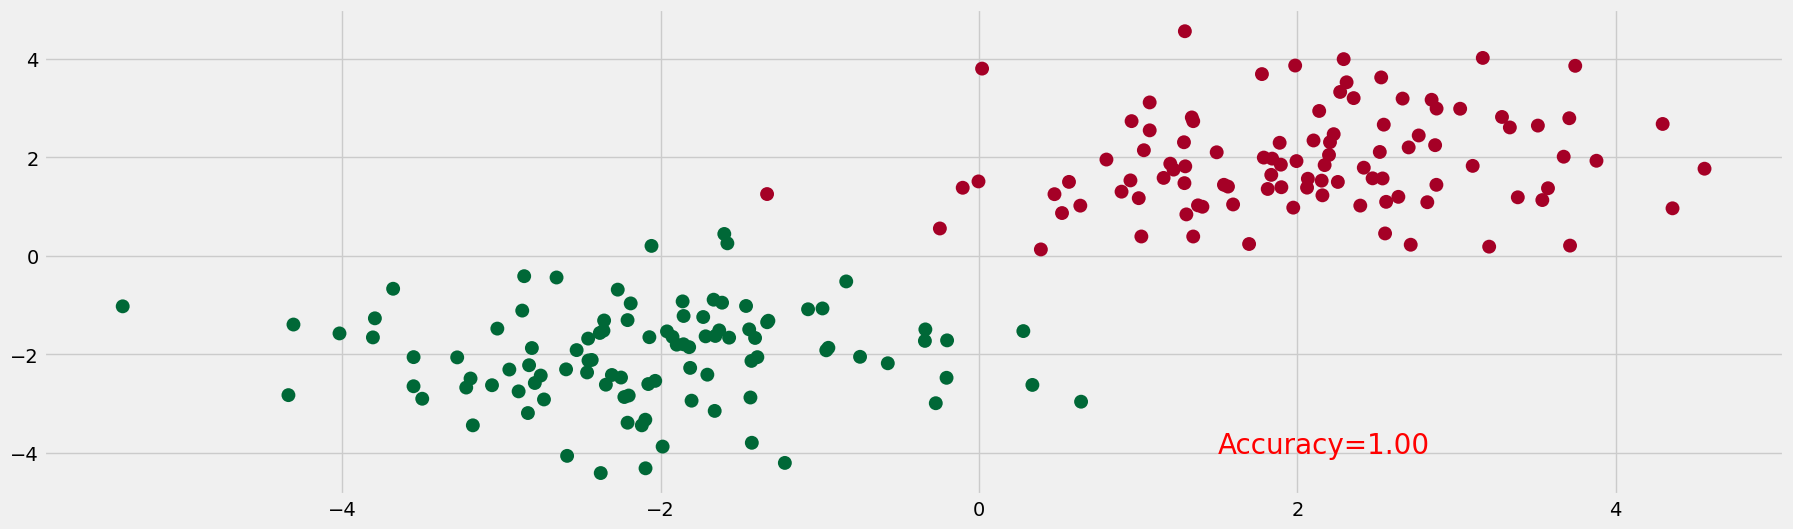

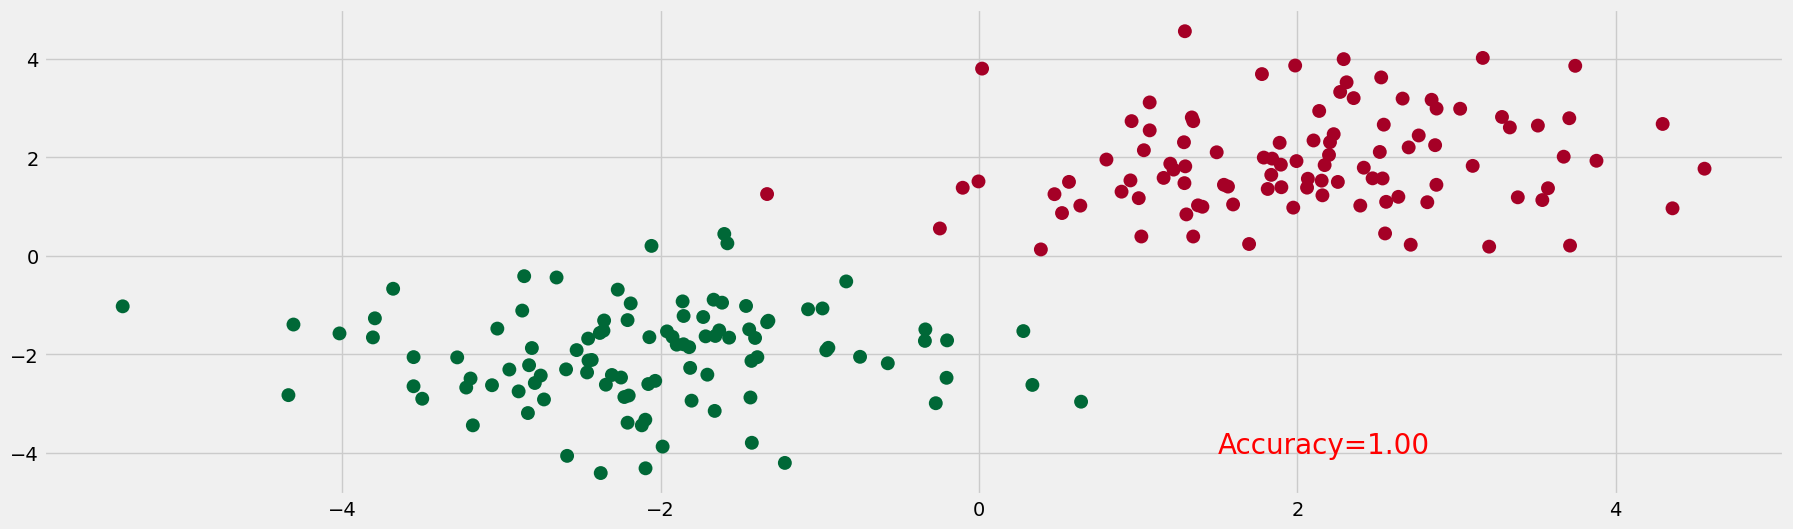

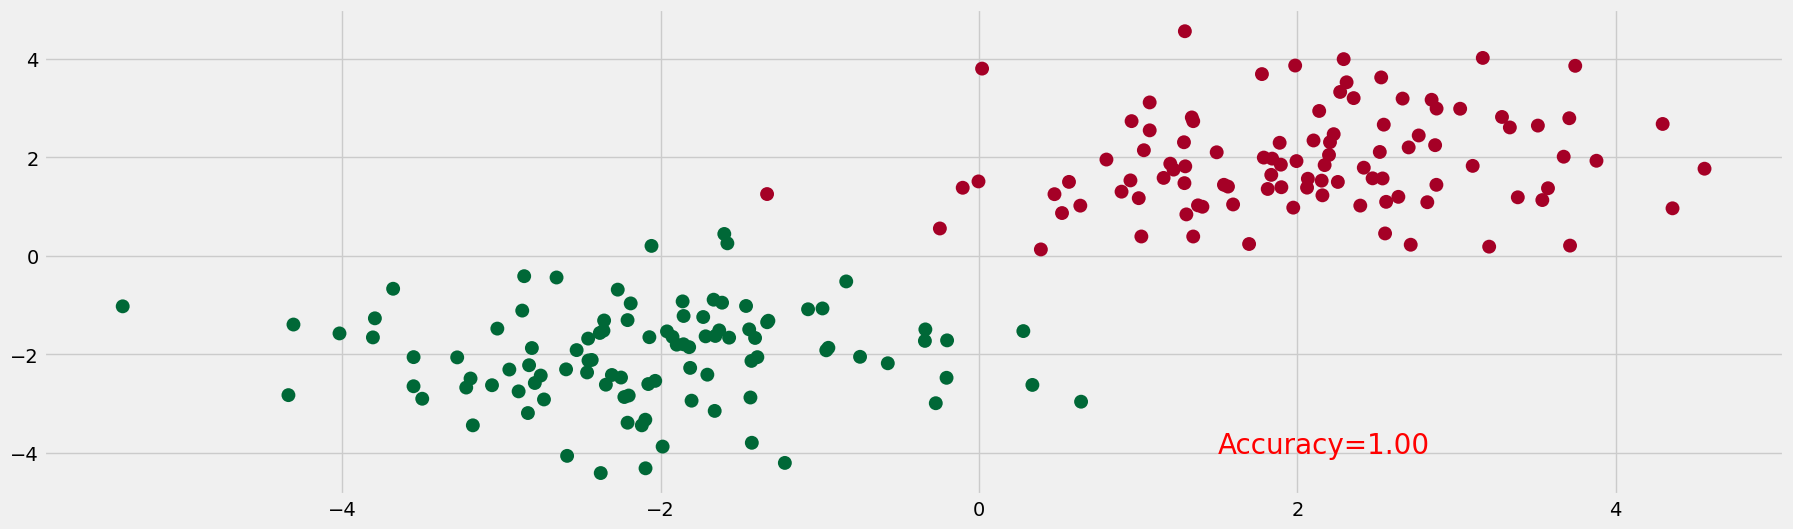

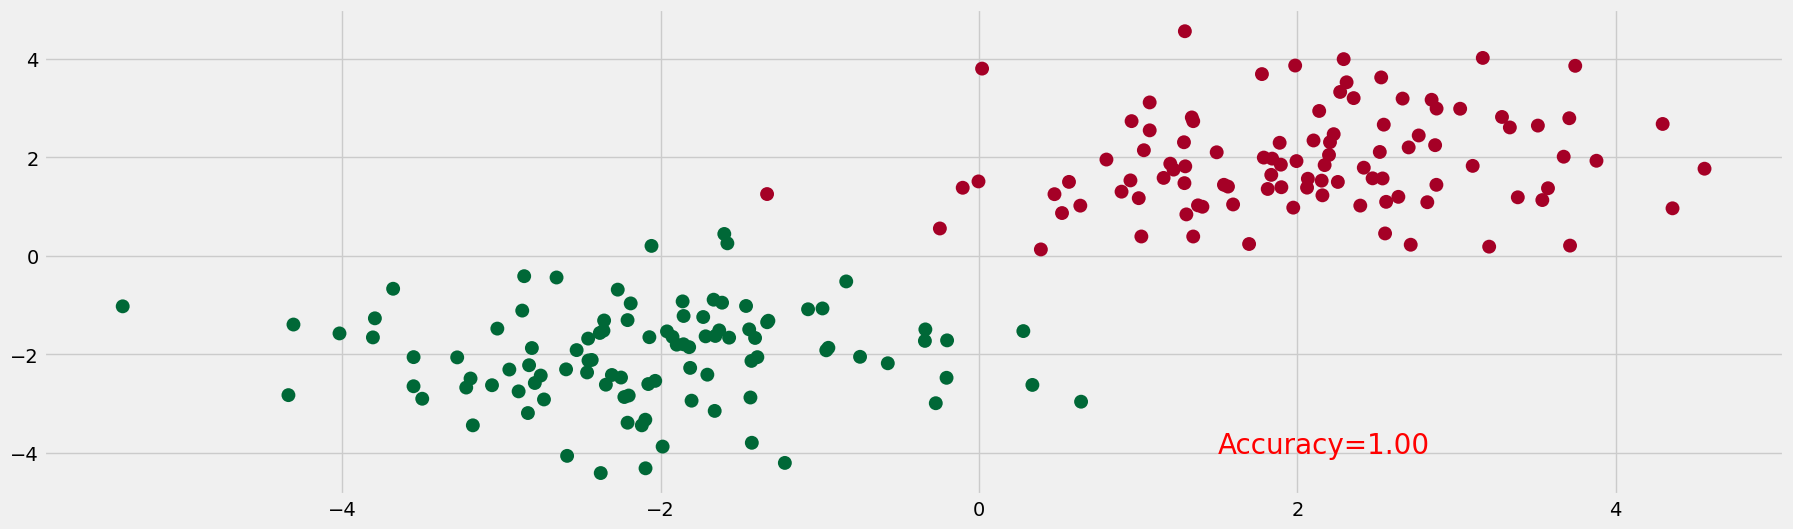

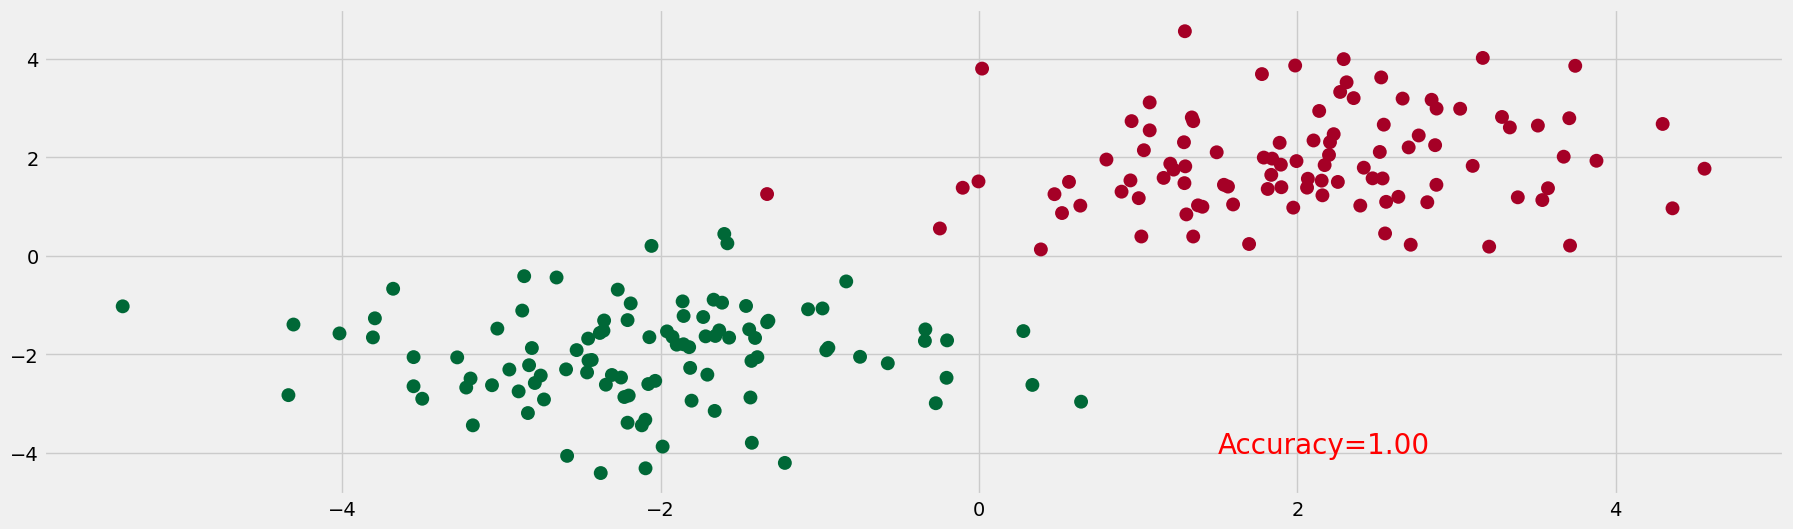

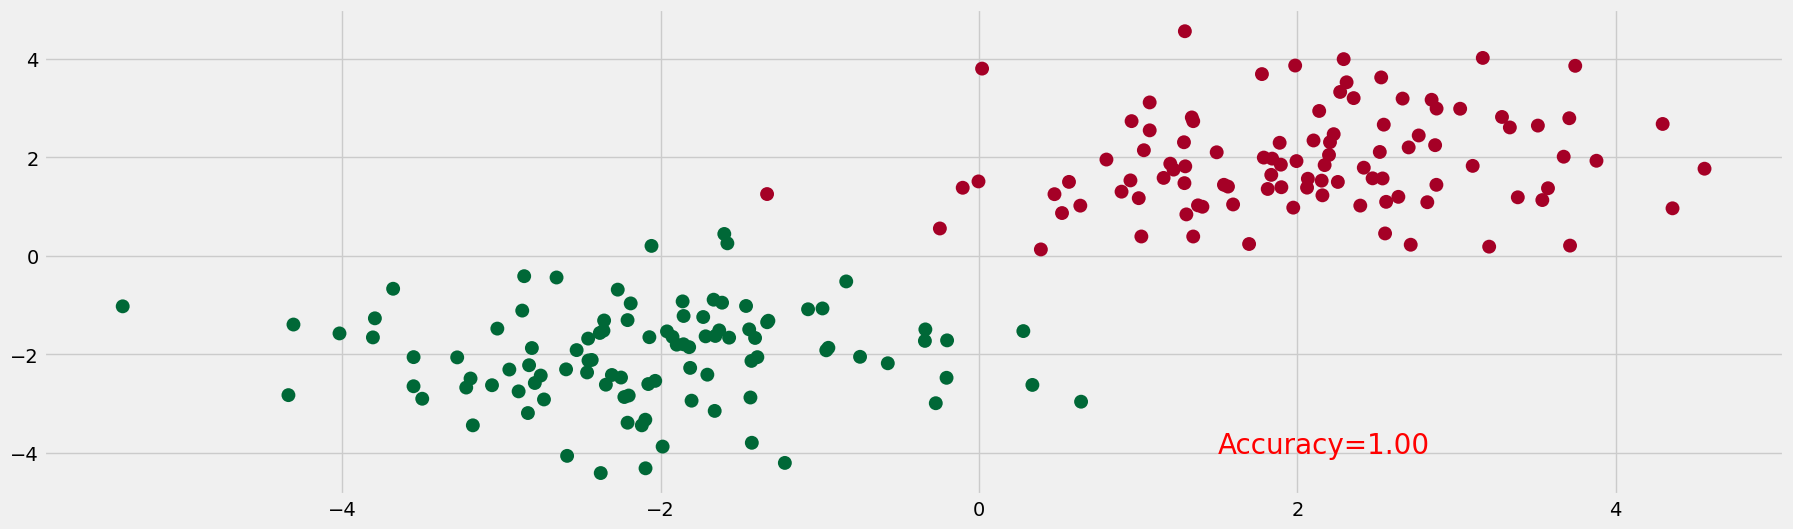

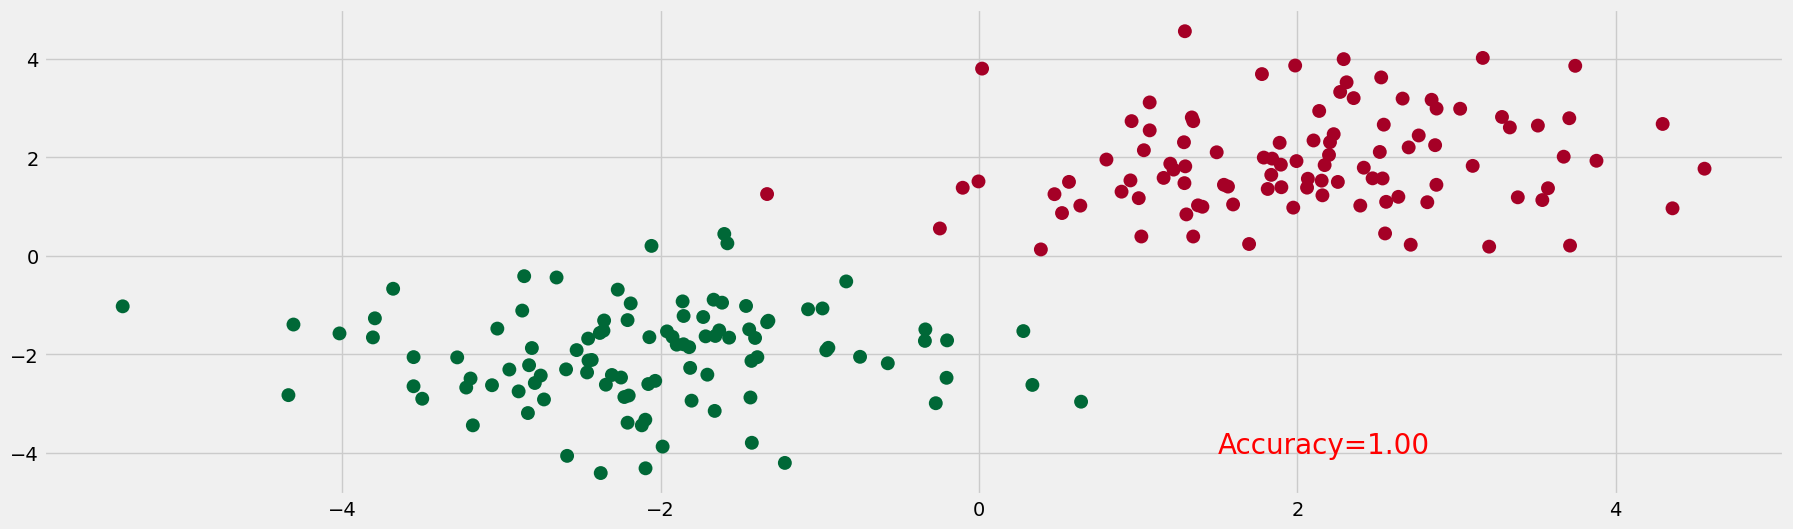

In [47]:
for t in range(100):
    out = net(x)
    loss = loss_func(out, y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if t % 10 == 0 or t in [3, 6]:
        plt.figure(figsize=(20, 6))
        plt.cla()
        _, prediction = torch.max(F.softmax(out, dim=1), 1)
        pred_y = prediction.data.numpy().squeeze()
        target_y = y.data.numpy()
        plt.scatter(x.data.numpy()[:, 0], x.data.numpy()[:, 1],
                    c=pred_y, s=100, lw=0, cmap='RdYlGn')
        accuracy = float((pred_y == target_y).sum()) / 200.
        plt.text(1.5, -4, 'Accuracy=%.2f' % accuracy,
                 fontdict={'size': 20, 'color': 'red'})
        plt.show()

### Easy way to Buid Neural Network
---

**Neural Network** - Neural networks, a beautiful biologically-inspired programming paradigm which enables a computer to learn from observational data.

![](https://www.researchgate.net/profile/Reza_Rezaee8/publication/230905093/figure/fig1/AS:300580867198976@1448675471259/a-Schematic-diagram-of-an-artificial-neural-network-structure-which-consists-of-an.png)

In [48]:
import torch
import torch.nn.functional as F
from torch.autograd import Variable
import matplotlib.pyplot as plt
%matplotlib inline

torch.manual_seed(1)    # reproducible

### Design Model

In [49]:
# replace following class code with an easy sequential network
class Net(torch.nn.Module):
    def __init__(self, n_feature, n_hidden, n_output):
        super(Net, self).__init__()
        self.hidden = torch.nn.Linear(n_feature, n_hidden)   # hidden layer
        self.predict = torch.nn.Linear(n_hidden, n_output)   # output layer

    def forward(self, x):
        x = F.relu(self.hidden(x))      # activation function for hidden layer
        x = self.predict(x)             # linear output
        return x

### Define Model

In [50]:
net1 = Net(1, 10, 1)

# easy and fast way to build your network
net2 = torch.nn.Sequential(
    torch.nn.Linear(1, 10),
    torch.nn.ReLU(),
    torch.nn.Linear(10, 1)
)

In [51]:
print(net1)     # net1 architecture
print(net2)     # net2 architecture

Net(
  (hidden): Linear(in_features=1, out_features=10, bias=True)
  (predict): Linear(in_features=10, out_features=1, bias=True)
)
Sequential(
  (0): Linear(in_features=1, out_features=10, bias=True)
  (1): ReLU()
  (2): Linear(in_features=10, out_features=1, bias=True)
)


## Save and Reload Model
---

### Generate Fake Data

In [52]:
x = torch.unsqueeze(torch.linspace(-1, 1, 100), dim=1)  # x data (tensor), shape=(100, 1)
y = x.pow(2) + 0.2*torch.rand(x.size())  # noisy y data (tensor), shape=(100, 1)
x, y = Variable(x, requires_grad=False), Variable(y, requires_grad=False)

### Model Saving Function in Pickle Format

In [53]:
def save():
    # save net1
    net1 = torch.nn.Sequential(
        torch.nn.Linear(1, 10),
        torch.nn.ReLU(),
        torch.nn.Linear(10, 1)
    )
    optimizer = torch.optim.SGD(net1.parameters(), lr=0.5)
    loss_func = torch.nn.MSELoss()

    for t in range(100):
        prediction = net1(x)
        loss = loss_func(prediction, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # plot result
    plt.figure(1, figsize=(20, 5))
    plt.subplot(131)
    plt.title('Net1')
    plt.scatter(x.data.numpy(), y.data.numpy(), color = "orange")
    plt.plot(x.data.numpy(), prediction.data.numpy(), 'r-', lw=5)

    # 2 ways to save the net
    torch.save(net1, 'net.pkl')  # save entire net
    torch.save(net1.state_dict(), 'net_params.pkl')   # save only the parameters

### Load save model

In [54]:
def restore_net():
    # restore entire net1 to net2
    try:
        net2 = torch.load('net.pkl', weights_only=False)
    except TypeError:
        # older PyTorch where the weights_only kwarg doesn't exist
        net2 = torch.load('net.pkl')
    prediction = net2(x)

    plt.figure(1, figsize=(20, 5))
    plt.subplot(132)
    plt.title('Net2')
    plt.scatter(x.data.numpy(), y.data.numpy(), color="orange")
    plt.plot(x.data.numpy(), prediction.data.numpy(), 'r-', lw=5)

### Parameter Restore for net1 to net3

In [55]:
def restore_params():
    # restore only the parameters in net1 to net3
    net3 = torch.nn.Sequential(
        torch.nn.Linear(1, 10),
        torch.nn.ReLU(),
        torch.nn.Linear(10, 1)
    )

    # copy net1's parameters into net3
    net3.load_state_dict(torch.load('net_params.pkl'))
    prediction = net3(x)

    # plot result
    plt.figure(1, figsize=(20, 5))
    plt.subplot(133)
    plt.title('Net3')
    plt.scatter(x.data.numpy(), y.data.numpy(), color = "orange")
    plt.plot(x.data.numpy(), prediction.data.numpy(), 'r-', lw=5)
    plt.show()

### Plot the Models

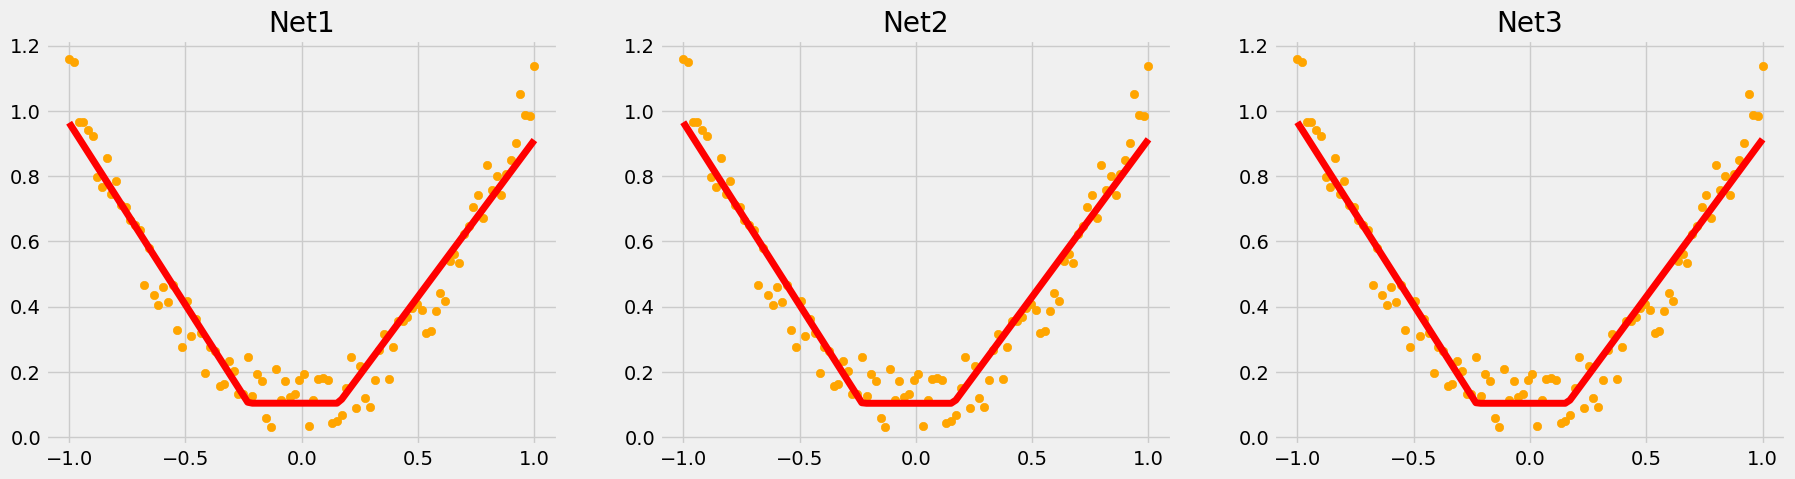

In [56]:
# save net1
save()
# restore entire net (may slow)
restore_net()
# restore only the net parameters
restore_params()

## Train on batch
---
![](https://i0.wp.com/mlexplained.com/wp-content/uploads/2018/02/%E3%82%B9%E3%82%AF%E3%83%AA%E3%83%BC%E3%83%B3%E3%82%B7%E3%83%A7%E3%83%83%E3%83%88-2018-02-07-10.32.59.png?w=1500)

In [57]:
import torch
import torch.utils.data as Data

torch.manual_seed(1)    # reproducible

In [58]:
BATCH_SIZE = 5
# BATCH_SIZE = 8

#### Dataset Preparation

In [59]:
x = torch.linspace(1, 10, 10)       # this is x data (torch tensor)
y = torch.linspace(10, 1, 10)       # this is y data (torch tensor)

### Load dataset

In [60]:
torch_dataset = Data.TensorDataset(x, y)
loader = Data.DataLoader(
    dataset=torch_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,  # portable across Colab/Linux/Windows
)

### Model Treaning

In [61]:
def show_batch():
    for epoch in range(3):   # train entire dataset 3 times
        for step, (batch_x, batch_y) in enumerate(loader):  # for each training step
            # train your data...
            print('Epoch: ', epoch, '| Step: ', step, '| batch x: ',
                  batch_x.numpy(), '| batch y: ', batch_y.numpy())

In [62]:
if __name__ == '__main__':
    show_batch()

Epoch:  0 | Step:  0 | batch x:  [5. 3. 1. 7. 9.] | batch y:  [ 6.  8. 10.  4.  2.]
Epoch:  0 | Step:  1 | batch x:  [ 8. 10.  2.  6.  4.] | batch y:  [3. 1. 9. 5. 7.]
Epoch:  1 | Step:  0 | batch x:  [5. 9. 2. 6. 1.] | batch y:  [ 6.  2.  9.  5. 10.]
Epoch:  1 | Step:  1 | batch x:  [ 3.  4.  7. 10.  8.] | batch y:  [8. 7. 4. 1. 3.]
Epoch:  2 | Step:  0 | batch x:  [6. 9. 4. 8. 7.] | batch y:  [5. 2. 7. 3. 4.]
Epoch:  2 | Step:  1 | batch x:  [10.  3.  2.  1.  5.] | batch y:  [ 1.  8.  9. 10.  6.]


## Optimizers

Nice Article on Optimizer : https://blog.paperspace.com/intro-to-optimization-momentum-rmsprop-adam/

![](https://image.slidesharecdn.com/optimizationtalk-171126132036/95/optimization-for-deep-learning-26-638.jpg?cb=1511702523)

In [63]:
import torch
import torch.utils.data as Data
import torch.nn.functional as F
from torch.autograd import Variable
import matplotlib.pyplot as plt
%matplotlib inline

In [64]:
torch.manual_seed(1)    # reproducible

### Paramater Defined

In [65]:
LR = 0.01
BATCH_SIZE = 32
EPOCH = 12

### Generate Fake Data

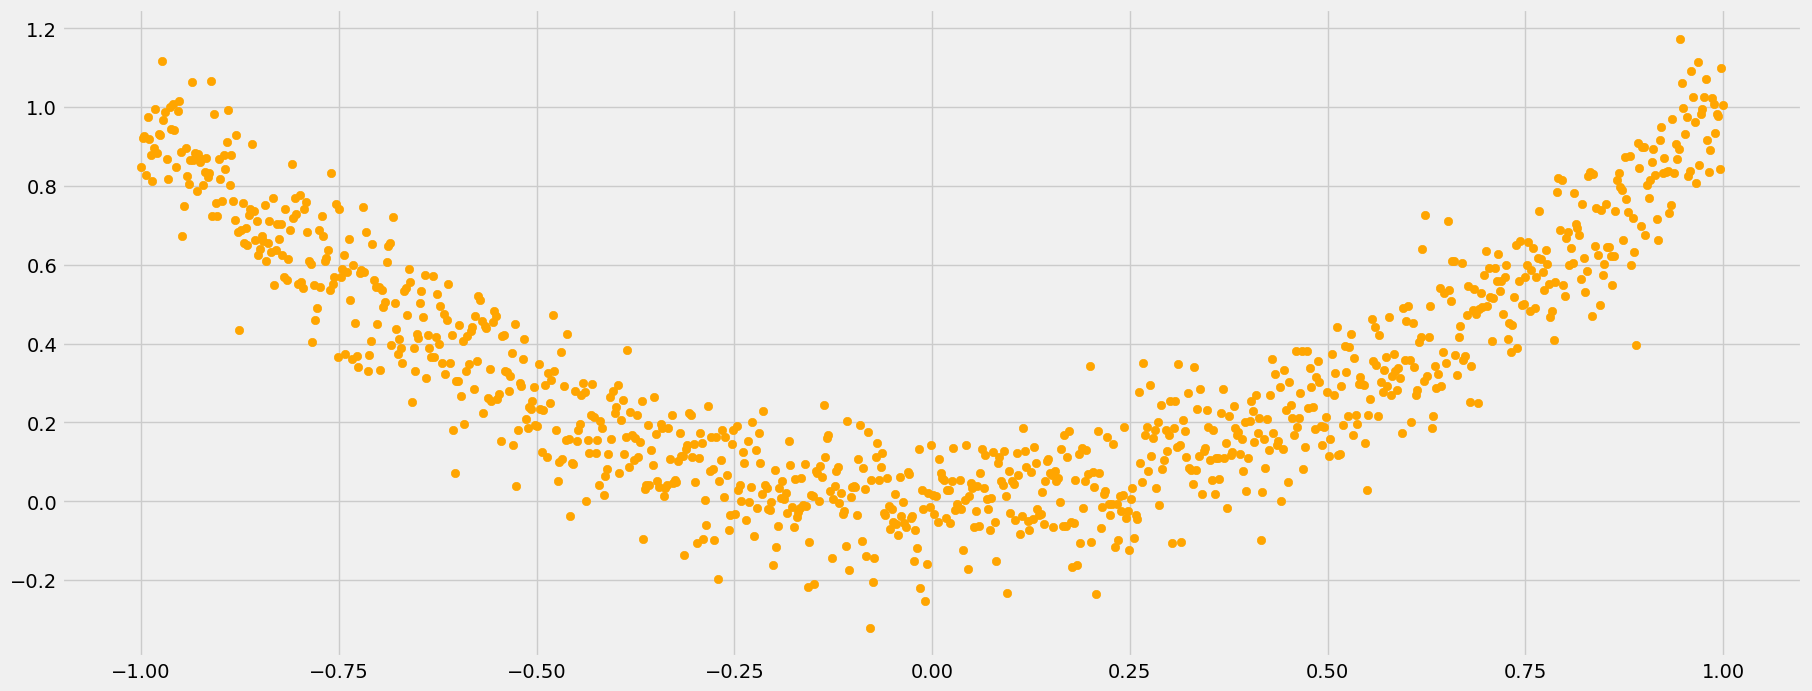

In [66]:
# fake dataset
x = torch.unsqueeze(torch.linspace(-1, 1, 1000), dim=1)
y = x.pow(2) + 0.1*torch.normal(torch.zeros(*x.size()))

# plot dataset
plt.figure(figsize=(20,8))
plt.scatter(x.numpy(), y.numpy(), color = "orange")
plt.show()

### Put Dataset in torch dataset

In [67]:
torch_dataset = Data.TensorDataset(x, y)
loader = Data.DataLoader(
    dataset=torch_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
)

### Default Network

In [68]:
class Net(torch.nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.hidden = torch.nn.Linear(1, 20)   # hidden layer
        self.predict = torch.nn.Linear(20, 1)   # output layer

    def forward(self, x):
        x = F.relu(self.hidden(x))      # activation function for hidden layer
        x = self.predict(x)             # linear output
        return x

### Different Net

In [69]:
net_SGD         = Net()
net_Momentum    = Net()
net_RMSprop     = Net()
net_Adam        = Net()
nets = [net_SGD, net_Momentum, net_RMSprop, net_Adam]

### Different optimizers

In [70]:
opt_SGD         = torch.optim.SGD(net_SGD.parameters(), lr=LR)
opt_Momentum    = torch.optim.SGD(net_Momentum.parameters(), lr=LR, momentum=0.8)
opt_RMSprop     = torch.optim.RMSprop(net_RMSprop.parameters(), lr=LR, alpha=0.9)
opt_Adam        = torch.optim.Adam(net_Adam.parameters(), lr=LR, betas=(0.9, 0.99))
optimizers = [opt_SGD, opt_Momentum, opt_RMSprop, opt_Adam]

In [71]:
loss_func = torch.nn.MSELoss()
losses_his = [[], [], [], []]   # record loss

### Model Training

Epoch: 0
Epoch: 1
Epoch: 2
Epoch: 3
Epoch: 4
Epoch: 5
Epoch: 6
Epoch: 7
Epoch: 8
Epoch: 9
Epoch: 10
Epoch: 11


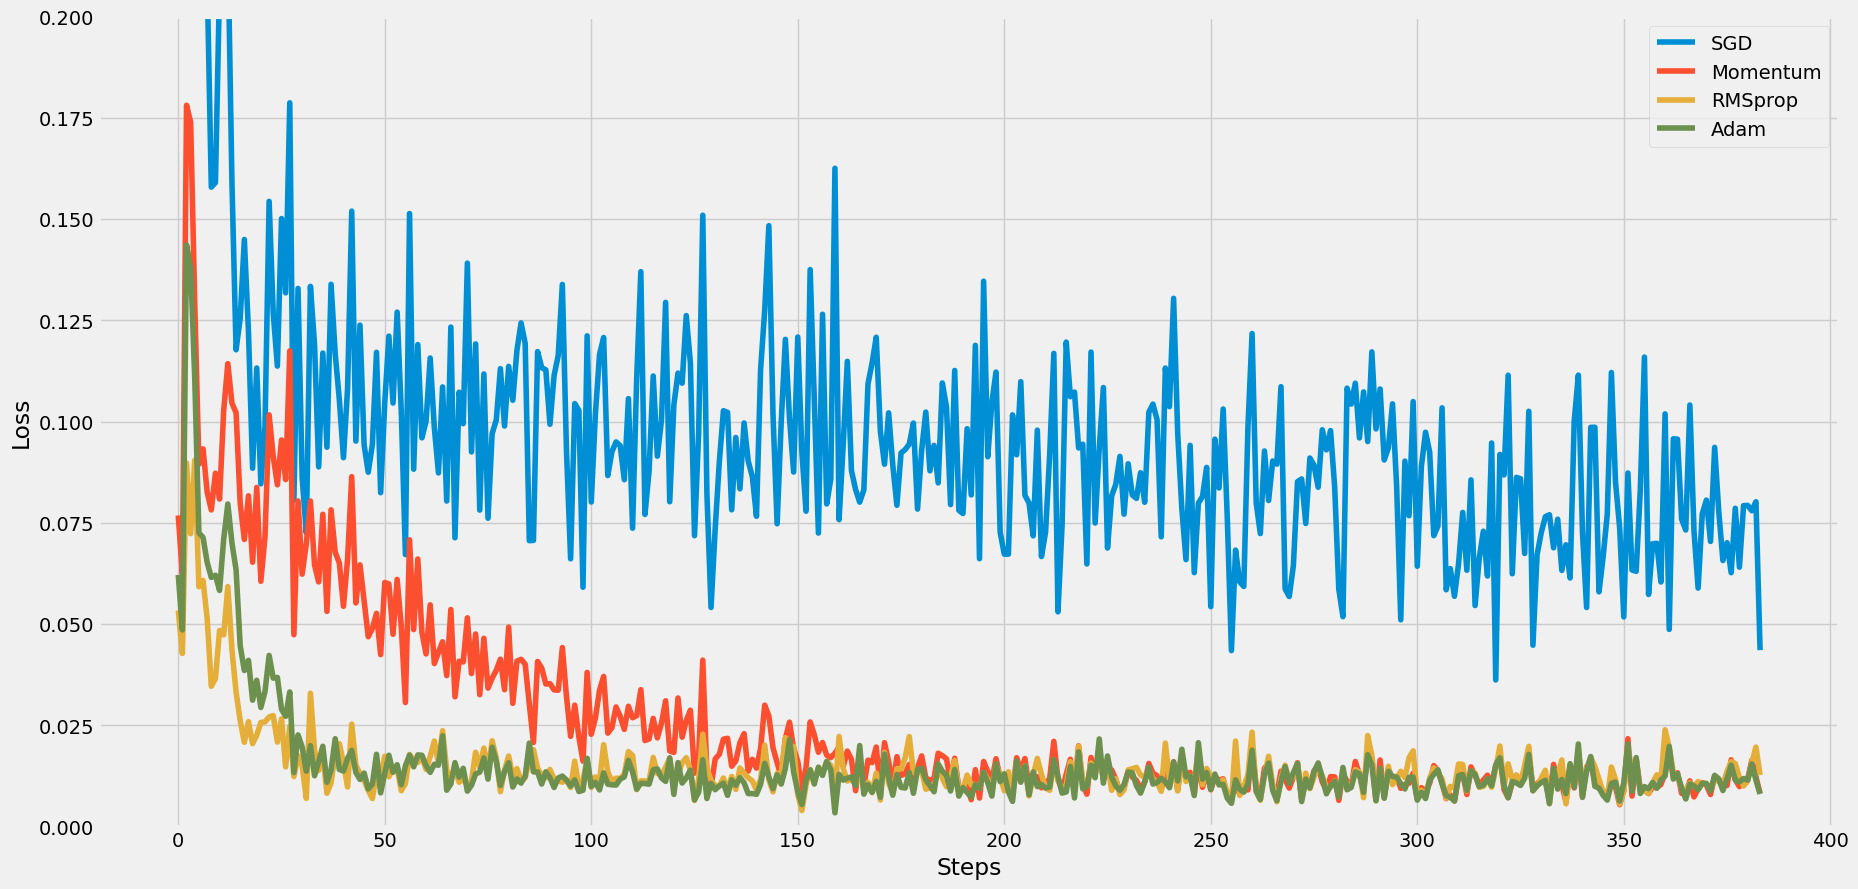

In [72]:
for epoch in range(EPOCH):
    print('Epoch:', epoch)
    for step, (batch_x, batch_y) in enumerate(loader):
        b_x, b_y = batch_x, batch_y

        for net, opt, l_his in zip(nets, optimizers, losses_his):
            output = net(b_x)
            loss = loss_func(output, b_y)
            opt.zero_grad()
            loss.backward()
            opt.step()
            l_his.append(loss.item())

plt.figure(figsize=(20, 10))
labels = ['SGD', 'Momentum', 'RMSprop', 'Adam']
for i, l_his in enumerate(losses_his):
    plt.plot(l_his, label=labels[i])
plt.legend(loc='best')
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.ylim((0, 0.2))
plt.show()

# Section : 3. Advance Neural Network
---

## CNN
Learning Link : http://cs231n.github.io/convolutional-networks/
---

* **Convolutional neural networks** are an *artificial neural network structure that has gradually emerged in recent years.* Because **convolutional neural networks** can give **better prediction results in image and speech recognition, this technology** is also widely used. The most commonly used aspect of convolutional neural networks is **computer image recognition,** but because of constant innovation, it is also **used in video analysis, natural language processing, drug discovery,** etc. The most recent Alpha Go, let the computer see Knowing Go, there is also the use of this technology.

---

![](https://software.intel.com/sites/default/files/managed/20/df/dev-journey-article15-fig11-examples-of-pooling.png)
![](https://www.researchgate.net/profile/Serkan_Kiranyaz/publication/313676923/figure/fig2/AS:461584393871361@1487061703456/A-standard-2D-CNN-10.png)

---

* Let's take a look at the word convolutional neural network. **"Convolution" and "neural network".**
* ***Convolution*** means that **the neural network is no longer processing the input information of each pixel, but every picture. A small block of pixels is processed, which enhances the continuity of the picture information. It allows the neural network to see the picture instead of a point. This also deepens the understanding of the picture by the neural network. **
* Specifically, *The convolutional neural network has a **batch filter** that continuously scrolls the information in the image on the image. **Each time it collects, it only collects a small pixel area, and then sorts the collected information. The information has some actual representations.***
* **For example,** the neural network can see some edge image information, and then in the same step, use a similar batch filter to scan the generated edge information, the neural network from these The edge information summarizes the higher-level information structure. For example, **the edge of the summary can draw eyes, nose, etc.** After a filter, the face information is also from this. Information nose eyes are summed up. The last information we then set into the general picture of several layers fully connected neural layer classification, so that we can get input can be divided into what type of result.

### Convolution
![](https://morvanzhou.github.io/static/results/ML-intro/cnn4.png)
![](https://thigiacmaytinh.com/wp-content/uploads/2018/05/kernel.png)

### Pooling
![](https://morvanzhou.github.io/static/results/ML-intro/cnn5.png)
* The study found that at each convolution, the neural layer may inadvertently lose some information. At this time, pooling can solve this problem well. And pooling is a process of filtering and filtering. Filter the useful information in the layer and analyze it for the next layer. It also reduces the computational burden of the neural network. That is to say, in the volume set, we do not compress the length and width, try to retain more Information, compression work is handed over to the pool, such an additional work can be very effective to improve accuracy. With these technologies, we can build a convolutional neural network of our own.

### Popular CNN Structure
![](https://morvanzhou.github.io/static/results/ML-intro/cnn6.png)
* A popular construction structure is this. From bottom to top, the first is the input image, after a convolution, and then the convolution information is processed in a pooling manner. Here, the max pooling method is used. Then, after the same processing, the obtained second processed information is transmitted to the two layers of fully connected neural layers, which is also a general two-layer neural network layer. Finally, it is connected to a classifier for classification prediction.

In [73]:
import torch
import torch.nn as nn
from torch.autograd import Variable
import torch.utils.data as Data
import torchvision
import matplotlib.pyplot as plt
%matplotlib inline

In [74]:
torch.manual_seed(1)    # reproducible

### Hyper Parameters

In [75]:
# Hyper Parameters
EPOCH = 1               # train the training data n times, to save time, we just train 1 epoch
BATCH_SIZE = 50
LR = 0.001              # learning rate
DOWNLOAD_MNIST = True   # download MNIST if not present

### Dataset Reading

In [76]:
# MNIST digits dataset
train_data = torchvision.datasets.MNIST(
    root='./mnist/',
    train=True,
    transform=torchvision.transforms.ToTensor(),
    download=DOWNLOAD_MNIST,
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 38.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.21MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.8MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.85MB/s]


### Show data

torch.Size([60000, 28, 28])
torch.Size([60000])


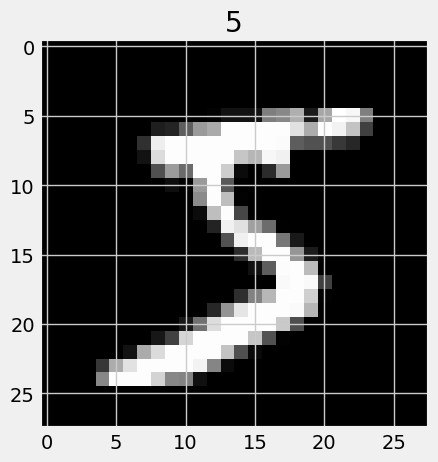

In [77]:
# plot one example
print(train_data.data.size())     # torch.Size([60000, 28, 28])
print(train_data.targets.size())  # torch.Size([60000])
plt.imshow(train_data.data[0].numpy(), cmap='gray')
plt.title('%i' % train_data.targets[0].item())
plt.show()

### Data Convert into Variable

In [78]:
# Data Loader for easy mini-batch return in training, the image batch shape will be (50, 1, 28, 28)
train_loader = Data.DataLoader(dataset=train_data, batch_size=BATCH_SIZE, shuffle=True)

In [79]:
# Test data (no transform needed; we manually scale to [0,1])
test_data = torchvision.datasets.MNIST(root='./mnist/', train=False, download=DOWNLOAD_MNIST)
test_x = torch.unsqueeze(test_data.data, dim=1).type(torch.FloatTensor)[:2000] / 255.
test_y = test_data.targets[:2000]

### Model Design

In [80]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Sequential(         # input shape (1, 28, 28)
            nn.Conv2d(
                in_channels=1,              # input height
                out_channels=16,            # n_filters
                kernel_size=5,              # filter size
                stride=1,                   # filter movement/step
                padding=2,                  # if want same width and length of this image after con2d, padding=(kernel_size-1)/2 if stride=1
            ),                              # output shape (16, 28, 28)
            nn.ReLU(),                      # activation
            nn.MaxPool2d(kernel_size=2),    # choose max value in 2x2 area, output shape (16, 14, 14)
        )
        self.conv2 = nn.Sequential(         # input shape (1, 28, 28)
            nn.Conv2d(16, 32, 5, 1, 2),     # output shape (32, 14, 14)
            nn.ReLU(),                      # activation
            nn.MaxPool2d(2),                # output shape (32, 7, 7)
        )
        self.out = nn.Linear(32 * 7 * 7, 10)   # fully connected layer, output 10 classes

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = x.view(x.size(0), -1)           # flatten the output of conv2 to (batch_size, 32 * 7 * 7)
        output = self.out(x)
        return output, x    # return x for visualization

In [81]:
cnn = CNN()
print(cnn)  # net architecture

CNN(
  (conv1): Sequential(
    (0): Conv2d(1, 16, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (out): Linear(in_features=1568, out_features=10, bias=True)
)


In [82]:
optimizer = torch.optim.Adam(cnn.parameters(), lr=LR)   # optimize all cnn parameters
loss_func = nn.CrossEntropyLoss()                       # the target label is not one-hotted

### Resulting Graphs

Epoch: 0 | train loss: 2.3034 | test accuracy: 0.12


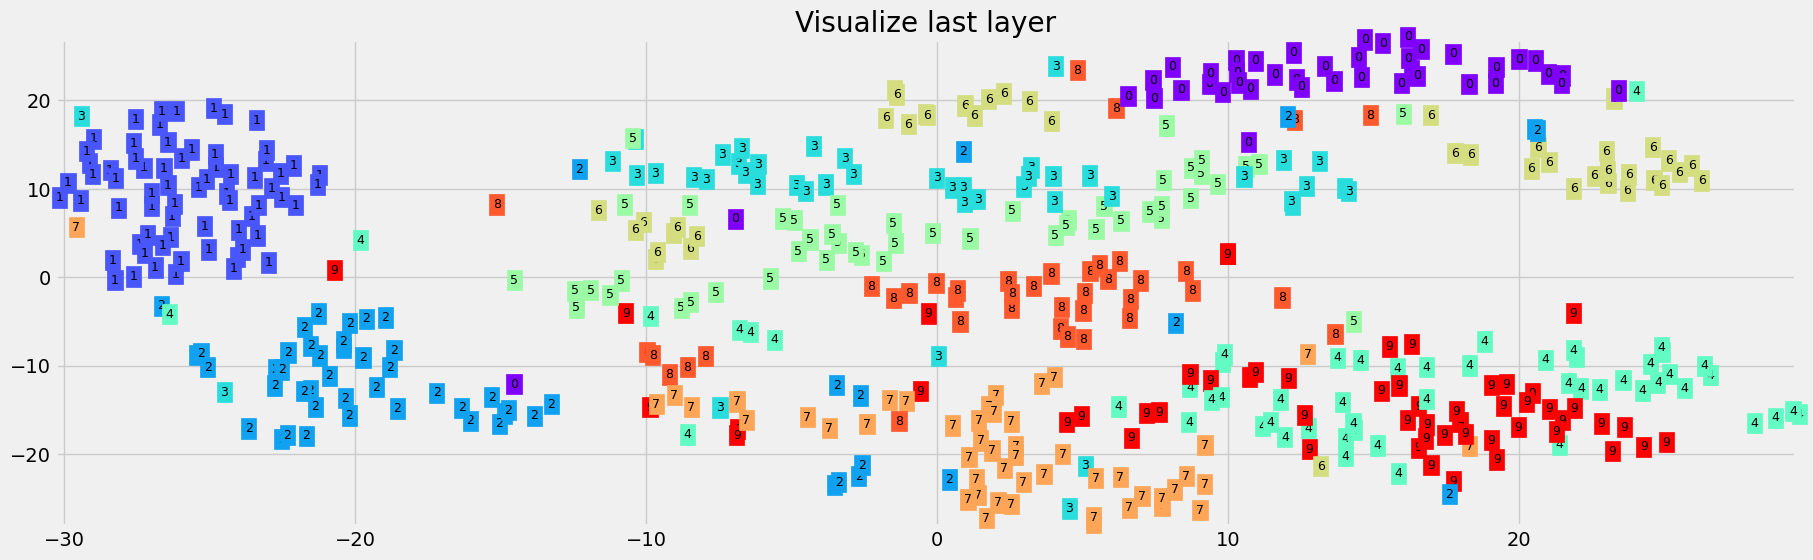

Epoch: 0 | train loss: 0.5555 | test accuracy: 0.87


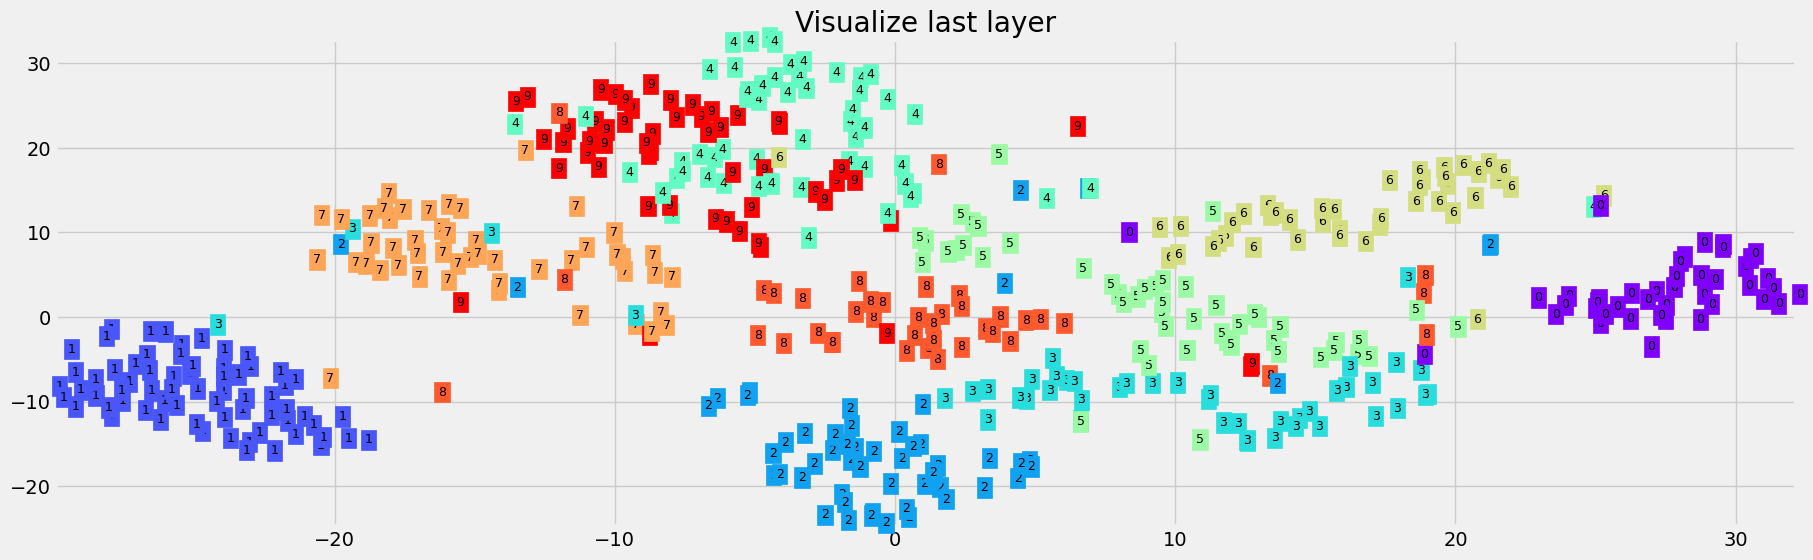

Epoch: 0 | train loss: 0.1279 | test accuracy: 0.94


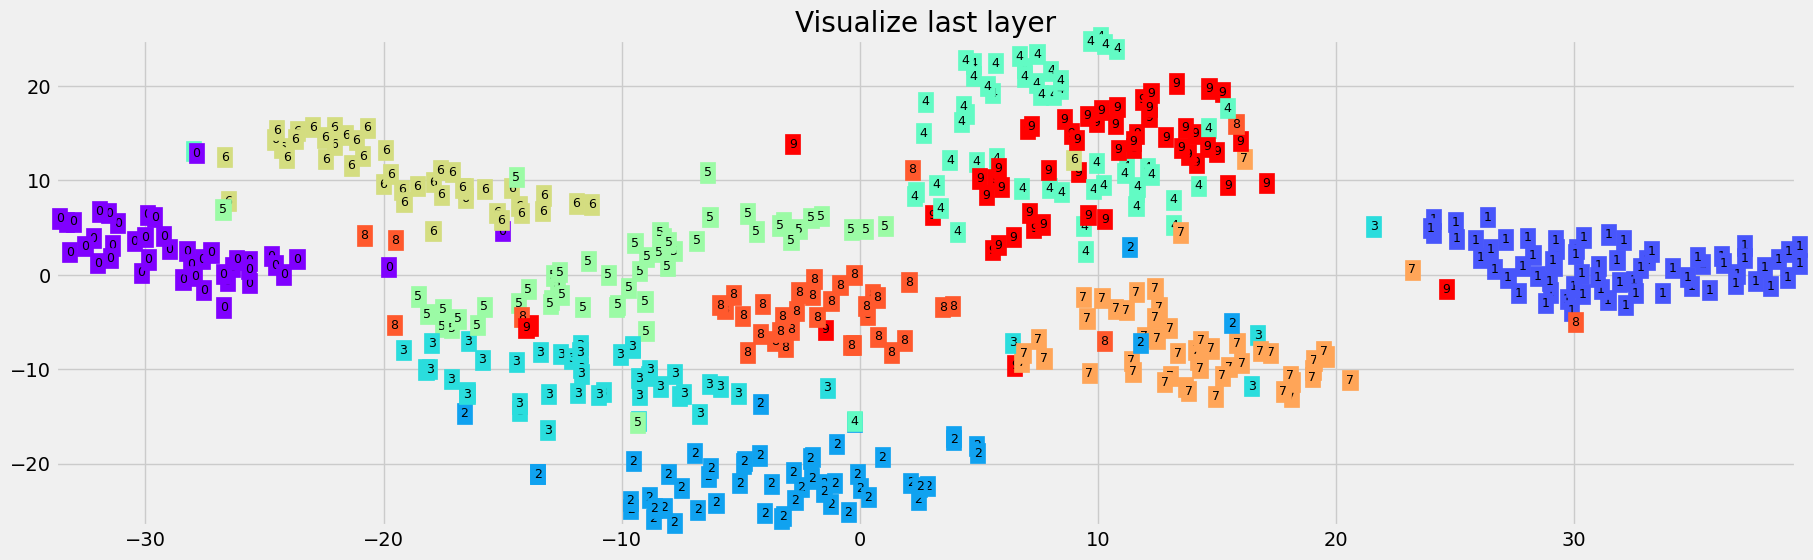

Epoch: 0 | train loss: 0.0556 | test accuracy: 0.95


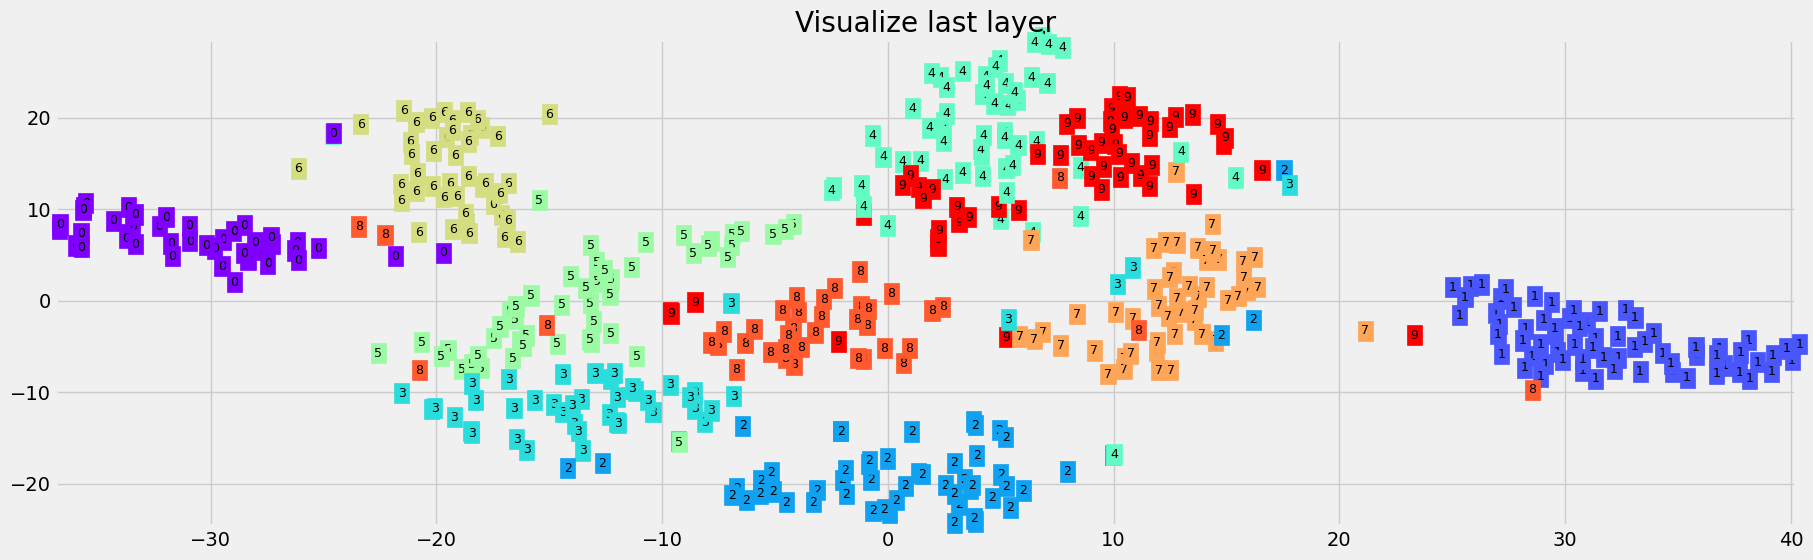

Epoch: 0 | train loss: 0.0354 | test accuracy: 0.96


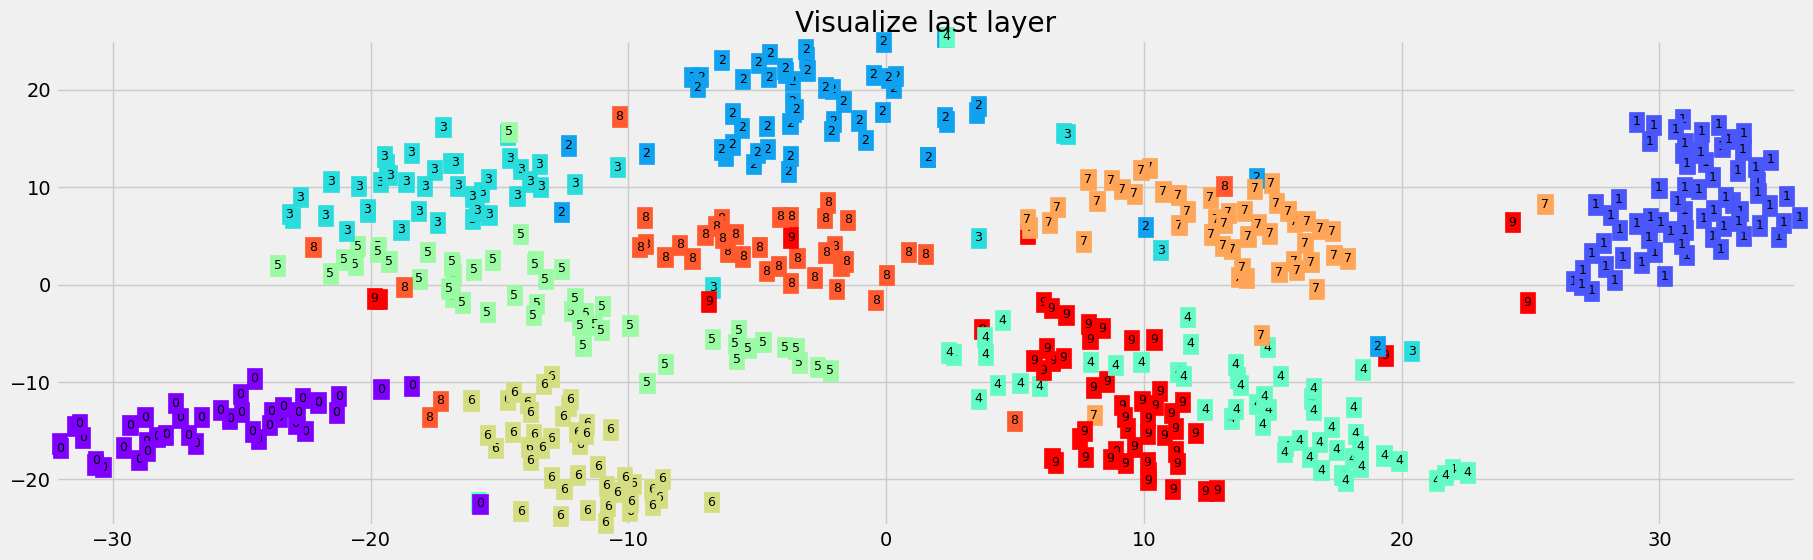

Epoch: 0 | train loss: 0.1842 | test accuracy: 0.96


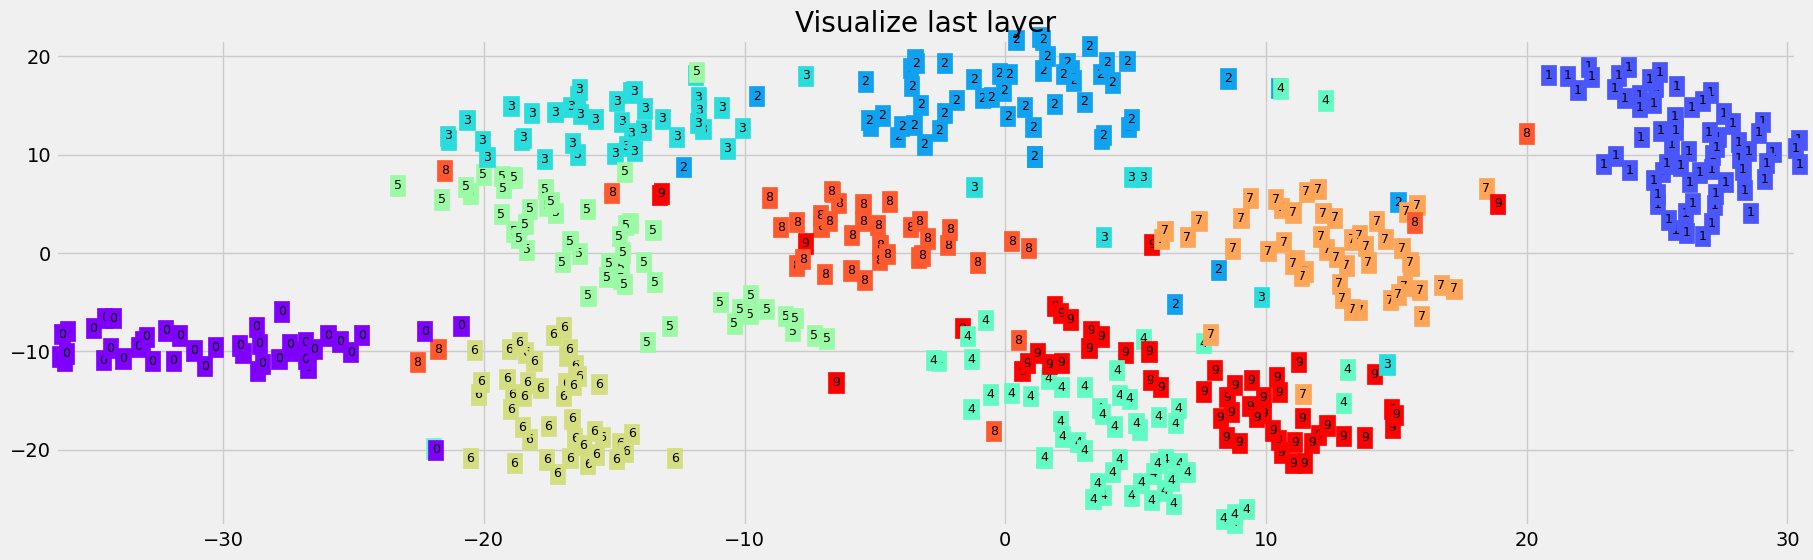

Epoch: 0 | train loss: 0.0190 | test accuracy: 0.97


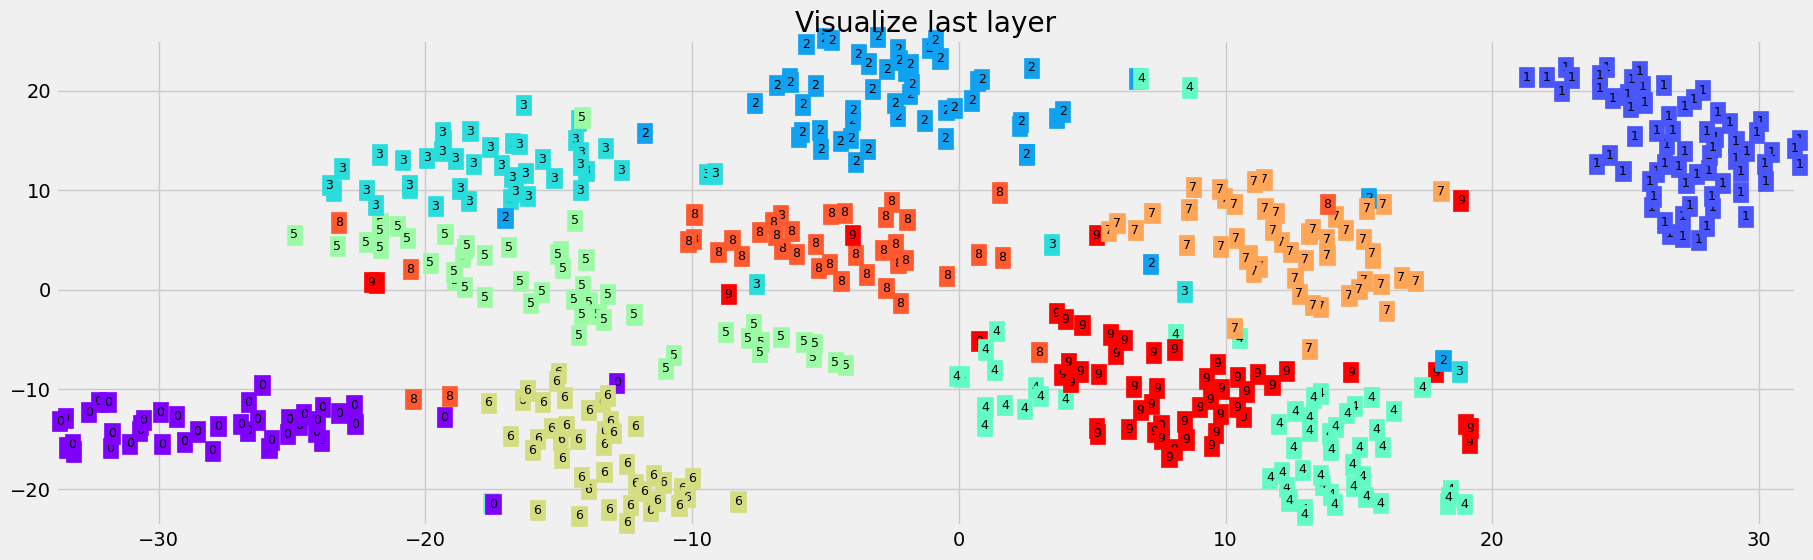

Epoch: 0 | train loss: 0.0948 | test accuracy: 0.97


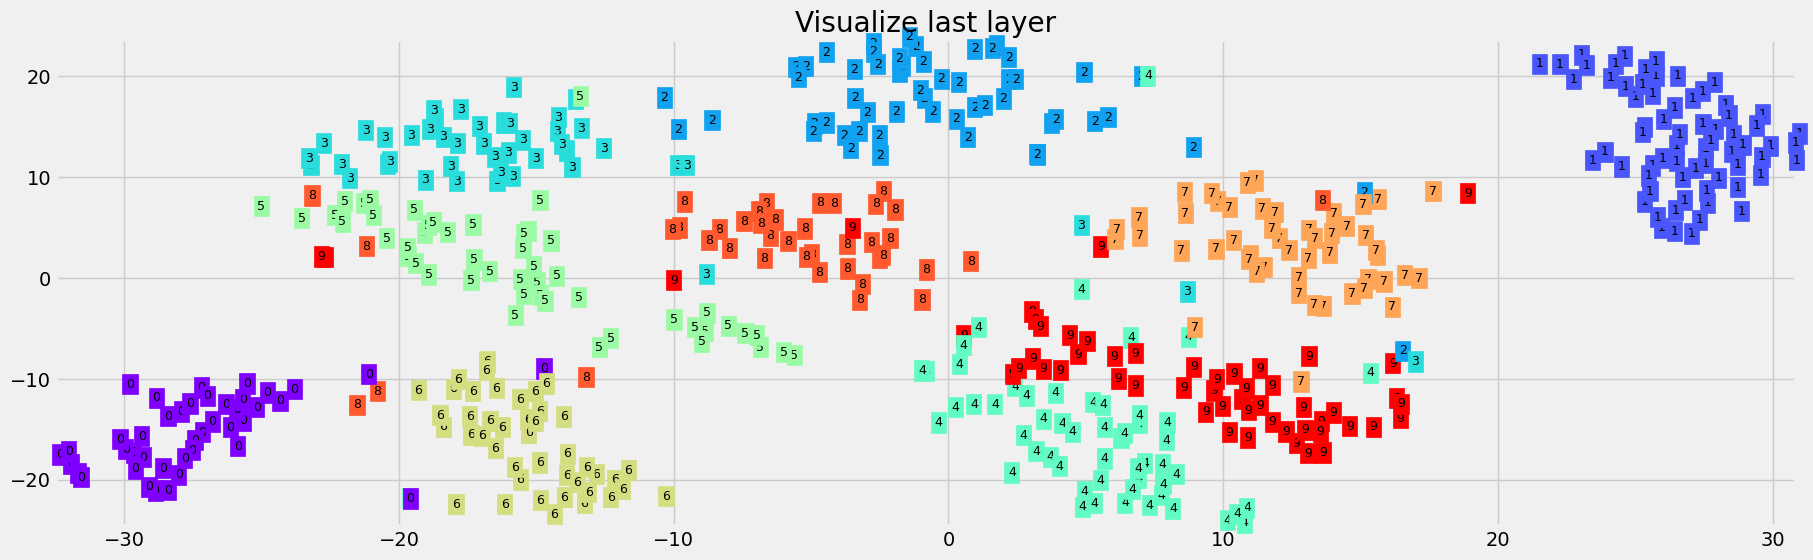

Epoch: 0 | train loss: 0.0386 | test accuracy: 0.96


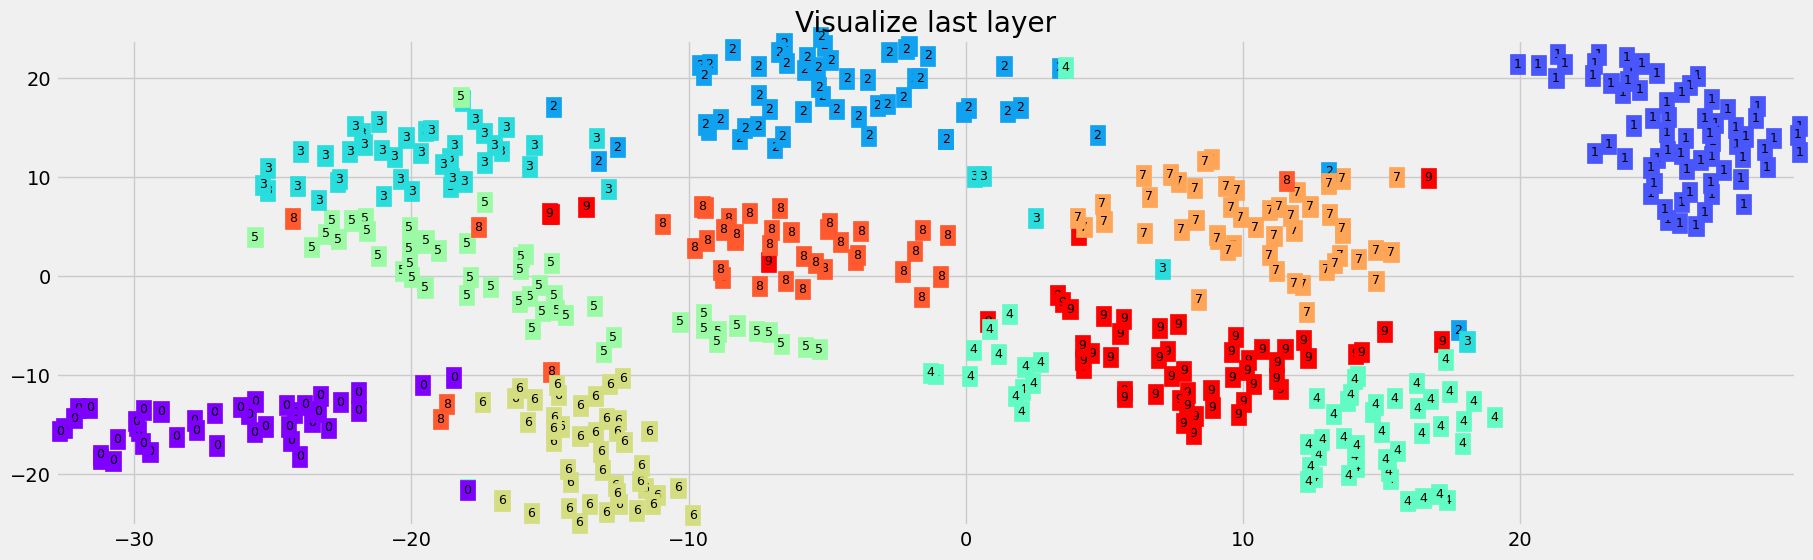

Epoch: 0 | train loss: 0.0984 | test accuracy: 0.98


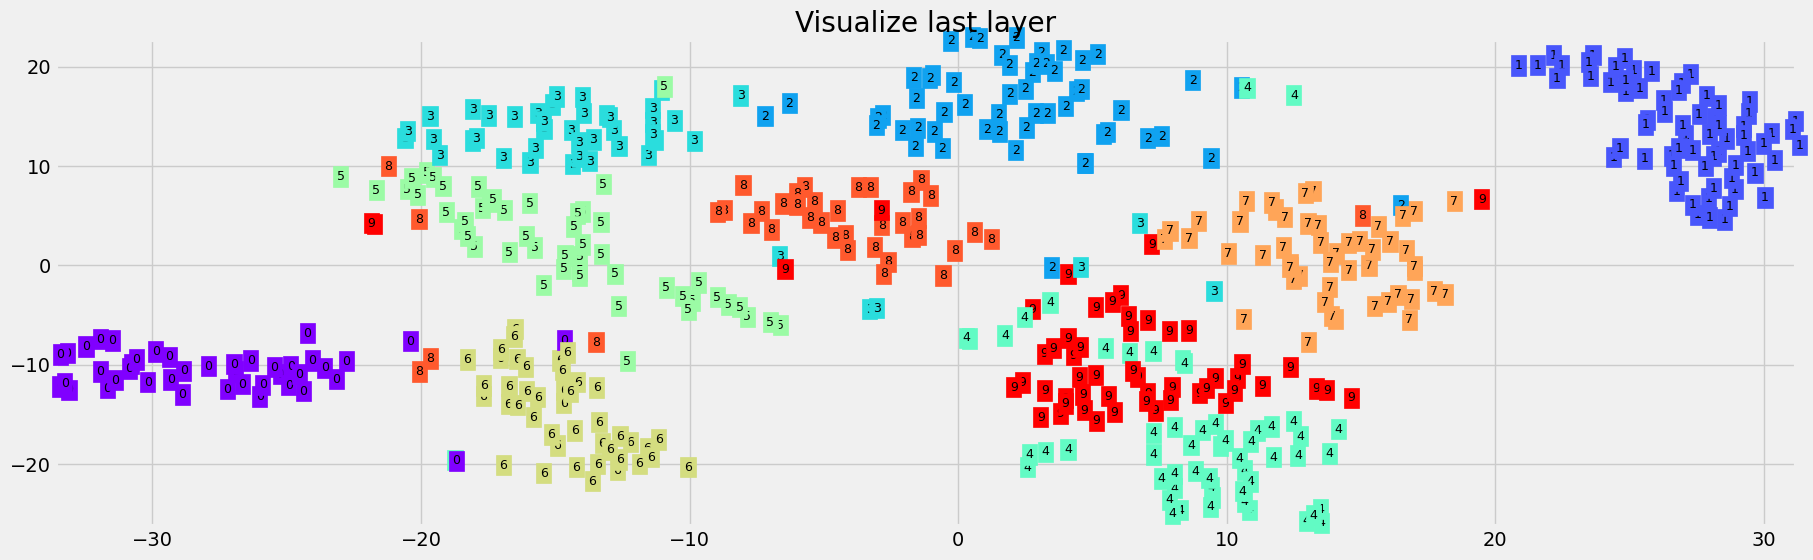

Epoch: 0 | train loss: 0.1954 | test accuracy: 0.98


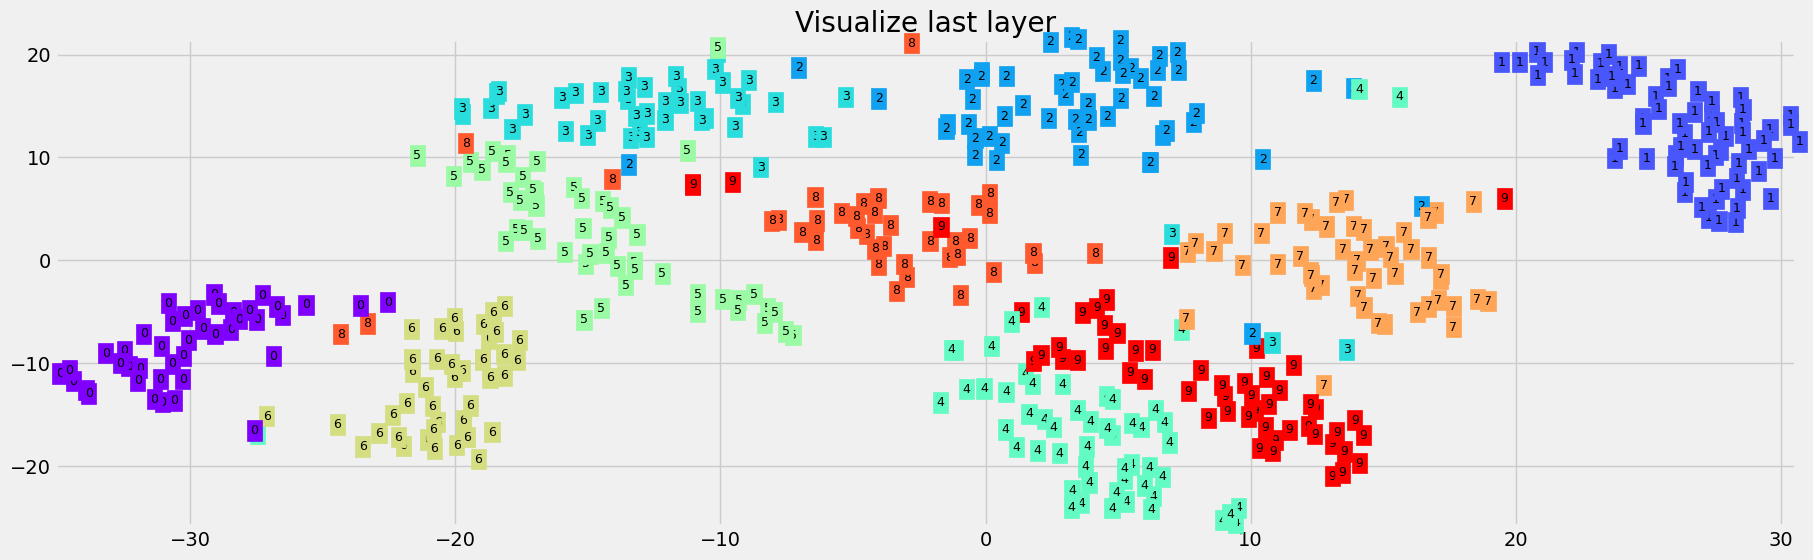

Epoch: 0 | train loss: 0.0208 | test accuracy: 0.98


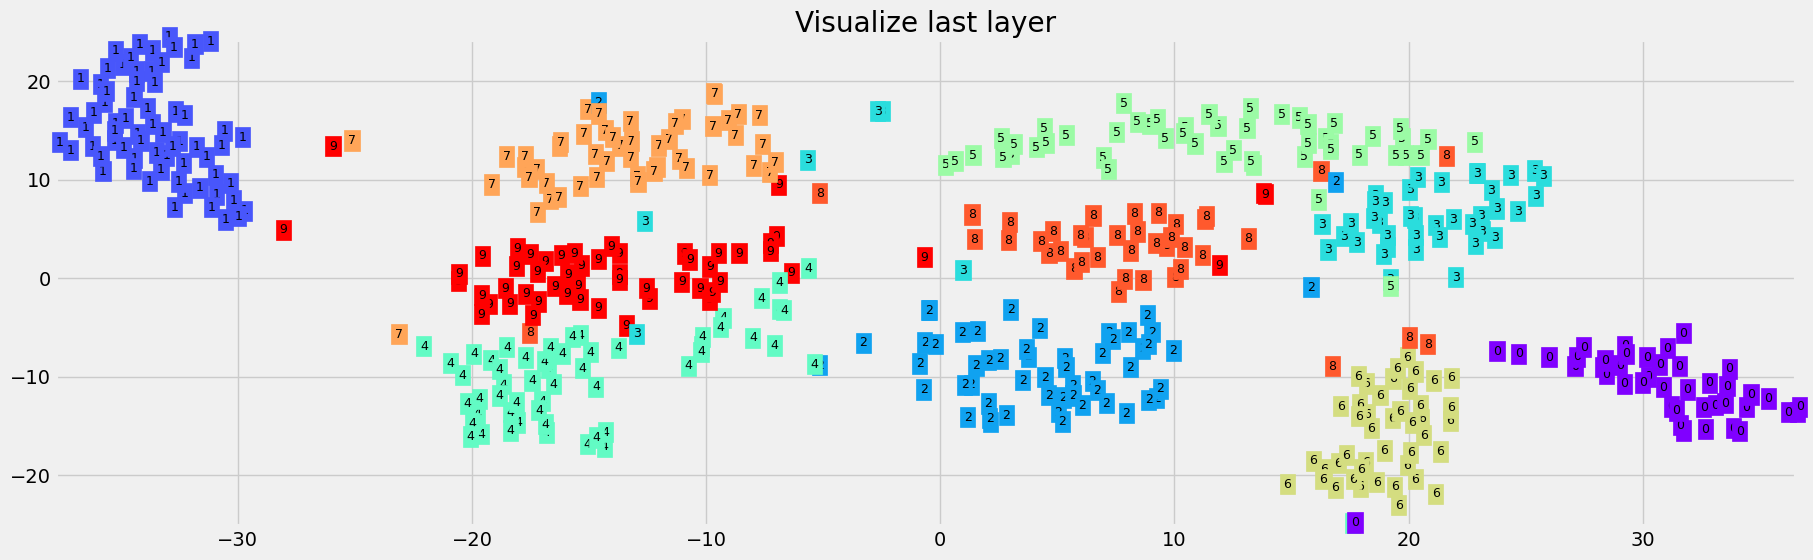

In [83]:
# Visualization helper (skipped if scikit-learn isn't installed)
from matplotlib import cm
try:
    from sklearn.manifold import TSNE
    HAS_SK = True
except ImportError:
    HAS_SK = False
    print('Please install scikit-learn for layer visualization.')

def plot_with_labels(lowDWeights, labels):
    plt.figure(figsize=(20, 6))
    plt.cla()
    X, Y = lowDWeights[:, 0], lowDWeights[:, 1]
    for x_, y_, s in zip(X, Y, labels):
        c = cm.rainbow(int(255 * int(s) / 9))
        plt.text(x_, y_, str(int(s)), backgroundcolor=c, fontsize=9)
    plt.xlim(X.min(), X.max())
    plt.ylim(Y.min(), Y.max())
    plt.title('Visualize last layer')
    plt.show()

# Training and testing
for epoch in range(EPOCH):
    for step, (b_x, b_y) in enumerate(train_loader):
        output = cnn(b_x)[0]
        loss = loss_func(output, b_y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if step % 100 == 0:
            with torch.no_grad():
                test_output, last_layer = cnn(test_x)
            pred_y = torch.max(test_output, 1)[1].data.squeeze()
            accuracy = (pred_y == test_y).sum().item() / float(test_y.size(0))
            print('Epoch:', epoch,
                  '| train loss: %.4f' % loss.item(),
                  '| test accuracy: %.2f' % accuracy)
            if HAS_SK:
                # sklearn renamed n_iter -> max_iter in 1.5
                try:
                    tsne = TSNE(perplexity=30, n_components=2,
                                init='pca', max_iter=5000)
                except TypeError:
                    tsne = TSNE(perplexity=30, n_components=2,
                                init='pca', n_iter=5000)
                plot_only = 500
                low_dim_embs = tsne.fit_transform(last_layer.data.numpy()[:plot_only, :])
                labels = test_y.numpy()[:plot_only]
                plot_with_labels(low_dim_embs, labels)

In [84]:
# print 10 predictions from test data
test_output, _ = cnn(test_x[:10])
pred_y = torch.max(test_output, 1)[1].data.numpy().squeeze()
print(pred_y, 'prediction number')
print(test_y[:10].numpy(), 'real number')

[7 2 1 0 4 1 4 9 5 9] prediction number
[7 2 1 0 4 1 4 9 5 9] real number


 ## RNN-Classification
 ---

![](https://i.stack.imgur.com/WSOie.png)

### Sequence Modeling

![](https://morvanzhou.github.io/static/results/ML-intro/rnn2.png)
* We imagine that there is now a set of sequence data **data 0,1,2,3.** When **predicting result0**, we are based on **data0, and when predicting other data,** we are only based on a single data. The neural networks are all the same NN. However, the data is in an ascending order, just like cooking in the kitchen. Sauce A is placed earlier than Sauce B, otherwise it will be scented. So the ordinary neural network structure can not let NN understands the association between these data.

### Neural network for processing sequence

![](https://morvanzhou.github.io/static/results/ML-intro/rnn3.png)

* So how do we let the association between data be analyzed by NN? Think about how humans analyze the ***relationship between things.*** The most basic way is to remember *what happened before.* Then we let the neural network also have this. ***The ability to remember what happened before***.
* When analyzing **Data0, we store the analysis results in memory. Then when analyzing data1, NN will generate new memories, but new memories and old memories are unrelated. Simply call the old memory and analyze it together. If you continue to analyze more ordered data, RNN will accumulate the previous memories and analyze them together.**

![](https://morvanzhou.github.io/static/results/ML-intro/rnn4.png)

* Let's repeat the process just now, but this time to add some mathematical aspects. Every time RNN is done, it will produce a description of the **current state**. We replace it with a **shorthand S(t), then the RNN starts Analyze x(t+1), which produces s(t+1) from x(t+1), but y(t+1) is created by s(t) and s(t+1)** So the RNN we usually see can also be expressed like this.

### Application of RNN

* The form of RNN is not limited to this. His structure is very free. If it is used for classification problems, for example, **if a person says a sentence, the emotional color of this sentence is positive or negative. Then we will You can use the RNN that outputs the judgment result only at the last time.**
* Or this is the picture description RNN, we only need an X to replace the input picture, and then generate a paragraph describing the picture.
* Or the **RNN of the language translation, give a paragraph of English, and then translate it into Any Langauge.**
* With these different forms of RNN, RNN becomes powerful. There are many interesting RNN applications. **For example, let RNN describe the photo. Let RNN write the academic paper, let RNN write the program script, let RNN compose. We The average person can't even tell if this is written by the machine.**

In [85]:
import torch
from torch import nn
from torch.autograd import Variable
import torchvision.datasets as dsets
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
%matplotlib inline

torch.manual_seed(1)    # reproducible

### Hyper Parameters

In [86]:
EPOCH = 1               # train the training data n times, to save time, we just train 1 epoch
BATCH_SIZE = 64
TIME_STEP = 28          # rnn time step / image height
INPUT_SIZE = 28         # rnn input size / image width
LR = 0.01               # learning rate
DOWNLOAD_MNIST = True   # set to True if haven't download the data

In [87]:
# MNIST digits dataset
train_data = dsets.MNIST(
    root='./mnist/',
    train=True,
    transform=transforms.ToTensor(),
    download=DOWNLOAD_MNIST,
)

torch.Size([60000, 28, 28])
torch.Size([60000])


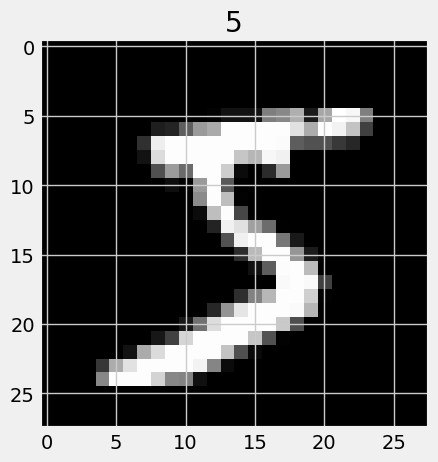

In [88]:
print(train_data.data.size())
print(train_data.targets.size())
plt.imshow(train_data.data[0].numpy(), cmap='gray')
plt.title('%i' % train_data.targets[0].item())
plt.show()

### Data Loader for easy mini-batch return in training

In [89]:
train_loader = torch.utils.data.DataLoader(dataset=train_data, batch_size=BATCH_SIZE, shuffle=True)

### Convert test data into Variable, pick 2000 samples to speed up testing

In [90]:
test_data = dsets.MNIST(root='./mnist/', train=False,
                       transform=transforms.ToTensor(),
                       download=DOWNLOAD_MNIST)
with torch.no_grad():
    test_x = test_data.data.type(torch.FloatTensor)[:2000] / 255.   # (2000, 28, 28)
test_y = test_data.targets.numpy().squeeze()[:2000]

### Model Design

In [91]:
class RNN(nn.Module):
    def __init__(self):
        super(RNN, self).__init__()

        self.rnn = nn.LSTM(         # if use nn.RNN(), it hardly learns
            input_size=INPUT_SIZE,
            hidden_size=64,         # rnn hidden unit
            num_layers=1,           # number of rnn layer
            batch_first=True,       # input & output will has batch size as 1s dimension. e.g. (batch, time_step, input_size)
        )

        self.out = nn.Linear(64, 10)

    def forward(self, x):
        # x shape (batch, time_step, input_size)
        # r_out shape (batch, time_step, output_size)
        # h_n shape (n_layers, batch, hidden_size)
        # h_c shape (n_layers, batch, hidden_size)
        r_out, (h_n, h_c) = self.rnn(x, None)   # None represents zero initial hidden state

        # choose r_out at the last time step
        out = self.out(r_out[:, -1, :])
        return out

In [92]:
rnn = RNN()
print(rnn)

RNN(
  (rnn): LSTM(28, 64, batch_first=True)
  (out): Linear(in_features=64, out_features=10, bias=True)
)


In [93]:
optimizer = torch.optim.Adam(rnn.parameters(), lr=LR)   # optimize all cnn parameters
loss_func = nn.CrossEntropyLoss()

### Training and Testing

In [94]:
for epoch in range(EPOCH):
    for step, (x, y) in enumerate(train_loader):
        b_x = x.view(-1, 28, 28)
        b_y = y

        output = rnn(b_x)
        loss = loss_func(output, b_y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if step % 50 == 0:
            with torch.no_grad():
                test_output = rnn(test_x)
            pred_y = torch.max(test_output, 1)[1].data.numpy().squeeze()
            accuracy = float((pred_y == test_y).sum()) / len(test_y)
            print('Epoch:', epoch,
                  '| train loss: %.4f' % loss.item(),
                  '| test accuracy: %.2f' % accuracy)

Epoch: 0 | train loss: 2.3088 | test accuracy: 0.09
Epoch: 0 | train loss: 1.3066 | test accuracy: 0.59
Epoch: 0 | train loss: 0.8336 | test accuracy: 0.73
Epoch: 0 | train loss: 0.4729 | test accuracy: 0.80
Epoch: 0 | train loss: 0.2486 | test accuracy: 0.88
Epoch: 0 | train loss: 0.2382 | test accuracy: 0.89
Epoch: 0 | train loss: 0.3942 | test accuracy: 0.90
Epoch: 0 | train loss: 0.2191 | test accuracy: 0.92
Epoch: 0 | train loss: 0.1730 | test accuracy: 0.93
Epoch: 0 | train loss: 0.0562 | test accuracy: 0.94
Epoch: 0 | train loss: 0.0917 | test accuracy: 0.91
Epoch: 0 | train loss: 0.1536 | test accuracy: 0.93
Epoch: 0 | train loss: 0.1744 | test accuracy: 0.94
Epoch: 0 | train loss: 0.1434 | test accuracy: 0.94
Epoch: 0 | train loss: 0.0412 | test accuracy: 0.95
Epoch: 0 | train loss: 0.2385 | test accuracy: 0.95
Epoch: 0 | train loss: 0.1301 | test accuracy: 0.95
Epoch: 0 | train loss: 0.2713 | test accuracy: 0.95
Epoch: 0 | train loss: 0.1982 | test accuracy: 0.95


### Predicted and Actual Value match

In [95]:
with torch.no_grad():
    test_output = rnn(test_x[:20].view(-1, 28, 28))
pred_y = torch.max(test_output, 1)[1].data.numpy().squeeze()
print(pred_y, 'prediction number')
print(test_y[:20], 'real number')

[7 2 1 0 4 1 4 4 5 9 0 6 9 0 1 5 9 7 3 4] prediction number
[7 2 1 0 4 1 4 9 5 9 0 6 9 0 1 5 9 7 3 4] real number


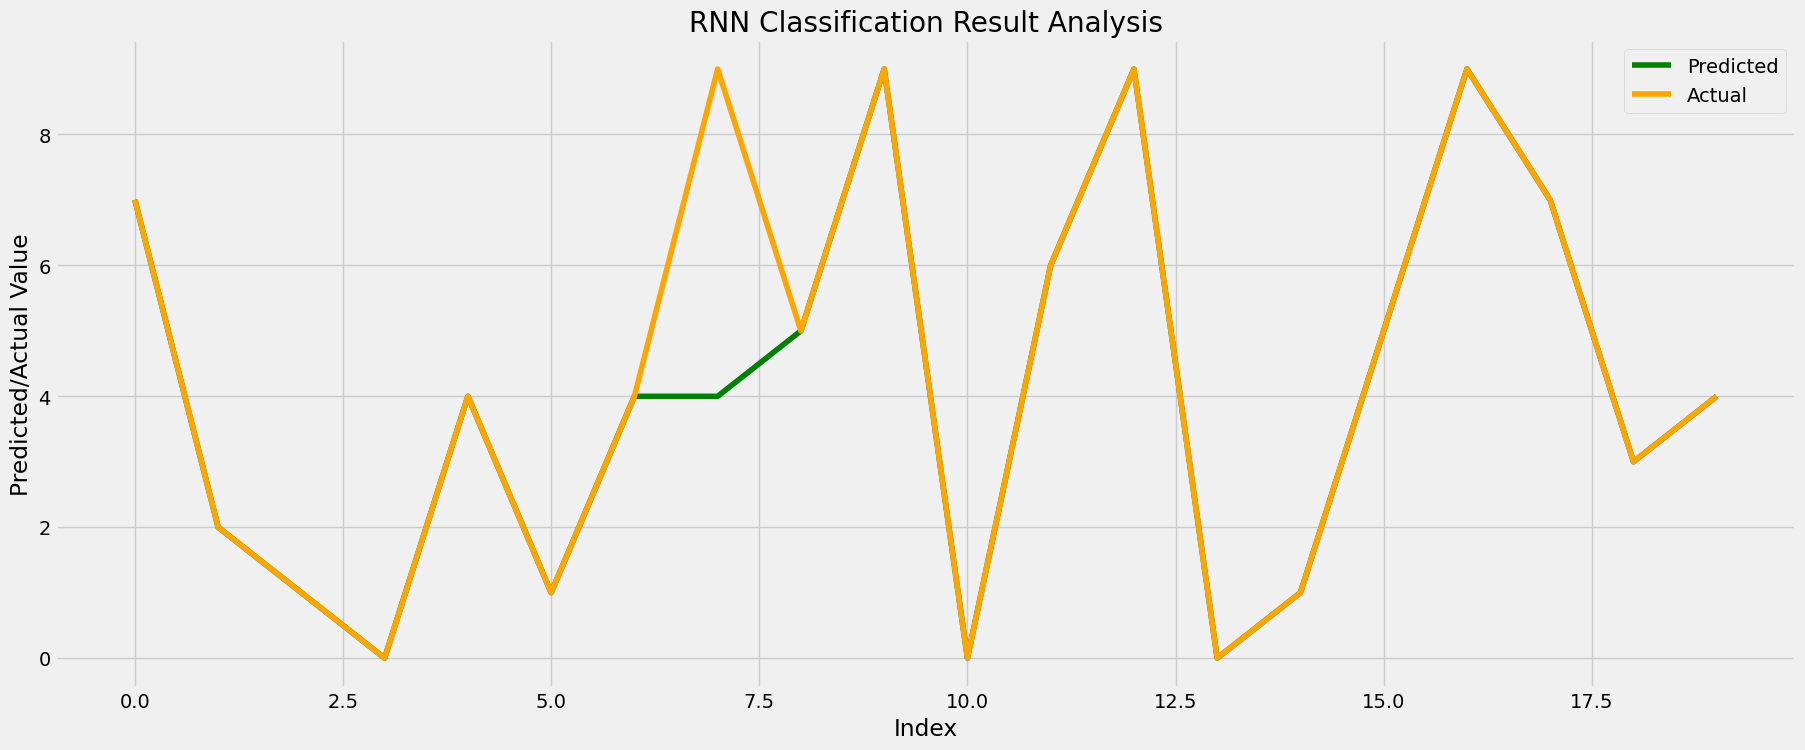

In [96]:
plt.figure(1, figsize=(20, 8))
plt.plot(pred_y, c='green', label='Predicted')
plt.plot(test_y[:20], c='orange', label='Actual')
plt.xlabel("Index")
plt.ylabel("Predicted/Actual Value")
plt.title("RNN Classification Result Analysis")
plt.legend(loc='best')

## RNN-Regression
---
Note : **Regression Concept I have already explaned above, so here I have applied direct RNN on Regression.**

In [97]:
import torch
from torch import nn
from torch.autograd import Variable
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

torch.manual_seed(1)    # reproducible

###  Hyper Parameters

In [98]:
# Hyper Parameters
TIME_STEP = 10      # rnn time step
INPUT_SIZE = 1      # rnn input size
LR = 0.02           # learning rate

### Show data

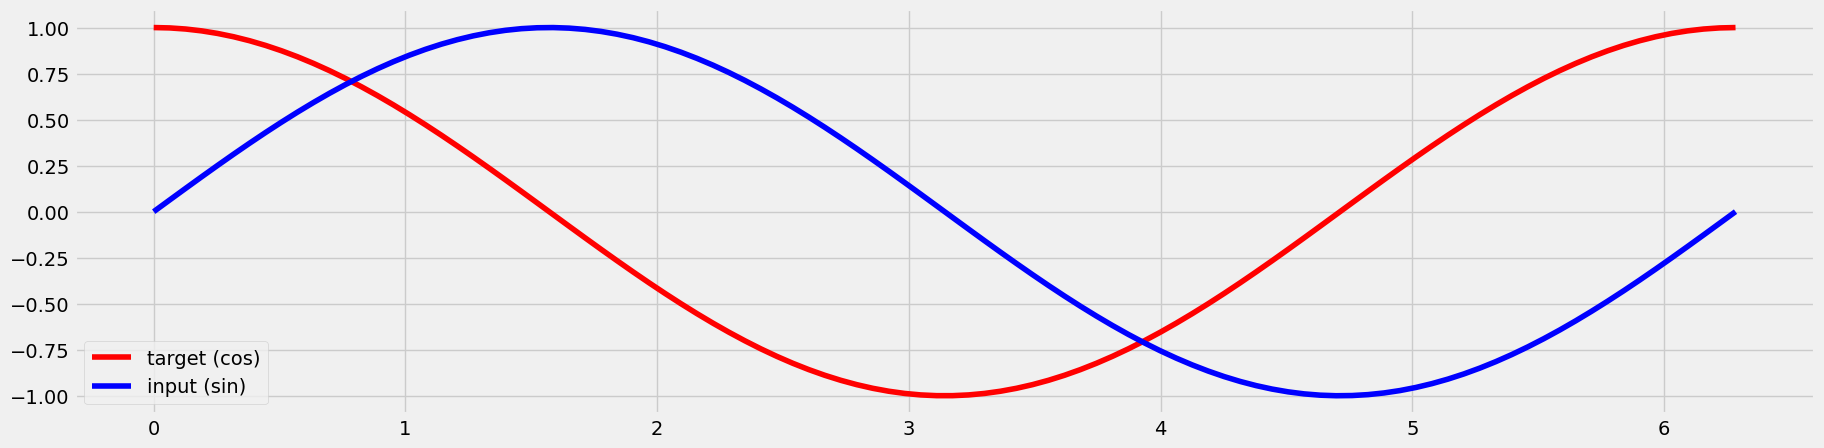

In [99]:
steps = np.linspace(0, np.pi*2, 100, dtype=np.float32)
x_np = np.sin(steps)    # float32 for converting torch FloatTensor
y_np = np.cos(steps)
plt.figure(figsize=(20,5))
plt.plot(steps, y_np, 'r-', label='target (cos)')
plt.plot(steps, x_np, 'b-', label='input (sin)')
plt.legend(loc='best')
plt.show()

### Model Design

In [100]:
class RNN(nn.Module):
    def __init__(self):
        super(RNN, self).__init__()

        self.rnn = nn.RNN(
            input_size=INPUT_SIZE,
            hidden_size=32,     # rnn hidden unit
            num_layers=1,       # number of rnn layer
            batch_first=True,   # input & output will has batch size as 1s dimension. e.g. (batch, time_step, input_size)
        )
        self.out = nn.Linear(32, 1)

    def forward(self, x, h_state):
        # x (batch, time_step, input_size)
        # h_state (n_layers, batch, hidden_size)
        # r_out (batch, time_step, hidden_size)
        r_out, h_state = self.rnn(x, h_state)

        outs = []    # save all predictions
        for time_step in range(r_out.size(1)):    # calculate output for each time step
            outs.append(self.out(r_out[:, time_step, :]))
        return torch.stack(outs, dim=1), h_state

        # instead, for simplicity, you can replace above codes by follows
        # r_out = r_out.view(-1, 32)
        # outs = self.out(r_out)
        # return outs, h_state

In [101]:
rnn = RNN()
print(rnn)

RNN(
  (rnn): RNN(1, 32, batch_first=True)
  (out): Linear(in_features=32, out_features=1, bias=True)
)


In [102]:
optimizer = torch.optim.Adam(rnn.parameters(), lr=LR)   # optimize all cnn parameters
loss_func = nn.MSELoss()

### Model Training and Result Plotting

In [103]:
h_state = None      # for initial hidden state

In [104]:
plt.ion()           # continuously plot

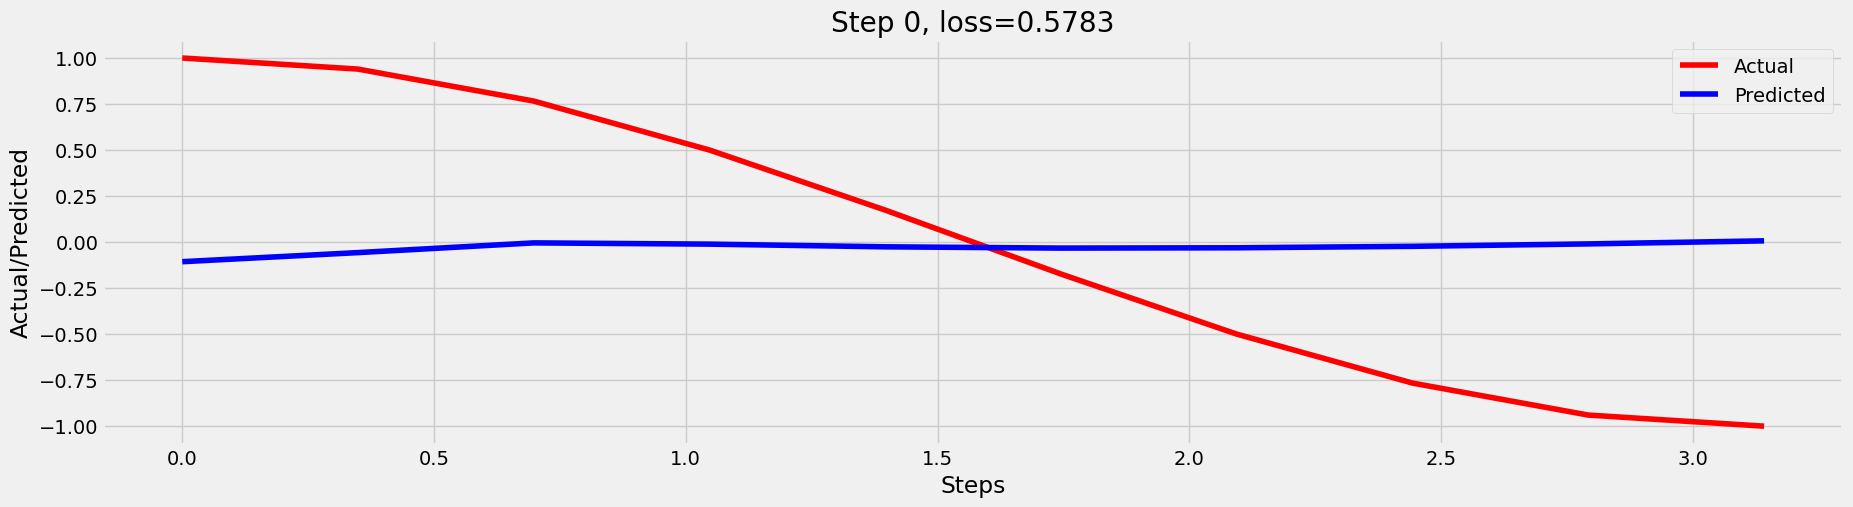

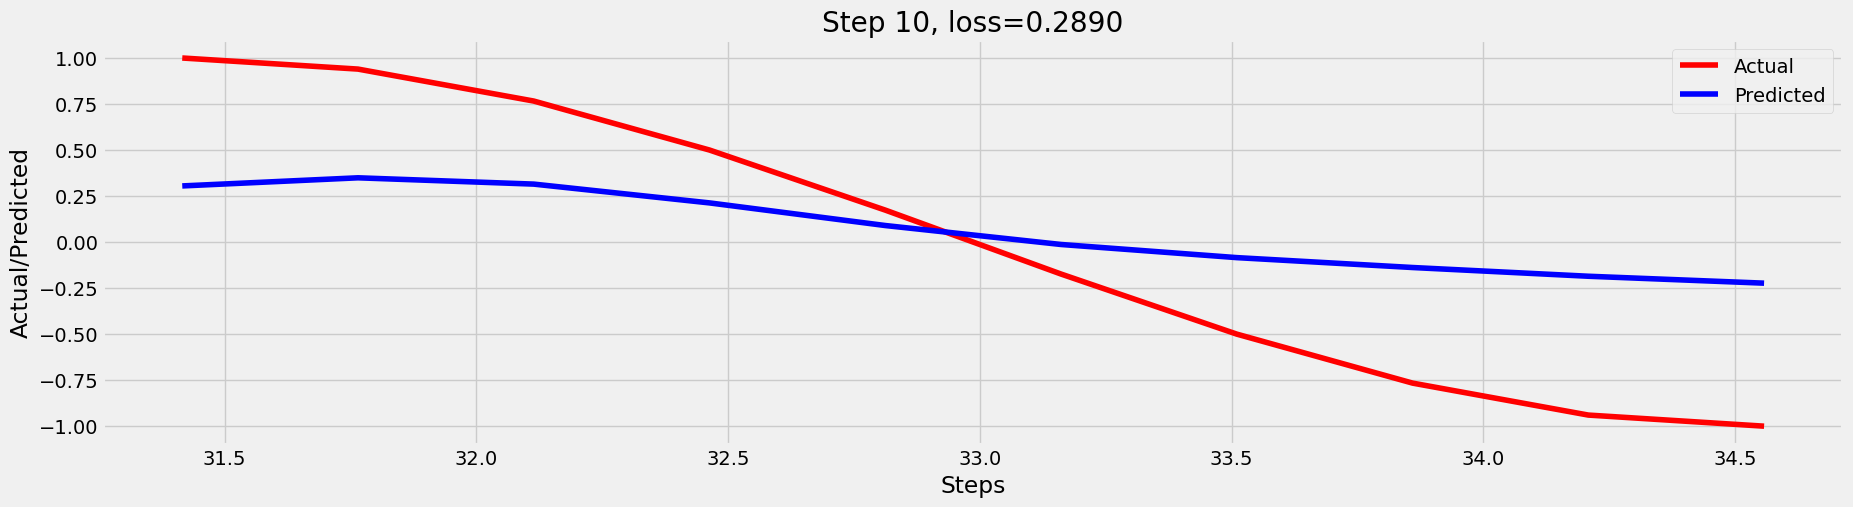

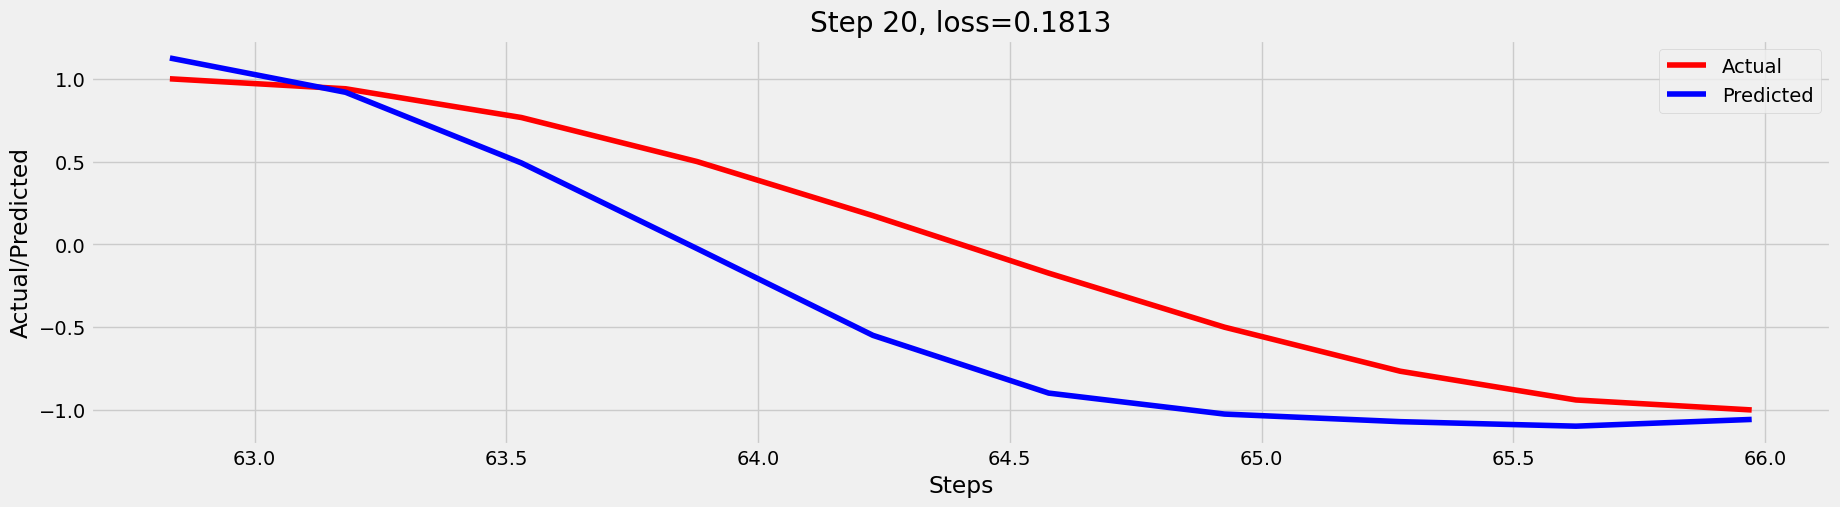

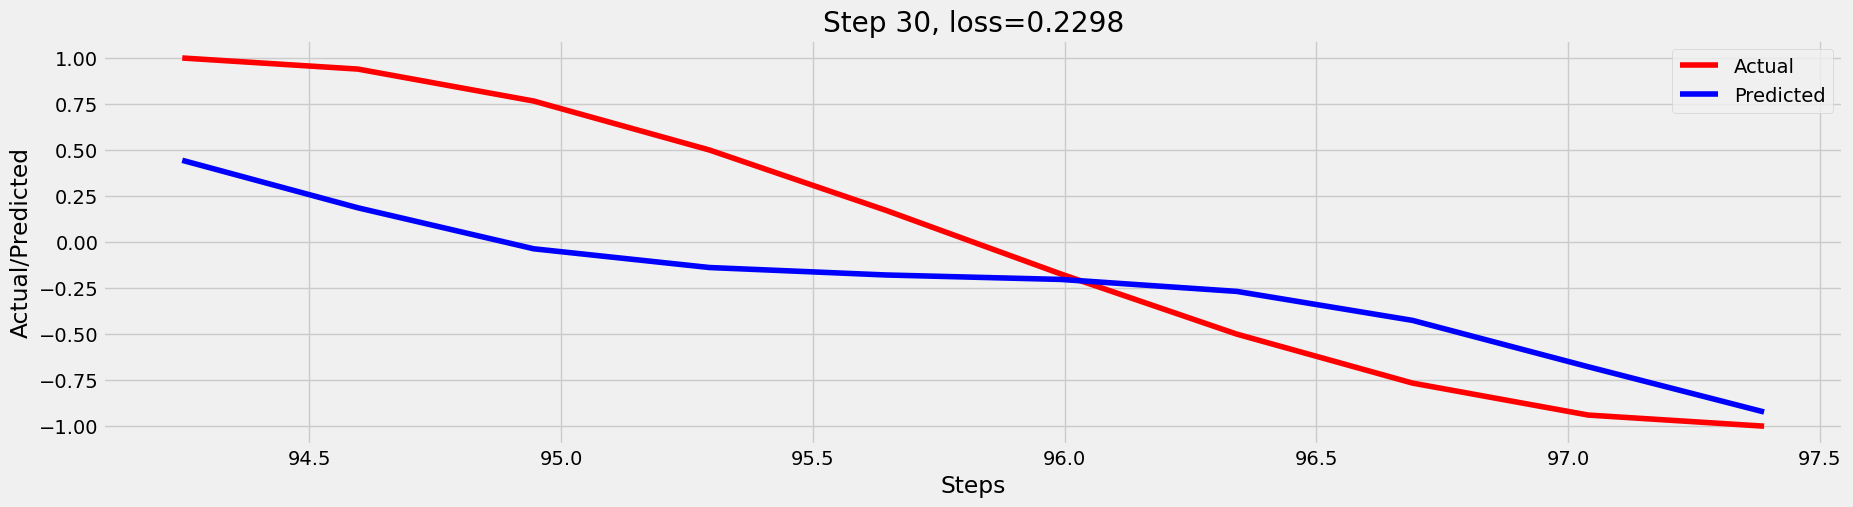

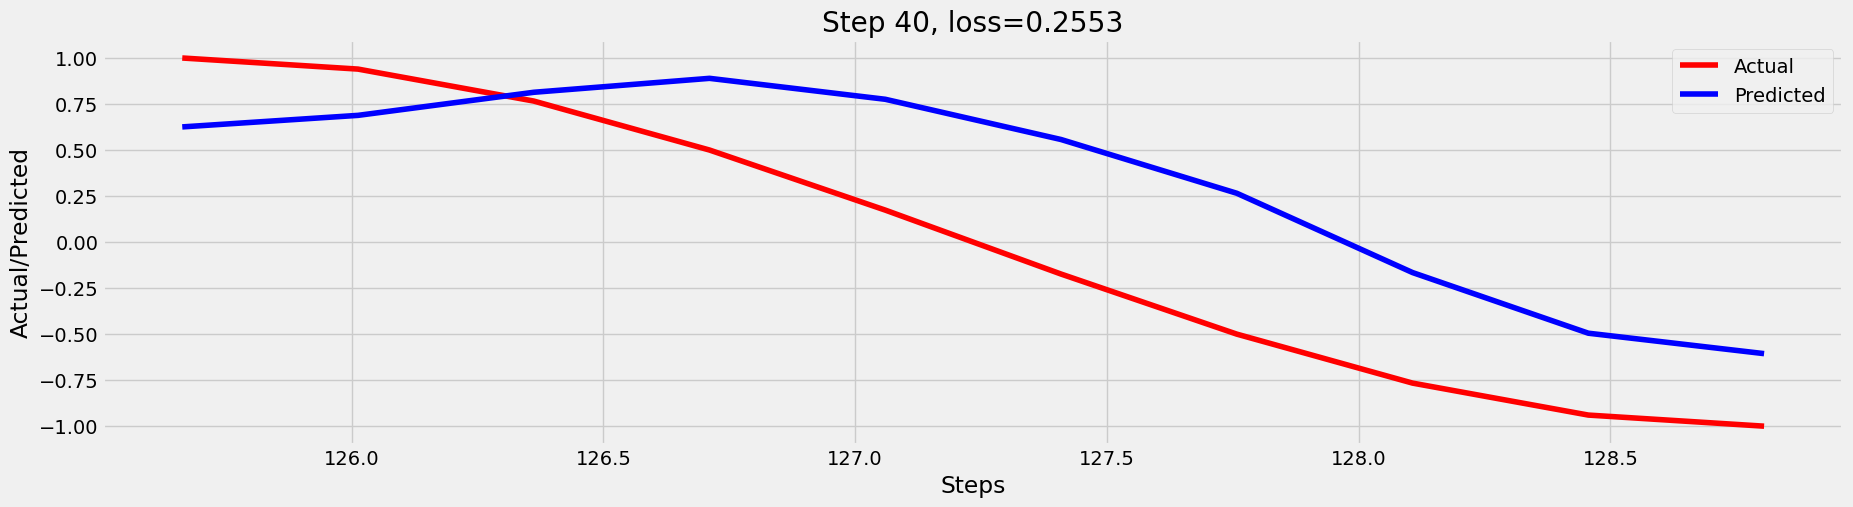

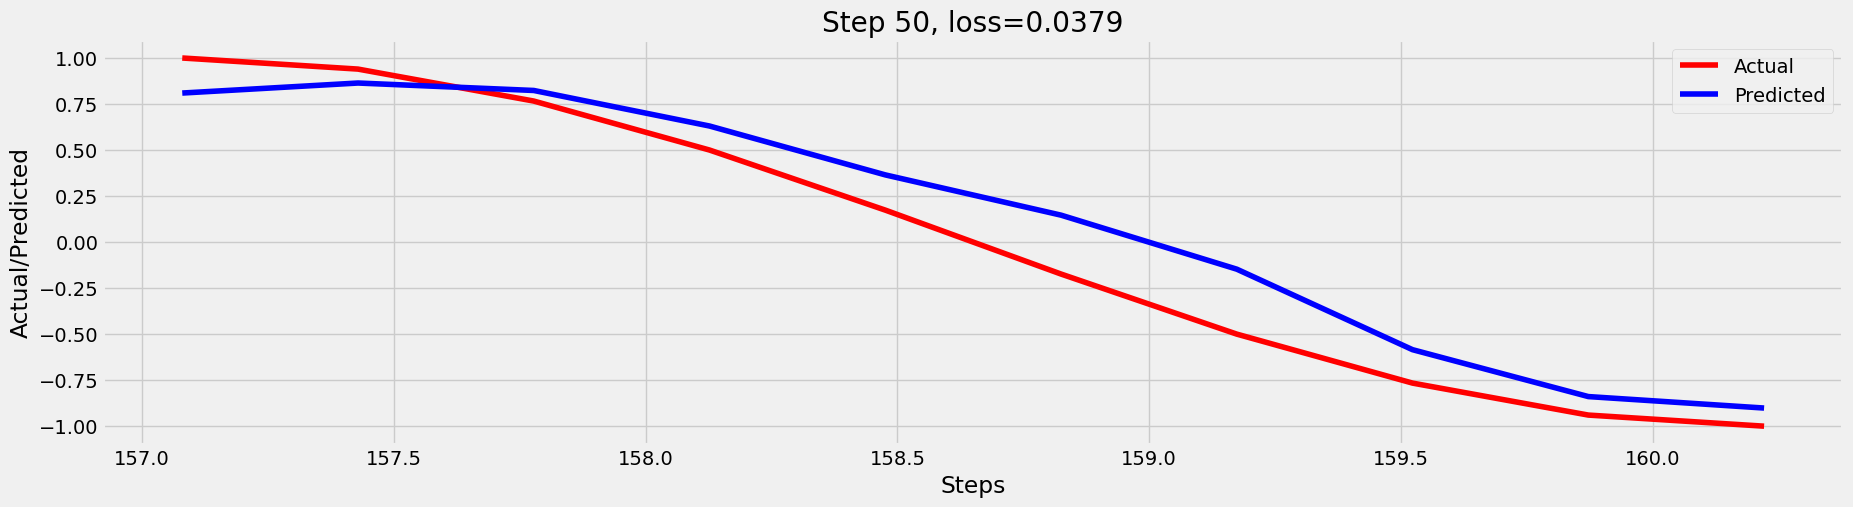

In [105]:
for step in range(60):
    start, end = step * np.pi, (step + 1) * np.pi
    steps = np.linspace(start, end, TIME_STEP, dtype=np.float32)
    x_np = np.sin(steps)
    y_np = np.cos(steps)

    x = torch.from_numpy(x_np[np.newaxis, :, np.newaxis])  # (batch, time_step, input_size)
    y = torch.from_numpy(y_np[np.newaxis, :, np.newaxis])

    prediction, h_state = rnn(x, h_state)
    h_state = h_state.detach()  # break the connection from last iteration

    loss = loss_func(prediction, y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if step % 10 == 0:
        plt.figure(figsize=(20, 5))
        plt.plot(steps, y_np.flatten(), 'r-', label="Actual")
        plt.plot(steps, prediction.data.numpy().flatten(), 'b-', label="Predicted")
        plt.xlabel("Steps")
        plt.ylabel("Actual/Predicted")
        plt.title("Step %d, loss=%.4f" % (step, loss.item()))
        plt.legend(loc='best')
        plt.show()

In [106]:
plt.ioff()
plt.show()

## AutoEncoder
---

* ***Nueral Network Unsupervised form is Known as AutoEncoder.***

* Autoencoders (AE) are neural networks that aims to copy their inputs to their outputs. They work by compressing the input into a latent-space representation, and then reconstructing the output from this representation. This kind of network is composed of two parts :

* **1) Encoder:** This is the part of the network that compresses the input into a latent-space representation. It can be represented by an encoding function h=f(x).
* **2) Decoder:** This part aims to reconstruct the input from the latent space representation. It can be represented by a decoding function r=g(h).

![](https://cdn-images-1.medium.com/max/880/1*V_YtxTFUqDrmmu2JqMZ-rA.png)

### What are autoencoders used for ?
* Data denoising and Dimensionality reduction for data visualization are considered as two main interesting practical applications of autoencoders. With appropriate dimensionality and sparsity constraints, autoencoders can learn data projections that are more interesting than PCA or other basic techniques.

### Types of autoencoder :
* **Vanilla autoencoder**: In its simplest form, the autoencoder is a three layers net, i.e. a neural net with one hidden layer. The input and output are the same, and we learn how to reconstruct the input, for example using the adam optimizer and the mean squared error loss function.([Code](https://gist.githubusercontent.com/nathanhubens/604fd9cfc2d7f3d022e3ef0cf4b787de/raw/bc437b49f974b767e488a4a896b0e869d87a39d6/vanilla%20autoencoder))

* **Multilayer autoencoder** :  If one hidden layer is not enough, we can obviously extend the autoencoder to more hidden layers.([Code](https://gist.githubusercontent.com/nathanhubens/219ab6efcfbab95508495eb6d6e41884/raw/d50fe4cb3b5d361da68156c789d5bd25f5dad321/multilayer%20autoencoder))
* **Convolutional autoencoder**: We may also ask ourselves: can autoencoders be used with Convolutions instead of Fully-connected layers ?
The answer is yes and the principle is the same, but using images (3D vectors) instead of flattened 1D vectors. The input image is downsampled to give a latent representation of smaller dimensions and force the autoencoder to learn a compressed version of the images. ([Code](https://gist.github.com/nathanhubens/2f11dd9257263874b94966eb48e42922/raw/48f545769116607f713cded00c82d698ce9fb25a/convolutional%20autoencoder))

* **Regularized autoencoder**:  There are other ways we can constraint the reconstruction of an autoencoder than to impose a hidden layer of smaller dimension than the input. Rather than limiting the model capacity by keeping the encoder and decoder shallow and the code size small, regularized autoencoders use a loss function that encourages the model to have other properties besides the ability to copy its input to its output. In practice, we usually find two types of regularized autoencoder: the sparse autoencoder and the denoising autoencoder.

    * **Sparse autoencoder**: Sparse autoencoders are typically used to learn features for another task such as classification. An autoencoder that has been regularized to be sparse must respond to unique statistical features of the dataset it has been trained on, rather than simply acting as an identity function. In this way, training to perform the copying task with a sparsity penalty can yield a model that has learned useful features as a byproduct.([Code](https://gist.github.com/nathanhubens/c6000eee8d6f919d01465183f79a62b6/raw/2e5085740299cf1d9f0a28ddfb438eee4bfe5903/Sparse%20autoencoder))

    * **Denoising autoencoder :** Rather than adding a penalty to the loss function, we can obtain an autoencoder that learns something useful by changing the reconstruction error term of the loss function. This can be done by adding some noise of the input image and make the autoencoder learn to remove it. By this means, the encoder will extract the most important features and learn a robuster representation of the data.([Code](https://gist.github.com/nathanhubens/2c2a7cc138e3d170956c109b10f5a7f7/raw/3b44ff899fe23f2224edf782e8dd068551d83ec5/denoising%20ae))


In [107]:
import torch
import torch.nn as nn
from torch.autograd import Variable
import torch.utils.data as Data
import torchvision
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
import numpy as np
%matplotlib inline

torch.manual_seed(1)    # reproducible

### Hyper Parameters

In [108]:
EPOCH = 10
BATCH_SIZE = 64
LR = 0.005         # learning rate
DOWNLOAD_MNIST = False
N_TEST_IMG = 5

In [109]:
train_data = torchvision.datasets.MNIST(
    root='./mnist/',
    train=True,
    transform=torchvision.transforms.ToTensor(),
    download=True,
)

torch.Size([60000, 28, 28])
torch.Size([60000])


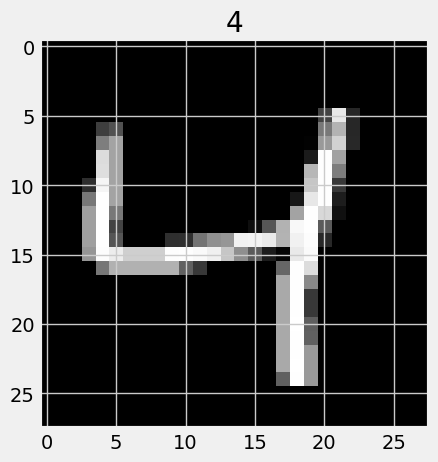

In [110]:
print(train_data.data.size())
print(train_data.targets.size())
plt.imshow(train_data.data[2].numpy(), cmap='gray')
plt.title('%i' % train_data.targets[2].item())
plt.show()

### Data Loader for easy mini-batch return in training, the image batch shape will be (50, 1, 28, 28)

In [111]:
train_loader = Data.DataLoader(dataset=train_data, batch_size=BATCH_SIZE, shuffle=True)

### Model Design

In [112]:
class AutoEncoder(nn.Module):
    def __init__(self):
        super(AutoEncoder, self).__init__()

        self.encoder = nn.Sequential(
            nn.Linear(28*28, 128),
            nn.Tanh(),
            nn.Linear(128, 64),
            nn.Tanh(),
            nn.Linear(64, 12),
            nn.Tanh(),
            nn.Linear(12, 3),   # compress to 3 features which can be visualized in plt
        )
        self.decoder = nn.Sequential(
            nn.Linear(3, 12),
            nn.Tanh(),
            nn.Linear(12, 64),
            nn.Tanh(),
            nn.Linear(64, 128),
            nn.Tanh(),
            nn.Linear(128, 28*28),
            nn.Sigmoid(),       # compress to a range (0, 1)
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return encoded, decoded

### Model Training

AutoEncoder(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): Tanh()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): Tanh()
    (4): Linear(in_features=64, out_features=12, bias=True)
    (5): Tanh()
    (6): Linear(in_features=12, out_features=3, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=3, out_features=12, bias=True)
    (1): Tanh()
    (2): Linear(in_features=12, out_features=64, bias=True)
    (3): Tanh()
    (4): Linear(in_features=64, out_features=128, bias=True)
    (5): Tanh()
    (6): Linear(in_features=128, out_features=784, bias=True)
    (7): Sigmoid()
  )
)
Epoch: 0 | train loss: 0.2330


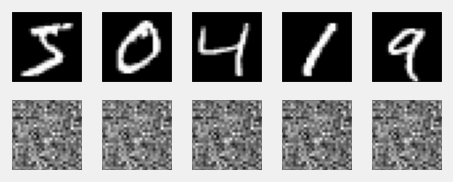

Epoch: 0 | train loss: 0.0607


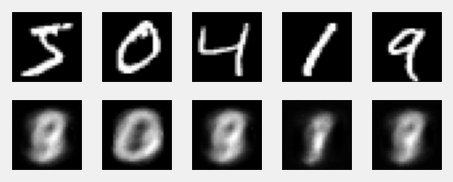

Epoch: 5 | train loss: 0.0352


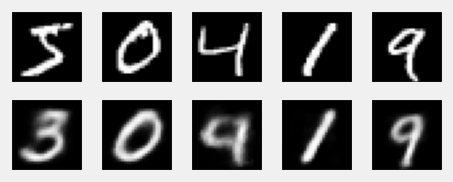

Epoch: 5 | train loss: 0.0388


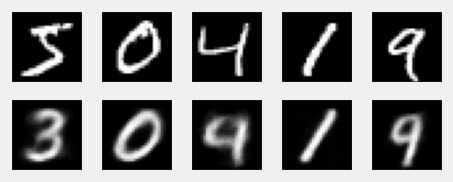

Epoch: 9 | train loss: 0.0336


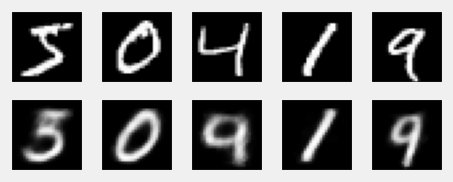

Epoch: 9 | train loss: 0.0393


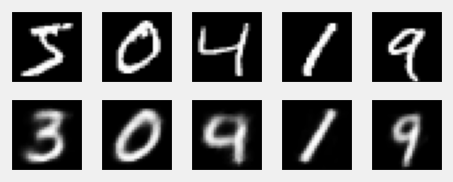

In [113]:
autoencoder = AutoEncoder()
print(autoencoder)

optimizer = torch.optim.Adam(autoencoder.parameters(), lr=LR)
loss_func = nn.MSELoss()

# Original data (first row) for viewing
view_data = train_data.data[:N_TEST_IMG].view(-1, 28 * 28).type(torch.FloatTensor) / 255.

for epoch in range(EPOCH):
    for step, (x, y) in enumerate(train_loader):
        b_x = x.view(-1, 28 * 28)
        b_y = x.view(-1, 28 * 28)

        encoded, decoded = autoencoder(b_x)
        loss = loss_func(decoded, b_y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if step % 500 == 0 and epoch in [0, 5, EPOCH - 1]:
            print('Epoch:', epoch, '| train loss: %.4f' % loss.item())

            with torch.no_grad():
                _, decoded_data = autoencoder(view_data)

            f, a = plt.subplots(2, N_TEST_IMG, figsize=(5, 2))
            for i in range(N_TEST_IMG):
                a[0][i].imshow(np.reshape(view_data.data.numpy()[i], (28, 28)), cmap='gray')
                a[0][i].set_xticks(()); a[0][i].set_yticks(())
            for i in range(N_TEST_IMG):
                a[1][i].imshow(np.reshape(decoded_data.data.numpy()[i], (28, 28)), cmap='gray')
                a[1][i].set_xticks(()); a[1][i].set_yticks(())
            plt.show()

### Visualize in 3D plot

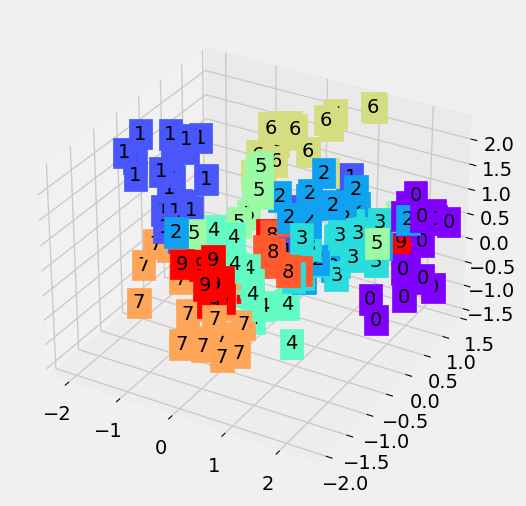

In [114]:
# Visualize in 3D plot
view_data = train_data.data[:200].view(-1, 28 * 28).type(torch.FloatTensor) / 255.
with torch.no_grad():
    encoded_data, _ = autoencoder(view_data)

fig = plt.figure(2, figsize=(15, 6))
ax = fig.add_subplot(111, projection='3d')
X = encoded_data.data[:, 0].numpy()
Y = encoded_data.data[:, 1].numpy()
Z = encoded_data.data[:, 2].numpy()
values = train_data.targets[:200].numpy()
for x_, y_, z_, s in zip(X, Y, Z, values):
    c = cm.rainbow(int(255 * int(s) / 9))
    ax.text(x_, y_, z_, str(int(s)), backgroundcolor=c)
ax.set_xlim(X.min(), X.max())
ax.set_ylim(Y.min(), Y.max())
ax.set_zlim(Z.min(), Z.max())
plt.show()

## DQN Reinforcement Learning
---

*  **Intensive learning**, Deep Q Network is referred to as DQN for short. The Google Deep Mind team is relying on this DQN to make computers play more powerful than us.

![](https://cdn-images-1.medium.com/max/1600/1*M8RWevLxhus56RABFEGYYQ.png)

### Reinforcement learning and neural networks
---

* **The reinforcement learning methods are more traditional methods.** Nowadays, with the various applications of **machine learning in daily life**, various machine learning methods are also integrated, merged and upgraded. The intensive study explored is a method that combines **neural network and Q learning , called Deep Q Network.** Why is this new structure proposed? Originally, traditional form-based reinforcement learning has such a bottleneck.

### The role of neural networks
---
![](https://morvanzhou.github.io/static/results/ML-intro/DQN2.png)
* We use a table to store each state state, and the Q value that each behavior action has in this state. The problem is that it is too complicated, and the state can be more than the stars in the sky (such as Go). Using tables to store them, I am afraid that our computer has not enough memory, and it is time consuming to search for the corresponding state in such a large table. However, in machine learning, there is a way It is very good for this kind of thing, that is the neural network.
* We can use the state and action as the input of the neural network, and then the neural network analysis to get the Q value of the action, so we do not need to record the Q value in the table, and It is directly using the neural network to generate Q values. Another form is that we can only input the state value, output all the action values, and then directly select the action with the maximum value as the next step according to the principle of Q learning.
* The action. We can imagine that the neural network accepts external information, which is equivalent to collecting information from the eyes, nose and ears, and then outputting each action through brain processing. The value, finally select the action by means of reinforcement learning.

### Q-Learning [Reference](https://medium.com/@jonathan_hui/rl-dqn-deep-q-network-e207751f7ae4)
---
* Q-learning learns the action-value function Q(s, a): how good to take an action at a particular state. For example, for the board position below, how good to move the pawn two steps forward. Literally, we assign a scalar value over the benefit of making such a move.

![](https://cdn-images-1.medium.com/max/800/1*srmv0GScAs6vObPfPj0-uQ.png)

* In Q-learning, we build a memory table Q[s, a] to store Q-values for all possible combinations of s and a. If you are a chess player, it is the cheat sheet for the best move. In the example above, we may realize that moving the pawn 2 steps ahead has the highest Q values over all others. (The memory consumption will be too high for the chess game. But let’s stick with this approach a little bit longer.)

* Technical speaking, we sample an action from the current state. We find out the reward R (if any) and the new state s’ (the new board position). From the memory table, we determine the next action a’ to take which has the maximum Q(s’, a’).

![](https://cdn-images-1.medium.com/max/800/1*yh8Z2t41HBvY5gwBPTqVVQ.jpeg)

* In a video game, we score points (rewards) by shooting down the enemy. In a chess game, the reward is +1 when we win or -1 if we lose. So there is only one reward given and it takes a while to get it.

* We can take a single move a and see what reward R can we get. This creates a one-step look ahead. R + Q(s’, a’) becomes the target that we want Q(s, a) to be. For example, say all Q values are equal to one now. If we move the joystick to the right and score 2 points, we want to move Q(s, a) closer to 3 (i.e. 2 + 1).

![](https://cdn-images-1.medium.com/max/800/1*9CdBkaFzFRyACvj5P2Af2Q.png)

* As we keep playing, we maintain a running average for Q. The values will get better and with some tricks, the Q values will converge.

---
### Q-Learning Algorithm

---
![](https://cdn-images-1.medium.com/max/800/1*5ffOxpSgIJCYn0XccfFYUQ.png)


* However, if the combinations of states and actions are too large, the memory and the computation requirement for Q will be too high. To address that, we switch to a deep network Q (DQN) to approximate Q(s, a). This is called Deep Q-learning. With the new approach, we generalize the approximation of the Q-value function rather than remembering the solutions.

![](https://rubenfiszel.github.io/posts/rl4j/qmodeling.png)

---
### Deep Q-Network Algorithm with experience replay

---

**Algorithms**
![](https://cdn-images-1.medium.com/max/800/1*8coZ4g_pRtfyoHmsuzMH6g.png)


In [115]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import gym

### Hyper Parameters

In [116]:
# Hyper Parameters
BATCH_SIZE = 32
LR = 0.01
EPSILON = 0.9
GAMMA = 0.9
TARGET_REPLACE_ITER = 100
MEMORY_CAPACITY = 2000

env = gym.make('CartPole-v1')
# Older gym used env = env.unwrapped to bypass episode-step limits; modern gym keeps
# the same API but we still call unwrapped to access env.x_threshold etc.
env = env.unwrapped
N_ACTIONS = env.action_space.n
N_STATES = env.observation_space.shape[0]
ENV_A_SHAPE = 0 if isinstance(env.action_space.sample(), int) else env.action_space.sample().shape
print('N_ACTIONS:', N_ACTIONS, '| N_STATES:', N_STATES)

N_ACTIONS: 2 | N_STATES: 4


### Neural Network Design

In [117]:
class Net(nn.Module):
    def __init__(self, ):
        super(Net, self).__init__()
        self.fc1 = nn.Linear(N_STATES, 10)
        self.fc1.weight.data.normal_(0, 0.1)   # initialization
        self.out = nn.Linear(10, N_ACTIONS)
        self.out.weight.data.normal_(0, 0.1)   # initialization

    def forward(self, x):
        x = self.fc1(x)
        x = F.relu(x)
        actions_value = self.out(x)
        return actions_value

### DQN Model Design

In [118]:
class DQN(object):
    def __init__(self):
        self.eval_net, self.target_net = Net(), Net()

        self.learn_step_counter = 0
        self.memory_counter = 0
        self.memory = np.zeros((MEMORY_CAPACITY, N_STATES * 2 + 2))
        self.optimizer = torch.optim.Adam(self.eval_net.parameters(), lr=LR)
        self.loss_func = nn.MSELoss()

    def choose_action(self, x):
        x = torch.unsqueeze(torch.FloatTensor(x), 0)
        if np.random.uniform() < EPSILON:           # greedy
            actions_value = self.eval_net.forward(x)
            action = torch.max(actions_value, 1)[1].data.numpy()
            action = action[0] if ENV_A_SHAPE == 0 else action.reshape(ENV_A_SHAPE)
        else:                                       # random
            action = np.random.randint(0, N_ACTIONS)
            action = action if ENV_A_SHAPE == 0 else action.reshape(ENV_A_SHAPE)
        return action

    def store_transition(self, s, a, r, s_):
        transition = np.hstack((s, [a, r], s_))
        index = self.memory_counter % MEMORY_CAPACITY
        self.memory[index, :] = transition
        self.memory_counter += 1

    def learn(self):
        # target parameter update
        if self.learn_step_counter % TARGET_REPLACE_ITER == 0:
            self.target_net.load_state_dict(self.eval_net.state_dict())
        self.learn_step_counter += 1

        # sample batch transitions
        sample_index = np.random.choice(MEMORY_CAPACITY, BATCH_SIZE)
        b_memory = self.memory[sample_index, :]
        b_s  = torch.FloatTensor(b_memory[:, :N_STATES])
        b_a  = torch.LongTensor(b_memory[:, N_STATES:N_STATES + 1].astype(int))
        b_r  = torch.FloatTensor(b_memory[:, N_STATES + 1:N_STATES + 2])
        b_s_ = torch.FloatTensor(b_memory[:, -N_STATES:])

        q_eval = self.eval_net(b_s).gather(1, b_a)                  # (batch, 1)
        q_next = self.target_net(b_s_).detach()                     # don't backprop
        q_target = b_r + GAMMA * q_next.max(1)[0].view(BATCH_SIZE, 1)  # (batch, 1)
        loss = self.loss_func(q_eval, q_target)

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

In [119]:
dqn = DQN()

In [120]:
print('Collecting experience...')

def reset_env(env):
    out = env.reset()
    # gym >= 0.26 returns (obs, info); older returns obs only
    if isinstance(out, tuple) and len(out) == 2:
        return out[0]
    return out

def step_env(env, action):
    out = env.step(action)
    if len(out) == 5:
        s_, r, terminated, truncated, info = out
        done = terminated or truncated
    else:
        s_, r, done, info = out
    return s_, r, done, info

# Train for a small number of episodes so the cell finishes in Colab without
# needing GPU or a display. Bump N_EPISODES for serious training.
N_EPISODES = 50
for i_episode in range(N_EPISODES):
    s = reset_env(env)
    ep_r = 0
    while True:
        a = dqn.choose_action(s)
        s_, r, done, info = step_env(env, a)

        # shape the reward as the original tutorial did
        x, x_dot, theta, theta_dot = s_
        r1 = (env.x_threshold - abs(x)) / env.x_threshold - 0.8
        r2 = (env.theta_threshold_radians - abs(theta)) / env.theta_threshold_radians - 0.5
        r = r1 + r2

        dqn.store_transition(s, a, r, s_)
        ep_r += r

        if dqn.memory_counter > MEMORY_CAPACITY:
            dqn.learn()
            if done:
                print('Ep:', i_episode, '| Ep_r:', round(ep_r, 2))

        if done:
            break
        s = s_

env.close()

#### Note : After Running this code you can find below output this will not open here you have to run in your own computer.because it will generate ikernel for this.

![](https://pytorch.org/tutorials/_images/cartpole1.gif)

## Generative Adversarial Network
---
![](https://cdn-images-1.medium.com/max/2000/1*AZ5-3WdNdYyC2U0Aq7RhIg.png)

* In **2014, Ian Goodfellow and his colleagues at the University of Montreal published** a [stunning paper](https://arxiv.org/pdf/1406.2661.pdf) introducing the world to **GANs, or generative adversarial networks.** Through an innovative combination of computational graphs and game theory they showed that, given enough modeling power, two models fighting against each other would be able to co-train through plain old backpropagation.

![](https://cdn-images-1.medium.com/max/800/1*-gFsbymY9oJUQJ-A3GTfeg.png)


* The models play **two distinct (literally, adversarial) roles.** Given some real data set **R, G** is the **generator**, trying to **create fake data** that looks just like **the genuine data,** while **D** is the **discriminator**, getting data from either the real set or **G** and labeling the difference. **Goodfellow’s metaphor** (and a fine one it is) was that **G** was like a **team of forgers trying to match real paintings** with their output, while **D** was the team of **detectives trying to tell the difference**. (Except that in this case, the forgers G never get to see the original data — only the judgments of D. They’re like blind forgers.)

* **GANs** or **Generative Adversarial Networks** are a kind of neural networks that is composed of **2** separate deep neural networks competing each other: the **generator** and **the discriminator**.

* **GAN** to generate various things. It can **generate realistic images, 3D-models, videos, and a lot more.Like this Example below**
![](https://cdn-images-1.medium.com/max/800/1*NmRWSaTpBydHKnGIEAyWMw.png)

---
### Idea of GAN

---
#### Architecture of GAN
![](https://cdn-images-1.medium.com/max/2000/1*39Nnni_nhPDaLu9AnTLoWw.png)
**1) Generator**
![](https://cdn-images-1.medium.com/max/1000/1*7i9iCdLZraZkrMy1-KADrA.png)
**2) Discriminator:**
![](https://www.researchgate.net/profile/Sinan_Kaplan2/publication/319093376/figure/fig20/AS:526859935731712@1502624605127/Architecture-of-proposed-discriminator-network-which-is-part-of-GAN-based-on-CNN-units.png)

### Conceptual Diagram

![](https://cdn-images-1.medium.com/max/1200/1*M2Er7hbryb2y0RP1UOz5Rw.png)

> * **"The generator will try to generate fake images that fool the discriminator into thinking that they’re real. And the discriminator will try to distinguish between a real and a generated image as best as it could when an image is fed.”**

* They both get stronger together until the **discriminator** cannot **distinguish** between the **real and the generated images anymore**. It could do nothing more than **predicting real or fake with only 50% accuracy.** This is no more useful than **flipping a coin and guess.**
* This inaccuracy of the **discriminator occurs because the generator generates really realistic face images** that it seems like they are actually real. So, it is normally expected that it wouldn’t be able to distinguish them. When that happens, the most educated guess would be as equally useful as an uneducated random guess.

---
### The optimal generator
---
* Intuitively, the Code vector that I shown earlier in the generator will represent things that are abstract. For example, if the Code vector has 100 dimensions, there might be a dimension that represents “face age” or “gender” automatically.
* Why would it learn such representation? Because knowing people ages and their gender helps you draw their face more properly!

---
### The optimal discriminator
---
* When given an image, the discriminator must be looking for components of the face to be able to distinguish correctly.
* Intuitively, some of the discriminator’s hidden neurons will be excited when it sees things like eyes, mouths, hair, etc. These features are good for other purposes later like classification!

In [121]:
import torch
import torch.nn as nn
from torch.autograd import Variable
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

torch.manual_seed(1)    # reproducible
np.random.seed(1)

### Hyper Parameters

In [122]:
# Hyper Parameters
BATCH_SIZE = 64
LR_G = 0.0001           # learning rate for generator
LR_D = 0.0001           # learning rate for discriminator
N_IDEAS = 5             # think of this as number of ideas for generating an art work (Generator)
ART_COMPONENTS = 15     # it could be total point G can draw in the canvas
PAINT_POINTS = np.vstack([np.linspace(-1, 1, ART_COMPONENTS) for _ in range(BATCH_SIZE)])

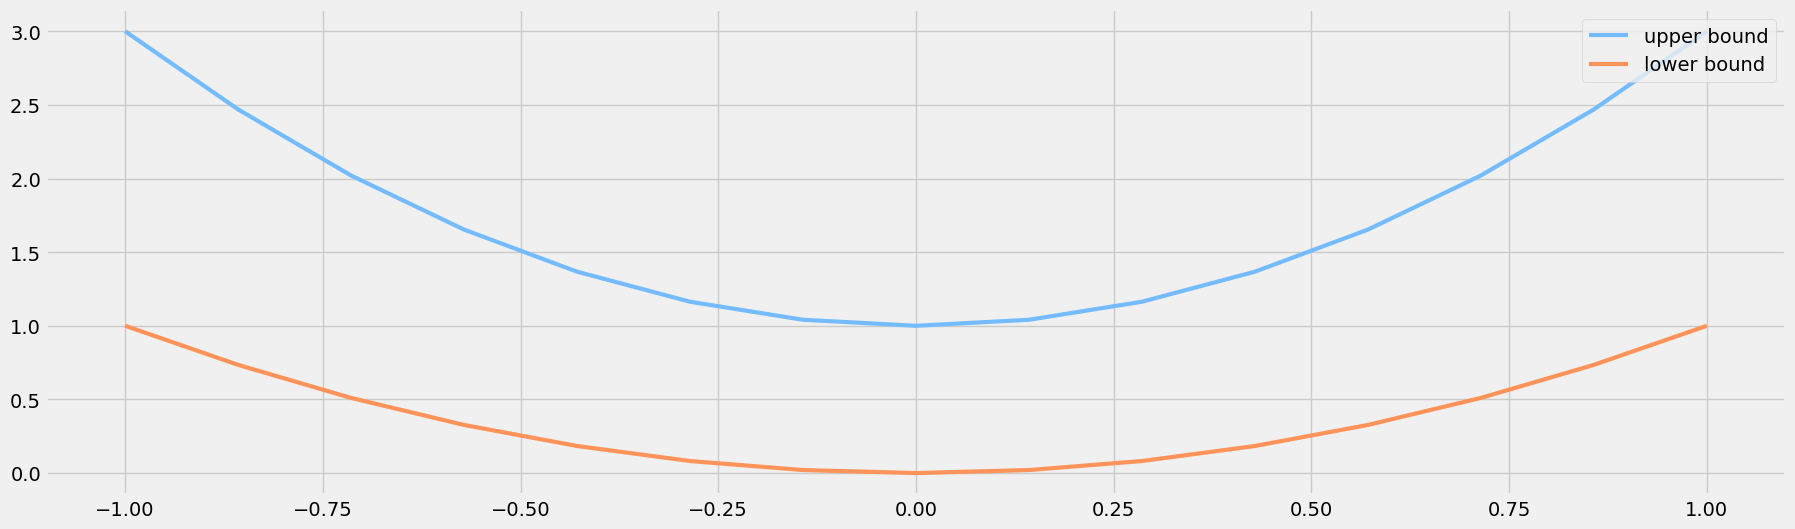

In [123]:
# show our beautiful painting range
plt.figure(figsize=(20,6))
plt.plot(PAINT_POINTS[0], 2 * np.power(PAINT_POINTS[0], 2) + 1, c='#74BCFF', lw=3, label='upper bound')
plt.plot(PAINT_POINTS[0], 1 * np.power(PAINT_POINTS[0], 2) + 0, c='#FF9359', lw=3, label='lower bound')
plt.legend(loc='upper right')
plt.show()

In [124]:
def artist_works():     # painting from the famous artist (real target)
    a = np.random.uniform(1, 2, size=BATCH_SIZE)[:, np.newaxis]
    paintings = a * np.power(PAINT_POINTS, 2) + (a-1)
    paintings = torch.from_numpy(paintings).float()
    return Variable(paintings)

G = nn.Sequential(                      # Generator
    nn.Linear(N_IDEAS, 128),            # random ideas (could from normal distribution)
    nn.ReLU(),
    nn.Linear(128, ART_COMPONENTS),     # making a painting from these random ideas
)

D = nn.Sequential(                      # Discriminator
    nn.Linear(ART_COMPONENTS, 128),     # receive art work either from the famous artist or a newbie like G
    nn.ReLU(),
    nn.Linear(128, 1),
    nn.Sigmoid(),                       # tell the probability that the art work is made by artist
)

In [125]:
opt_D = torch.optim.Adam(D.parameters(), lr=LR_D)
opt_G = torch.optim.Adam(G.parameters(), lr=LR_G)

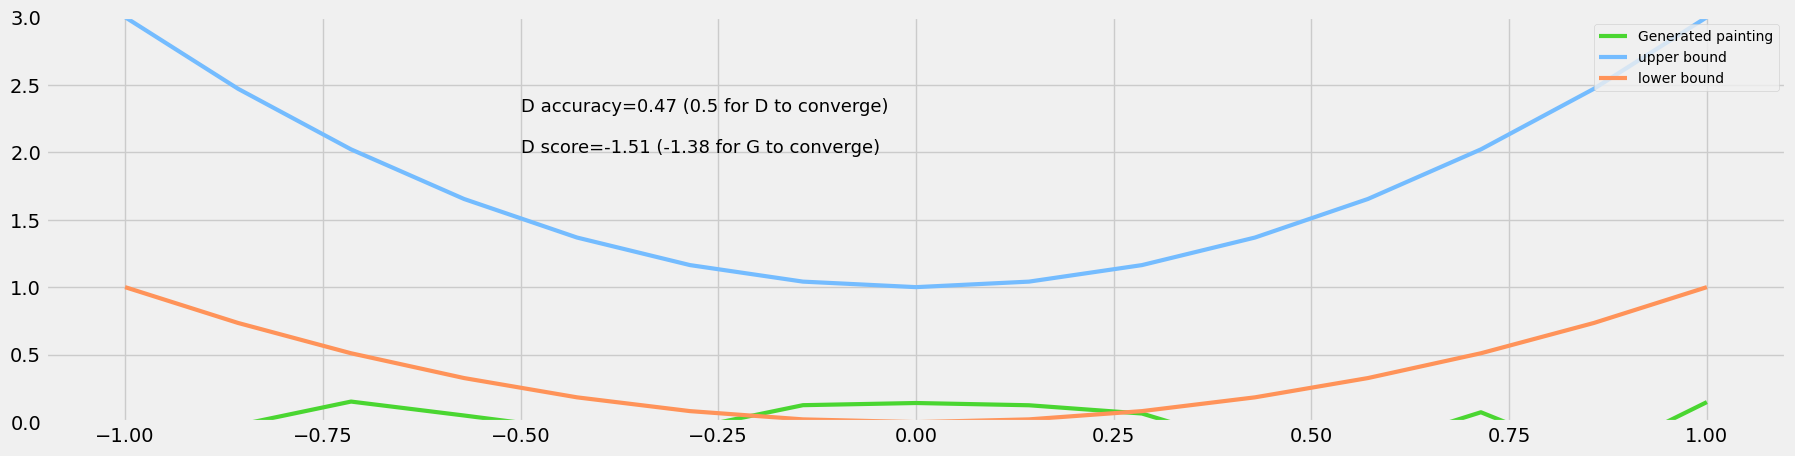

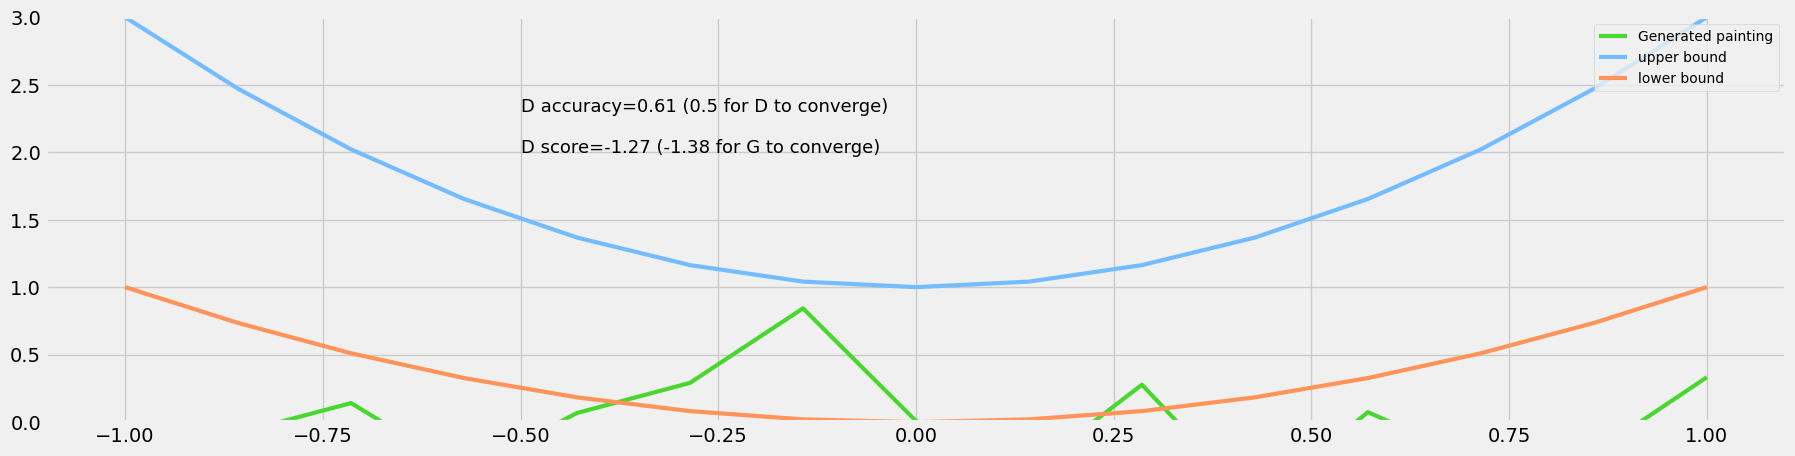

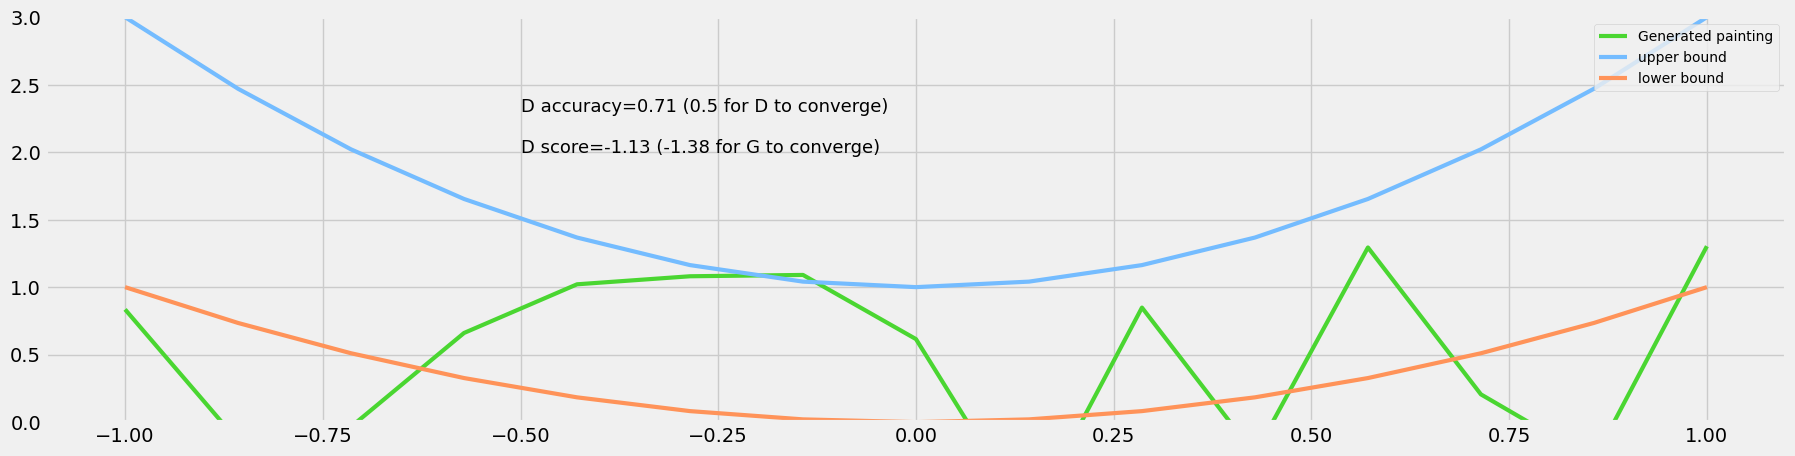

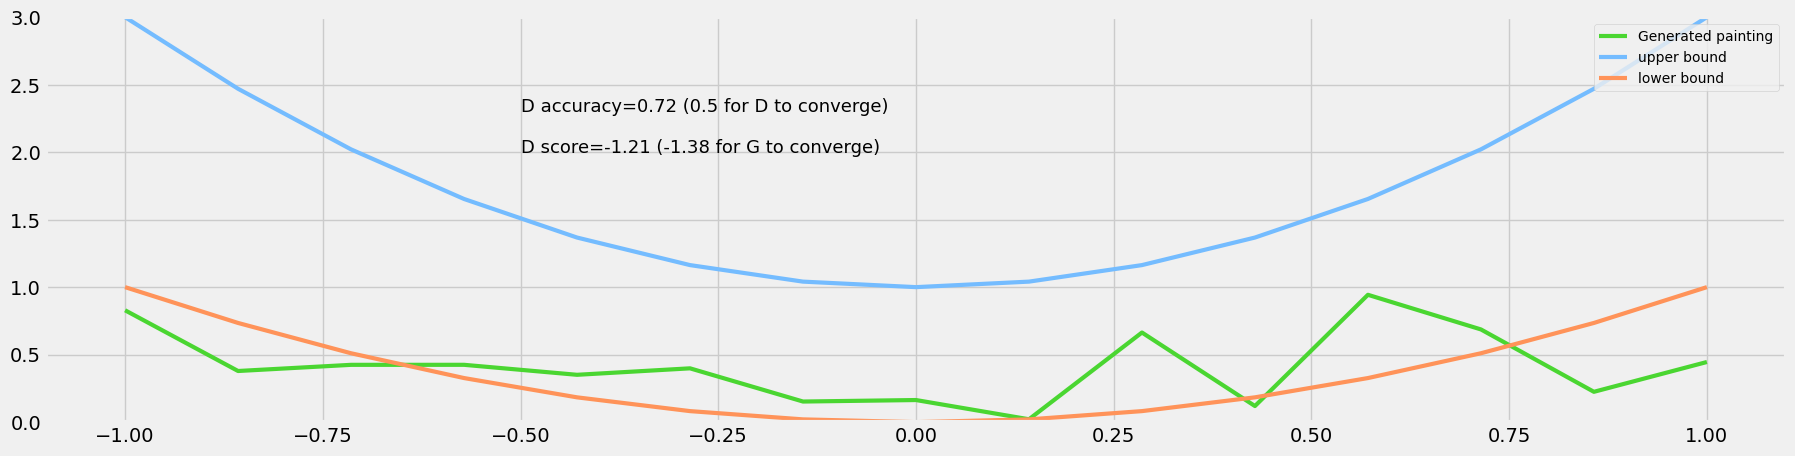

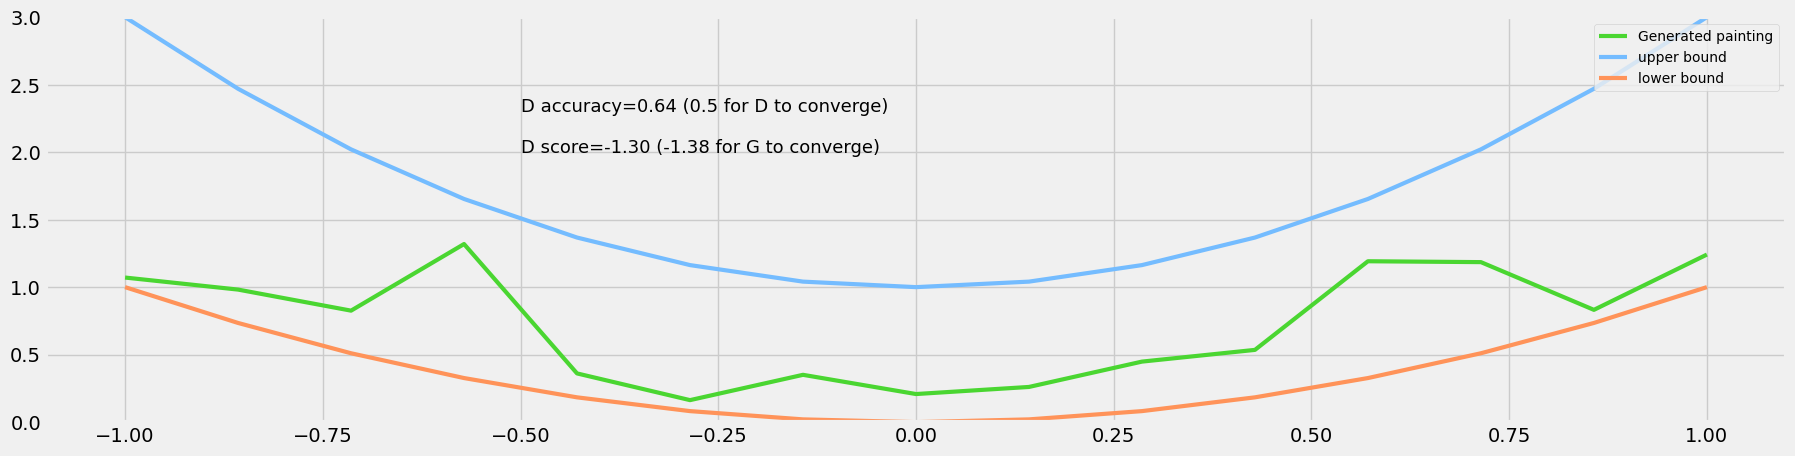

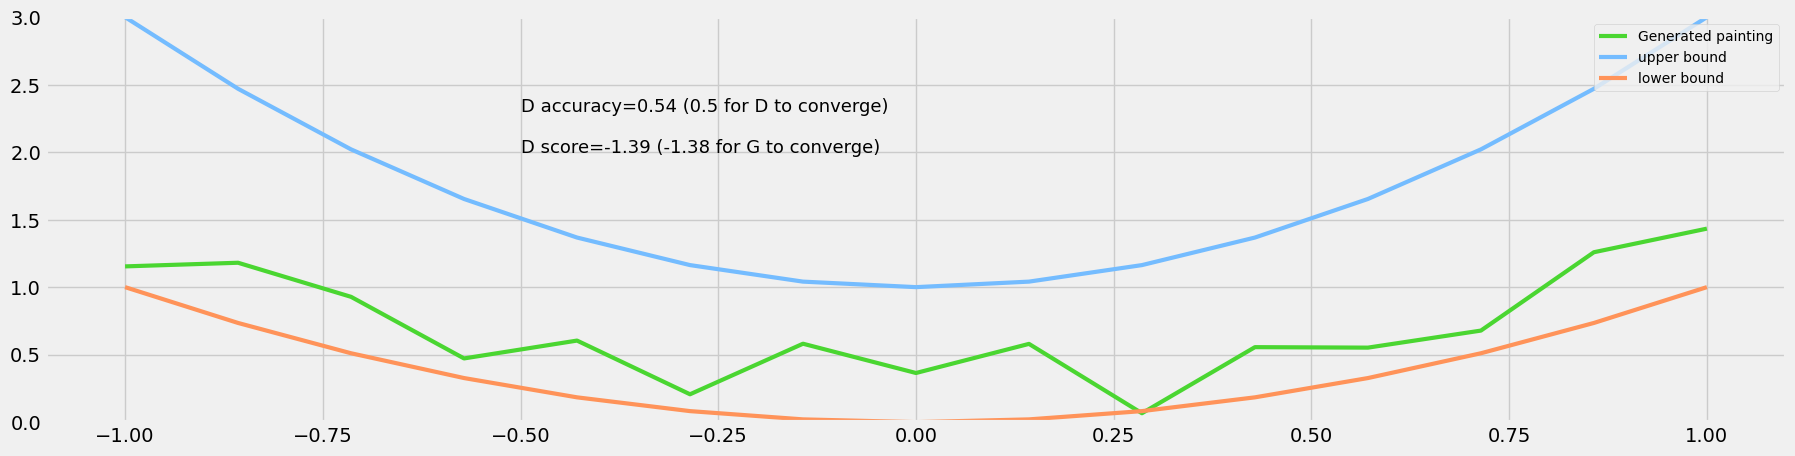

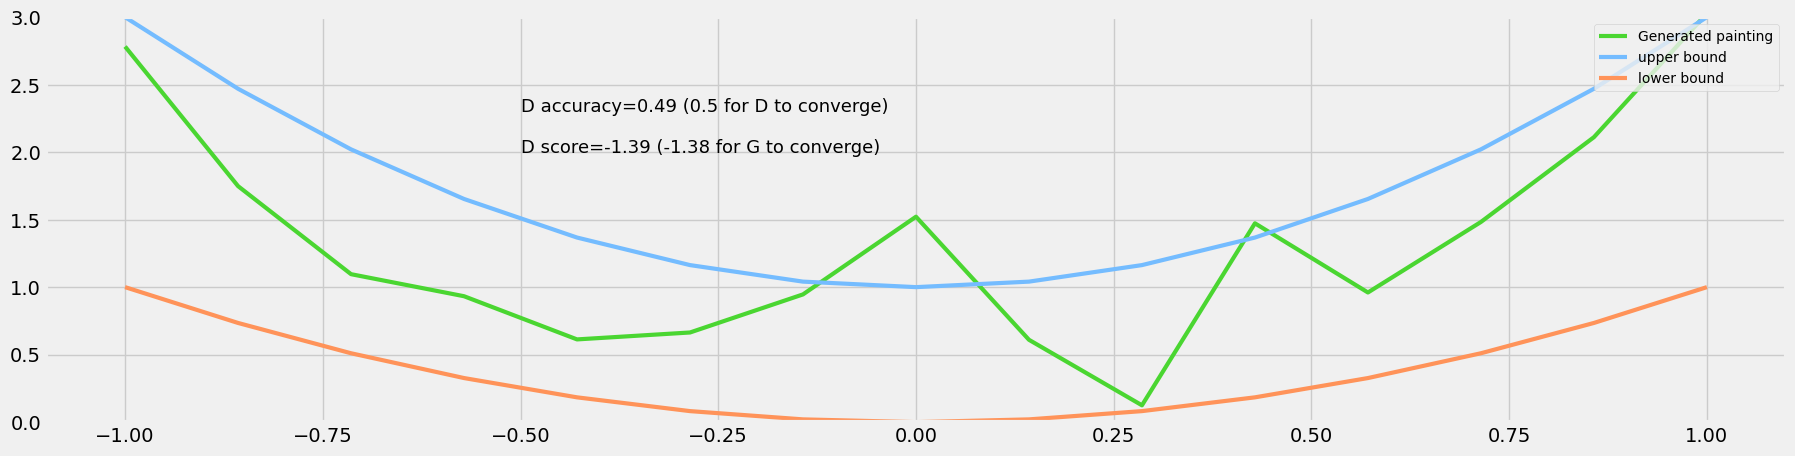

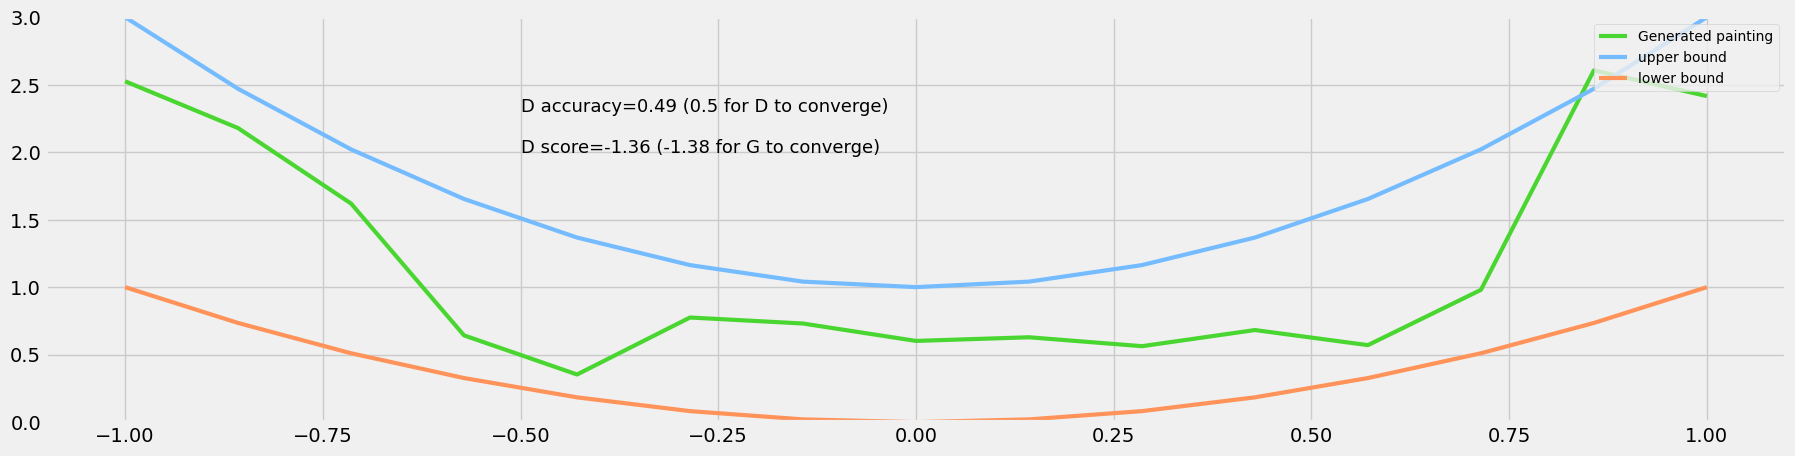

In [126]:
for step in range(800):
    artist_paintings = artist_works()
    G_ideas = torch.randn(BATCH_SIZE, N_IDEAS)
    G_paintings = G(G_ideas)

    # ---- Train D ----
    prob_artist0 = D(artist_paintings)              # D wants this ~1
    prob_artist1 = D(G_paintings.detach())          # detach -> no grad into G
    D_loss = -torch.mean(torch.log(prob_artist0) + torch.log(1. - prob_artist1))
    opt_D.zero_grad()
    D_loss.backward()
    opt_D.step()

    # ---- Train G (fresh forward through the now-updated D) ----
    prob_artist1_for_G = D(G_paintings)             # graph intact for G
    G_loss = torch.mean(torch.log(1. - prob_artist1_for_G))
    opt_G.zero_grad()
    G_loss.backward()
    opt_G.step()

    if step % 100 == 0:
        plt.figure(figsize=(20, 5))
        plt.cla()
        plt.plot(PAINT_POINTS[0], G_paintings.data.numpy()[0],
                 c='#4AD631', lw=3, label='Generated painting')
        plt.plot(PAINT_POINTS[0], 2 * np.power(PAINT_POINTS[0], 2) + 1,
                 c='#74BCFF', lw=3, label='upper bound')
        plt.plot(PAINT_POINTS[0], 1 * np.power(PAINT_POINTS[0], 2) + 0,
                 c='#FF9359', lw=3, label='lower bound')
        plt.text(-.5, 2.3,
                 'D accuracy=%.2f (0.5 for D to converge)' % prob_artist0.data.numpy().mean(),
                 fontdict={'size': 13})
        plt.text(-.5, 2.0,
                 'D score=%.2f (-1.38 for G to converge)' % -D_loss.item(),
                 fontdict={'size': 13})
        plt.ylim((0, 3))
        plt.legend(loc='upper right', fontsize=10)
        plt.show()

### Conditional GAN
---

In [127]:
import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision import transforms
from torchvision.utils import save_image
import numpy as np
import datetime
from PIL import Image  # used to save sample images (scipy.misc.imsave is gone)

In [128]:
MODEL_NAME = 'ConditionalGAN'
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [129]:
def to_cuda(x):
    return x.to(DEVICE)

In [130]:
def to_onehot(x, num_classes=10):
    if isinstance(x, int):
        c = torch.zeros(1, num_classes).long()
        c[0][x] = 1
        return c
    if torch.is_tensor(x):
        x_cpu = x.detach().cpu().long()
        if x_cpu.dim() == 1:
            x_cpu = x_cpu.view(-1, 1)
        c = torch.zeros(x_cpu.size(0), num_classes).long()
        c.scatter_(1, x_cpu, 1)
        return c
    raise TypeError("to_onehot expects int or torch tensor, got %s" % type(x))

In [131]:
def get_sample_image(G, n_noise=100):
    """Build a 10x10 grid of generated samples, one row per digit class."""
    all_img = None
    for num in range(10):
        c = to_cuda(to_onehot(num))
        line_img = None
        for i in range(10):
            z = to_cuda(torch.randn(1, n_noise))
            y_hat = G(z, c).view(28, 28)
            line_img = y_hat if line_img is None else torch.cat((line_img, y_hat), dim=1)
        all_img = line_img if all_img is None else torch.cat((all_img, line_img), dim=0)
    img = all_img.detach().cpu().numpy()
    img = ((img + 1) * 127.5).clip(0, 255).astype(np.uint8)  # Tanh output is [-1, 1]
    return img

In [132]:
class Discriminator(nn.Module):
    """
        Simple Discriminator w/ MLP
    """
    def __init__(self, input_size=784, label_size=10, num_classes=1):
        super(Discriminator, self).__init__()
        self.layer1 = nn.Sequential(
            nn.Linear(input_size+label_size, 200),
            nn.ReLU(),
            nn.Dropout(),
        )
        self.layer2 = nn.Sequential(
            nn.Linear(200, 200),
            nn.ReLU(),
            nn.Dropout(),
        )
        self.layer3 = nn.Sequential(
            nn.Linear(200, num_classes),
            nn.Sigmoid(),
        )

    def forward(self, x, y):
        x, y = x.view(x.size(0), -1), y.view(y.size(0), -1).float()
        v = torch.cat((x, y), 1) # v: [input, label] concatenated vector
        y_ = self.layer1(v)
        y_ = self.layer2(y_)
        y_ = self.layer3(y_)
        return y_

In [133]:
class Generator(nn.Module):
    """
        Simple Generator w/ MLP
    """
    def __init__(self, input_size=100, label_size=10, num_classes=784):
        super(Generator, self).__init__()
        self.layer = nn.Sequential(
            nn.Linear(input_size+label_size, 200),
            nn.LeakyReLU(0.2),
            nn.Linear(200, 200),
            nn.LeakyReLU(0.2),
            nn.Linear(200, num_classes),
            nn.Tanh()
        )

    def forward(self, x, y):
        x, y = x.view(x.size(0), -1), y.view(y.size(0), -1).float()
        v = torch.cat((x, y), 1) # v: [input, label] concatenated vector
        y_ = self.layer(v)
        y_ = y_.view(x.size(0), 1, 28, 28)
        return y_

In [134]:
D = to_cuda(Discriminator())
G = to_cuda(Generator())

In [135]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5,), std=(0.5,)),  # MNIST is 1-channel
])

In [136]:
mnist = datasets.MNIST(root='../input/mnist/mnist/', train=True, transform=transform, download=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 37.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.06MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.8MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.21MB/s]


In [137]:
batch_size = 64
condition_size = 10

In [138]:
data_loader = DataLoader(dataset=mnist, batch_size=batch_size, shuffle=True, drop_last=True)

In [139]:
criterion = nn.BCELoss()
D_opt = torch.optim.Adam(D.parameters())
G_opt = torch.optim.Adam(G.parameters())

In [140]:
max_epoch = 3  # bump (e.g. 100-200) for serious training
step = 0
n_critic = 5
n_noise = 100

In [141]:
D_labels = to_cuda(torch.ones(batch_size, 1))   # real
D_fakes  = to_cuda(torch.zeros(batch_size, 1))  # fake

In [142]:
for epoch in range(max_epoch):
    for idx, (images, labels) in enumerate(data_loader):
        step += 1
        # ---- Train Discriminator ----
        x = to_cuda(images)
        y = labels.view(batch_size, 1)
        y = to_cuda(to_onehot(y)).float()
        x_outputs = D(x, y)
        D_x_loss = criterion(x_outputs, D_labels)

        z = to_cuda(torch.randn(batch_size, n_noise))
        z_outputs = D(G(z, y), y)
        D_z_loss = criterion(z_outputs, D_fakes)
        D_loss = D_x_loss + D_z_loss

        D.zero_grad()
        D_loss.backward()
        D_opt.step()

        # ---- Train Generator every n_critic steps ----
        if step % n_critic == 0:
            z = to_cuda(torch.randn(batch_size, n_noise))
            z_outputs = D(G(z, y), y)
            G_loss = criterion(z_outputs, D_labels)

            G.zero_grad()
            G_loss.backward()
            G_opt.step()

        if step % 200 == 0:
            print('Epoch: {}/{}, Step: {}, D Loss: {:.4f}, G Loss: {:.4f}'.format(
                epoch, max_epoch, step, D_loss.item(), G_loss.item()))

    # Save a sample once per epoch (epoch loop, not the inner one).
    G.eval()
    with torch.no_grad():
        img = get_sample_image(G)
    Image.fromarray(img).save('{}_epoch_{}.jpg'.format(MODEL_NAME, epoch))
    G.train()

Epoch: 0/3, Step: 200, D Loss: 0.0014, G Loss: 8.7787
Epoch: 0/3, Step: 400, D Loss: 0.0072, G Loss: 9.8885
Epoch: 0/3, Step: 600, D Loss: 0.0107, G Loss: 7.3353
Epoch: 0/3, Step: 800, D Loss: 0.0206, G Loss: 5.4401
Epoch: 1/3, Step: 1000, D Loss: 0.0107, G Loss: 4.6374
Epoch: 1/3, Step: 1200, D Loss: 0.0043, G Loss: 5.5624
Epoch: 1/3, Step: 1400, D Loss: 0.0155, G Loss: 4.8278
Epoch: 1/3, Step: 1600, D Loss: 0.0935, G Loss: 5.5143
Epoch: 1/3, Step: 1800, D Loss: 0.0684, G Loss: 4.5373
Epoch: 2/3, Step: 2000, D Loss: 0.3904, G Loss: 5.5755
Epoch: 2/3, Step: 2200, D Loss: 0.0953, G Loss: 3.4575
Epoch: 2/3, Step: 2400, D Loss: 0.1078, G Loss: 4.1725
Epoch: 2/3, Step: 2600, D Loss: 0.0374, G Loss: 5.0426
Epoch: 2/3, Step: 2800, D Loss: 0.1324, G Loss: 6.8709


In [143]:
def save_checkpoint(state, file_name='checkpoint.pth.tar'):
    torch.save(state, file_name)

# Saving params.
# torch.save(D.state_dict(), 'D_c.pkl')
# torch.save(G.state_dict(), 'G_c.pkl')
save_checkpoint({'epoch': epoch + 1, 'state_dict':D.state_dict(), 'optimizer' : D_opt.state_dict()}, 'D_dc.pth.tar')
save_checkpoint({'epoch': epoch + 1, 'state_dict':G.state_dict(), 'optimizer' : G_opt.state_dict()}, 'G_dc.pth.tar')

### If you find this useful upvote it so I will make more tutorial like this...!!!
### Thanks for Reading...🙏🙏🙏